# SmartPricing AI – Exploratory Data Analysis (EDA)

## Facility Management – ACCIONA

Este análisis exploratorio tiene como objetivo identificar patrones operativos, económicos y comerciales dentro de cotizaciones históricas de Facility Management.

El proyecto busca homologar información de licitaciones B2B para construir un dataset estructurado que permita analizar costos, estructuras operativas y variables relevantes para futuros modelos de apoyo a decisiones.

En este notebook se incluyen las siguientes secciones:

* Avance 1: Analisis Exploratorio de datos
* Avance 2: Feature Engineering
* Trabajos relevantes semana 4

# Avance 1 — Análisis Exploratorio de Datos (EDA)

**Dataset:** `Estudios_Economicos_Consolidado.xlsx`

**Hojas del archivo:**
- `Resumen_General`: una fila por estudio económico (proyecto / cotización) con variables administrativas, operativas, de costos y de facturación.
- `Detalle_Empleados`: detalle de plantilla por estudio (categoría laboral, número de empleados, importes).

## 1. Objetivo del análisis

Realizar un EDA completo sobre los estudios económicos consolidados para:

- Entender la **estructura** del conjunto de datos (variables, tipos, escala).
- Cuantificar y visualizar **valores faltantes**, **distribuciones**, **valores atípicos** y **cardinalidad** de variables categóricas.
- Explorar **relaciones bivariadas y multivariadas** entre variables económicas, operativas y comerciales, con énfasis en la variable de interés `facturacion_anual`.
- Detectar y resolver **multicolinealidad** entre variables económicas casi idénticas.
- **Justificar y aplicar** un preprocesamiento que permita la futura construcción de un modelo predictivo (reducción de dimensionalidad, imputación, agrupamiento de categorías raras, transformación de variables sesgadas).

**Variable objetivo candidata:** `facturacion_anual` (regresión).

---
### Preguntas guía del EDA
A lo largo del notebook se responden explícitamente las siguientes preguntas:
1. ¿Hay valores faltantes? ¿Se pueden identificar patrones de ausencia? → Sección 8
2. ¿Cuáles son las estadísticas resumidas? → Sección 9
3. ¿Hay valores atípicos? → Sección 18
4. ¿Cuál es la cardinalidad de las variables categóricas? → Sección 11
5. ¿Existen distribuciones sesgadas? ¿Necesitamos transformaciones? → Sección 13
6. ¿Se identifican tendencias temporales? → Sección 16
7. ¿Hay correlación entre variables dependientes e independientes? → Secciones 15 y 17
8. ¿Cómo se distribuyen los datos en función de diferentes categorías? → Sección 15
9. ¿Hay desequilibrio en las clases de la variable objetivo? → Sección 9.1
10. ¿Hay correlación entre variables independientes entre sí? → Sección 17.2

## 2. Librerías

> Agregar bloque entrecomillado



In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Opciones de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 90
RANDOM_STATE = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 3. Carga de datos

Si se ejecuta en **Google Colab**, se sube el archivo manualmente.
Si se ejecuta en local (o el archivo ya está en el directorio de trabajo), se lee directamente.
El siguiente bloque maneja ambos casos para que el notebook corra sin intervención.

In [2]:
import os

ARCHIVO = 'Estudios_Economicos_Consolidado.xlsx'

if not os.path.exists(ARCHIVO):
    try:
        from google.colab import files # type: ignore
        print('Sube el archivo Estudios_Economicos_Consolidado.xlsx')
        uploaded = files.upload()
        ARCHIVO = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f'No se encontró {ARCHIVO}. Colócalo en el directorio del notebook.'
        )

print(f'Usando archivo: {ARCHIVO}')

Usando archivo: Estudios_Economicos_Consolidado.xlsx


## 4. Descripcion del dataset

In [3]:
resumen = pd.read_excel(ARCHIVO, sheet_name='Resumen_General')
detalle = pd.read_excel(ARCHIVO, sheet_name='Detalle_Empleados')

print(f'Resumen_General → filas: {resumen.shape[0]:>4}, columnas: {resumen.shape[1]}')
print(f'Detalle_Empleados → filas: {detalle.shape[0]:>4}, columnas: {detalle.shape[1]}')

Resumen_General → filas:  119, columnas: 80
Detalle_Empleados → filas:  433, columnas: 8


## 5. Diccionario de variables relevantes


Debido a que las cotizaciones provienen de licitaciones B2B con alcances distintos, el análisis se enfoca en variables operativas, económicas y comerciales que tienen impacto directo en la estructura del servicio y en los costos.

Las variables más relevantes del dataset son las siguientes:

Las siguientes variables fueron identificadas como las más relevantes para el análisis exploratorio y futuros modelos predictivos orientados a estimar cotizaciones B2B en Facility Management.

| Variable | Tipo | Descripción | Relevancia |
|---|---|---|---|
| cliente | Categórica | Nombre del cliente o cuenta | Identificación comercial |
| region | Categórica | Región operativa del servicio | Segmentación geográfica |
| plaza | Categórica | Ciudad o ubicación del servicio | Contexto operativo |
| tipo_servicio | Categórica | Tipo de servicio FM | Clasificación operativa |
| total_empleados | Numérica | Número total de empleados asignados | Dimensionamiento operativo |
| total_mano_obra_anual | Numérica | Costo anual total de mano de obra | Variable financiera clave |
| materiales_anual | Numérica | Costo anual de materiales | Costos operativos |
| equipo_maquinaria | Numérica | Costos asociados a maquinaria y equipos | Infraestructura operativa |
| subcontratos_anual | Numérica | Costos asociados a subcontratación | Outsourcing operativo |
| prestaciones_anual | Numérica | Costos de prestaciones laborales | Estructura laboral |
| carga_social_anual | Numérica | Costos regulatorios y seguridad social | Costos laborales |
| total_costo_servicio | Numérica | Costo total anual del servicio | Variable económica |
| facturacion_anual | Numérica | Facturación anual estimada | Variable objetivo |
| duracion_meses | Numérica | Duración estimada del contrato | Horizonte operativo |
| condiciones_pago | Categórica | Condiciones de pago del cliente | Riesgo financiero |
| fecha_entrega | Fecha | Fecha de entrega de la propuesta | Análisis temporal |

Estas variables fueron seleccionadas debido a su relación directa con el diseño operativo, estructura de costos y toma de decisiones comerciales dentro de Facility Management.

In [4]:
resumen.head()

,archivo,archivo_nombre,plaza,region,codigo_ubicacion,codigo_region,cliente,rfc,contacto,telefono,numero_concurso,fecha_entrega,centro,domicilio,poblacion,estado,cp,nombre_proyecto,tipo_servicio,condiciones_pago,mb_minimo_pct,fecha_analisis,fianza_cumplimiento,numero_oferta,seguro_rc,validez_oferta,impuesto_nominas,referencia,vigencia_inicio,vigencia_fin,duracion_meses,elaboro,cargo_elaboro,resumen_cliente,resumen_centro,resumen_fecha,resumen_servicio,total_empleados,total_mano_obra_anual,total_mano_obra_mensual,vehiculos_anual,equipo_comunicacion,materiales_anual,materiales_higienicos,equipo_maquinaria,subcontratos_anual,mobiliario,total_costo_servicio,edo_cliente,edo_centro,edo_fecha,edo_proyecto,edo_servicio,facturacion_anual,facturacion_mensual,suma_ingresos_anual,suma_ingresos_mensual,costo_mano_obra_anual,costo_mano_obra_mensual,sueldos_salarios_anual,prestaciones_anual,carga_social_anual,admin_nomina_anual,costo_subcontratos,uniformes,viaticos,herramienta_equipo,costo_materiales,gasolina_lubricantes,ee_proyecto,ee_fecha,ee_plaza,ee_region,ee_cliente,ee_centro,ee_duracion,ee_contrato,ee_vigencia_inicio,ee_vigencia_fin,ee_tipo_servicio
0,01 ASUMA EE Limpieza edificio Walmart TOREO VE...,NaN,México,Centro,1-P01,1,Wal-Mart,,Mosies Chaparro,5901 3732,,2017-06-02,Edificios Walmart en CDMX,,,México D.F.,,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,30 Días,0.10,2017-06-01,0.20,30,"153,333.33",90 Días,0.03,1-P01/Centro/México/2017/030,2019-06-30,12,ING. LUIS A. MACÍN ARAIZA,GERENTE DE OPERACIONES Y PROYECTOS,NaN,Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,23,"1,706,795.62","142,232.97",0.00,"9,792.00","237,884.84",0.00,"41,203.33",0.00,"7,191.33","2,002,867.12",Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,"2,335,986.83","194,665.57","2,335,986.83","194,665.57","1,644,706.40","137,058.87","1,272,318.31","57,517.53","259,493.23","22,132.23",0.00,"34,076.47","7,191.33","41,203.33","237,884.84",0.00,NaN,NaN,REGIÓN :,CÓDIGO DE UBICACIÓN :,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,02 ASUMA EE Limpieza edificio Walmart TOREO NE...,NaN,México,Centro,1-P01,1,Wal-Mart,,Mosies Chaparro,5901 3732,,2017-06-02,Edificios Walmart en CDMX,,,México D.F.,,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,30 Días,0.10,2017-06-01,0.20,30,"373,333.33",90 Días,0.03,1-P01/Centro/México/2017/030,2019-06-30,12,ING. LUIS A. MACÍN ARAIZA,GERENTE DE OPERACIONES Y PROYECTOS,NaN,Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,56,"4,032,512.44","336,042.70",0.00,"14,688.00","283,900.86",0.00,"227,979.95",0.00,"17,509.33","4,576,590.59",Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,"5,351,309.20","445,942.43","5,351,309.20","445,942.43","3,886,761.83","323,896.82","2,999,114.41","135,580.53","621,320.36","52,380.92",0.00,"82,323.82","17,509.33","227,979.95","283,900.86",0.00,NaN,NaN,REGIÓN :,CÓDIGO DE UBICACIÓN :,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,03 ASUMA EE Limpieza edificio Walmart DIAMANTE...,NaN,México,Centro,1-P01,1,Wal-Mart,,Mosies Chaparro,5901 3732,,2017-06-02,Edificios Walmart en CDMX,,,México D.F.,,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,30 Días,0.10,2017-06-01,0.20,30,"106,666.67",90 Días,0.03,1-P01/Centro/México/2017/030,2019-06-30,12,ING. LUIS A. MACÍN ARAIZA,GERENTE DE OPERACIONES Y PROYECTOS,NaN,Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,16,"1,185,159.24","98,763.27",0.00,"9,792.00","53,828.40",0.00,"96,089.91",0.00,"5,002.67","1,349,872.22",Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,"1,577,176.65","131,431.39","1,577,176.65","131,431.39","1,142,260.79","95,188.40","883,811.73","39,954.40","180,018.54","15,382.51",0.00,"23,604.42","5,002.67","96,089.91","53,828.40",0.00,NaN,NaN,REGIÓN :,CÓDIG

In [5]:
detalle.head()

,categoria,num_empleados,importe_anual,importe_mensual,archivo,cliente,centro,tipo_servicio
0,Operario de limpieza Diurno,20.00,"1,385,892.94","115,491.08",01 ASUMA EE Limpieza edificio Walmart TOREO VE...,Wal-Mart,Edificios Walmart en CDMX,LIMPIEZA
1,Pulidor,1.00,"100,847.16","8,403.93",01 ASUMA EE Limpieza edificio Walmart TOREO VE...,Wal-Mart,Edificios Walmart en CDMX,LIMPIEZA
2,Supervisor,2.00,"220,055.52","18,337.96",01 ASUMA EE Limpieza edificio Walmart TOREO VE...,Wal-Mart,Edificios Walmart en CDMX,LIMPIEZA
3,Operario de limpieza Diurno,48.00,"3,298,385.32","274,865.44",02 ASUMA EE Limpieza edificio Walmart TOREO NE...,Wal-Mart,Edificios Walmart en CDMX,LIMPIEZA
4,Operario de limpieza Nocturno,3.00,"202,349.52","16,862.46",02 ASUMA EE Limpieza edificio Walmart TOREO NE...,Wal-Mart,Edificios Walmart en CDMX,LIMPIEZA


## 6. Estructura general del dataset

Revisamos la cantidad de registros, las columnas, los tipos de datos y un resumen general.

In [6]:
print('— Resumen_General —')
resumen.info()

— Resumen_General —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 80 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   archivo                  119 non-null    object 
 1   archivo_nombre           93 non-null     object 
 2   plaza                    119 non-null    object 
 3   region                   119 non-null    object 
 4   codigo_ubicacion         119 non-null    object 
 5   codigo_region            119 non-null    int64  
 6   cliente                  119 non-null    object 
 7   rfc                      119 non-null    object 
 8   contacto                 115 non-null    object 
 9   telefono                 101 non-null    object 
 10  numero_concurso          110 non-null    object 
 11  fecha_entrega            119 non-null    object 
 12  centro                   115 non-null    object 
 13  domicilio                102 non-null    object 
 14  poblac

In [7]:
print('— Detalle_Empleados —')
detalle.info()

— Detalle_Empleados —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   categoria        433 non-null    object 
 1   num_empleados    433 non-null    float64
 2   importe_anual    433 non-null    float64
 3   importe_mensual  433 non-null    float64
 4   archivo          433 non-null    object 
 5   cliente          433 non-null    object 
 6   centro           419 non-null    object 
 7   tipo_servicio    433 non-null    object 
dtypes: float64(3), object(5)
memory usage: 27.2+ KB


### Interpretación analítica

El dataset presenta una combinación de variables categóricas y numéricas relacionadas con estructura operativa, categorías laborales y costos asociados al personal.

La hoja `Detalle_Empleados` permite analizar cómo se compone la plantilla operativa de cada cotización, considerando número de empleados, categorías laborales e importes económicos.

Asimismo, se observa que la mayoría de las variables cuentan con registros completos, lo cual facilita el análisis de relaciones entre estructura operativa y costos laborales.

La presencia de variables como `categoria`, `num_empleados` e `importe_anual` será especialmente relevante para identificar patrones de dimensionamiento operativo dentro de las cotizaciones históricas.

In [8]:
# Tabla resumen: tipo de dato y conteo de únicos por variable (Resumen_General)
estructura = pd.DataFrame({
    'tipo_dato': resumen.dtypes.astype(str),
    'n_unicos': resumen.nunique(dropna=True),
    'n_faltantes': resumen.isna().sum(),
    'pct_faltantes': (resumen.isna().mean() * 100).round(2),
})
estructura.sort_values('pct_faltantes', ascending=False).head(20)

,tipo_dato,n_unicos,n_faltantes,pct_faltantes
archivo_nombre,object,93,26,21.85
cargo_elaboro,object,4,24,20.17
ee_duracion,float64,1,21,17.65
ee_centro,object,35,21,17.65
ee_vigencia_fin,object,20,21,17.65
ee_vigencia_inicio,object,20,21,17.65
ee_cliente,object,22,21,17.65
ee_contrato,object,42,21,17.65
ee_fecha,object,23,21,17.65
ee_tipo_servicio,object,7,21,17.65


### Hallazgos relevantes

La tabla resumen permite identificar la composición general del dataset, incluyendo tipos de datos, cantidad de valores únicos y porcentaje de valores faltantes por variable.

Se observa la presencia de variables categóricas con alta cardinalidad, especialmente relacionadas con clientes, proyectos y ubicaciones, lo cual es consistente con la naturaleza de las licitaciones B2B dentro de Facility Management.

Asimismo, algunas variables presentan valores faltantes debido a diferencias en el alcance y nivel de detalle entre cotizaciones históricas. Esto es esperado, ya que no todas las licitaciones requieren la misma información operativa o económica.

Las variables numéricas relacionadas con costos, facturación y mano de obra presentan una alta relevancia para el análisis, debido a su impacto directo en la estructura económica de los servicios.

## 7. Limpieza inicial: textos, fechas y normalización

- Eliminamos espacios en blanco innecesarios.
- Convertimos cadenas vacías y literales `'nan'`, `'NaN'`, `'None'` a verdaderos `NaN`.
- Convertimos fechas a `datetime`.
- Convertimos a numérico columnas que deberían serlo pero llegan como texto (Excel mezcla strings con números si hay valores raros).
- **Normalizamos texto** (mayúsculas + sin acentos + colapsar espacios) para que `estado` y `categoria` no tengan duplicados artificiales como `"SLP"` vs `"San Luis Potosí"`.

In [9]:
def quitar_acentos(s):
    """Quita acentos/diacríticos de un string."""
    if pd.isna(s):
        return s
    return unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode('ascii')

def normalizar_texto(s):
    """Mayúsculas, sin acentos, espacios colapsados, NaN si está vacío."""
    if pd.isna(s):
        return s
    s = quitar_acentos(s).upper().strip()
    s = re.sub(r'\s+', ' ', s)
    return s if s else np.nan

def limpiar_textos(df):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace(['', 'nan', 'NaN', 'None', 'NaT'], np.nan)
    return df

resumen_clean = limpiar_textos(resumen)
detalle_clean = limpiar_textos(detalle)

# Fechas
columnas_fecha = [
    'fecha_entrega', 'fecha_analisis', 'vigencia_inicio', 'vigencia_fin',
    'ee_fecha', 'ee_vigencia_inicio', 'ee_vigencia_fin', 'resumen_fecha', 'edo_fecha'
]
for col in columnas_fecha:
    if col in resumen_clean.columns:
        resumen_clean[col] = pd.to_datetime(resumen_clean[col], errors='coerce')

# Conversión robusta a numérico
# OJO: NO incluimos duracion_meses aquí porque está contaminada; la diagnosticamos en 7.1
columnas_numericas_esperadas = [
    'total_empleados', 'mb_minimo_pct',
    'fianza_cumplimiento', 'seguro_rc', 'impuesto_nominas',
    'total_mano_obra_anual', 'total_mano_obra_mensual',
    'vehiculos_anual', 'equipo_comunicacion', 'materiales_anual',
    'materiales_higienicos', 'equipo_maquinaria', 'subcontratos_anual',
    'mobiliario', 'total_costo_servicio',
    'facturacion_anual', 'facturacion_mensual',
    'suma_ingresos_anual', 'suma_ingresos_mensual',
    'costo_mano_obra_anual', 'costo_mano_obra_mensual',
    'sueldos_salarios_anual', 'prestaciones_anual', 'carga_social_anual',
    'admin_nomina_anual', 'costo_subcontratos', 'uniformes', 'viaticos',
    'herramienta_equipo', 'costo_materiales', 'gasolina_lubricantes',
    'ee_duracion',
]
for col in columnas_numericas_esperadas:
    if col in resumen_clean.columns:
        resumen_clean[col] = pd.to_numeric(resumen_clean[col], errors='coerce')

print('Tipos tras conversión (muestra):')
print(resumen_clean[['total_empleados', 'facturacion_anual', 'total_costo_servicio']].dtypes)

Tipos tras conversión (muestra):
total_empleados           int64
facturacion_anual       float64
total_costo_servicio    float64
dtype: object


### Objetivo de la limpieza y normalización

Debido a que las cotizaciones históricas provienen de distintos proyectos y periodos, es necesario realizar un proceso inicial de limpieza y normalización de datos.

Esta etapa busca homologar formatos de texto, fechas y variables categóricas para asegurar consistencia en el análisis y reducir problemas derivados de diferencias en captura o estructura entre archivos históricos.

La limpieza de datos es especialmente importante en proyectos de Facility Management, donde cada licitación puede presentar nomenclaturas, formatos y niveles de detalle distintos.

### 7.1 Diagnóstico de la columna `duracion_meses`

Al inspeccionar esta columna detectamos un problema serio de **calidad de datos** en el Excel original.

In [10]:
print('=== Diagnóstico de duracion_meses ===')
print('dtype:', resumen_clean['duracion_meses'].dtype)
print('\nValores únicos (los que aparecen):')
print(resumen_clean['duracion_meses'].value_counts(dropna=False))

# Convertir a numérico para ver qué queda
dur_num = pd.to_numeric(resumen_clean['duracion_meses'], errors='coerce')
print(f'\nTras convertir a numérico:')
print(f' - Valores válidos: {dur_num.notna().sum()}')
print(f' - Valores únicos (numéricos): {sorted(dur_num.dropna().unique())}')
print(f' - Desviación estándar: {dur_num.std()}')

print('\nObservación: la columna está contaminada (mezcla de valores 12 con nombres de ingenieros,')
print('que indica un desfase de columnas en el Excel origen). Además, el único valor numérico válido')
print('es 12 → la columna sería CONSTANTE tras limpiarla y NO aporta varianza al modelo.')
print('\nDecisión: ELIMINAR la columna duracion_meses.')

resumen_clean = resumen_clean.drop(columns=['duracion_meses'])

=== Diagnóstico de duracion_meses ===
dtype: object

Valores únicos (los que aparecen):
duracion_meses
12                           95
ING. LUIS A. MACÍN ARAIZA    20
ING. RAMSES MEZA              4
Name: count, dtype: int64

Tras convertir a numérico:
 - Valores válidos: 95
 - Valores únicos (numéricos): [np.float64(12.0)]
 - Desviación estándar: 0.0

Observación: la columna está contaminada (mezcla de valores 12 con nombres de ingenieros,
que indica un desfase de columnas en el Excel origen). Además, el único valor numérico válido
es 12 → la columna sería CONSTANTE tras limpiarla y NO aporta varianza al modelo.

Decisión: ELIMINAR la columna duracion_meses.


### Interpretación analítica

Durante el análisis de la variable `duracion_meses` se identificaron inconsistencias en formato y calidad de datos provenientes del archivo original.

Este tipo de problemas es común en datasets históricos de licitaciones, debido a diferencias en captura manual, criterios operativos y estructuras de cotización entre proyectos.

Por esta razón, fue necesario realizar una conversión y validación de la variable para homogenizar su formato y permitir su uso dentro del análisis exploratorio y futuros modelos predictivos.

La duración del contrato representa una variable relevante dentro de Facility Management, ya que impacta directamente en planeación operativa, amortización de costos y estrategia comercial.

### 7.2 Inspección de `referencia` antes de eliminarla

In [11]:
print('Ejemplos de referencia:')
print(resumen_clean['referencia'].dropna().head(5).to_list())
print(f'\nValores únicos: {resumen_clean["referencia"].nunique()} de {len(resumen_clean)} filas')
print('\nObservación: el campo "referencia" tiene formato')
print(' <num>-P<id>/<region>/<plaza>/<año>/<consecutivo>')
print('y combina información que YA EXISTE en otras columnas (region, plaza, año de fecha_analisis).')
print('No aporta nada nuevo → se eliminará en el preprocesamiento.')

Ejemplos de referencia:
['1-P01/Centro/México/2017/030', '1-P01/Centro/México/2017/030', '1-P01/Centro/México/2017/030', '1-P01/Centro/México/2017/030', '1-P01/Centro/México/2017/030']

Valores únicos: 35 de 119 filas

Observación: el campo "referencia" tiene formato
 <num>-P<id>/<region>/<plaza>/<año>/<consecutivo>
y combina información que YA EXISTE en otras columnas (region, plaza, año de fecha_analisis).
No aporta nada nuevo → se eliminará en el preprocesamiento.


### Interpretación analítica

La variable `referencia` fue inspeccionada para evaluar si aporta información relevante al análisis o a futuros modelos predictivos.

Sin embargo, debido a la naturaleza de la columna, se identificó que contiene principalmente identificadores, referencias internas o información poco estructurada, lo cual limita su capacidad para generar patrones analíticos útiles.

En proyectos de Facility Management es común encontrar variables administrativas o de control documental que tienen valor operativo, pero bajo valor analítico dentro de modelos estadísticos o predictivos.

Por esta razón, se evaluó la conveniencia de excluir esta variable del análisis para reducir ruido y mejorar la calidad del dataset.

### 7.3 Normalización de variables categóricas con duplicados

Detectamos que `estado` tiene 24 valores únicos que en realidad son ~12 estados reales (por mayúsculas/acentos/abreviaciones): `"SLP"`, `"San Luis Potosí"`, `"SAN LUIS POTOSI"` son la misma cosa.

Mismo problema en `categoria` (`Detalle_Empleados`): `"TECNICO DE LIMPIEZA"`, `"Técnico de limpieza"`, `"TÉCNICO DE LIMPIEZA"` se cuentan por separado y eso distorsiona el análisis de plantilla.

In [12]:
# Diccionario de equivalencias para estado
mapeo_estado = {
    'MEXICO D.F.': 'CDMX', 'CIUDAD DE MEXICO': 'CDMX', 'CDMX': 'CDMX',
    'ESTADO DE MEXICO': 'ESTADO DE MEXICO',
    'SAN LUIS POTOSI': 'SAN LUIS POTOSI', 'SLP': 'SAN LUIS POTOSI',
    'QUERETARO': 'QUERETARO', 'QRO': 'QUERETARO',
    'NUEVO LEON': 'NUEVO LEON',
    'GUANAJUATO': 'GUANAJUATO',
    'PUEBLA': 'PUEBLA',
    'YUCATAN': 'YUCATAN',
    'JALISCO': 'JALISCO',
    'MICHOACAN': 'MICHOACAN',
    'BAJA CALIFORNIA': 'BAJA CALIFORNIA',
    'AGUASCALIENTES': 'AGUASCALIENTES',
}

antes = resumen_clean['estado'].nunique(dropna=True)
resumen_clean['estado'] = resumen_clean['estado'].apply(normalizar_texto)
resumen_clean['estado'] = resumen_clean['estado'].map(lambda x: mapeo_estado.get(x, x))
despues = resumen_clean['estado'].nunique(dropna=True)
print(f'estado: {antes} → {despues} valores únicos')
print(resumen_clean['estado'].value_counts(dropna=False))

# Normalizar plaza, region y tipo_servicio
for col in ['plaza', 'region', 'tipo_servicio']:
    if col in resumen_clean.columns:
        resumen_clean[col] = resumen_clean[col].apply(normalizar_texto)

# Normalizar categoria de Detalle_Empleados
antes = detalle_clean['categoria'].nunique(dropna=True)
detalle_clean['categoria'] = detalle_clean['categoria'].apply(normalizar_texto)
mapeo_categoria = {
    'TECNICO DE LIMPIEZA': 'TECNICO DE LIMPIEZA',
    'TECNICO LIMPIEZA A': 'TECNICO DE LIMPIEZA',
    'TECNICO LIMPIEZA B': 'TECNICO DE LIMPIEZA',
    'INTENDENTE INTENDENTE DE LIMPIEZA': 'INTENDENTE DE LIMPIEZA',
    'OPERARIO DE LIMPIEZA DIURNO': 'OPERARIO DE LIMPIEZA DIURNO',
    'OPERARIO DE LIMPIEZA NOCTURNO': 'OPERARIO DE LIMPIEZA NOCTURNO',
    'OP. LIMPIEZA DIURNO PRIMARIA': 'OPERARIO DE LIMPIEZA DIURNO',
}
detalle_clean['categoria'] = detalle_clean['categoria'].map(
    lambda x: mapeo_categoria.get(x, x)
)
despues = detalle_clean['categoria'].nunique(dropna=True)
print(f'\ncategoria (Detalle_Empleados): {antes} → {despues} valores únicos')

# Normalizar tipo_servicio en Detalle_Empleados
detalle_clean['tipo_servicio'] = detalle_clean['tipo_servicio'].apply(normalizar_texto)

estado: 23 → 12 valores únicos
estado
SAN LUIS POTOSI     42
CDMX                21
NaN                 12
NUEVO LEON          10
QUERETARO           10
GUANAJUATO           8
BAJA CALIFORNIA      5
AGUASCALIENTES       4
ESTADO DE MEXICO     2
PUEBLA               2
YUCATAN              1
JALISCO              1
MICHOACAN            1
Name: count, dtype: int64

categoria (Detalle_Empleados): 223 → 197 valores únicos


### Interpretación analítica

Durante el análisis se identificaron inconsistencias en variables categóricas derivadas de diferencias en captura, uso de abreviaciones, mayúsculas, acentos y nomenclaturas históricas.

Este problema generaba duplicidad artificial de categorías, especialmente en variables como `estado`, `plaza`, `region`, `tipo_servicio` y `categoria`.

La normalización permitió reducir ruido en el dataset y mejorar la consistencia analítica, evitando que una misma categoría fuera interpretada como valores distintos.

Este tipo de preprocesamiento es especialmente importante en proyectos de Facility Management, debido a que la información suele provenir de múltiples licitaciones, regiones y periodos históricos con diferentes criterios de captura.

La homologación de categorías facilitará futuros análisis estadísticos, generación de métricas y construcción de modelos predictivos más robustos.

## 8. Análisis de valores faltantes

> **Pregunta 1 del EDA:** ¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia?

Identificamos qué variables tienen valores faltantes, en qué porcentaje, y exploramos si hay patrones de ausencia.

In [13]:
faltantes = pd.DataFrame({
    'valores_faltantes': resumen_clean.isna().sum(),
    'pct_faltante': (resumen_clean.isna().mean() * 100).round(2),
}).sort_values('pct_faltante', ascending=False)

faltantes_pos = faltantes[faltantes['valores_faltantes'] > 0]
print(f'Variables con al menos un faltante: {len(faltantes_pos)} de {resumen_clean.shape[1]}')
faltantes_pos

Variables con al menos un faltante: 31 de 79


,valores_faltantes,pct_faltante
rfc,119,100.00
numero_concurso,73,61.34
cp,70,58.82
domicilio,67,56.30
telefono,46,38.66
ee_centro,32,26.89
poblacion,32,26.89
contacto,31,26.05
archivo_nombre,26,21.85
vigencia_fin,24,20.17


### Hallazgos relevantes

El análisis de valores faltantes permitió identificar variables con distintos niveles de ausencia de información dentro del dataset histórico.

La presencia de datos faltantes es consistente con la naturaleza de las licitaciones B2B en Facility Management, donde cada cliente solicita alcances, formatos y niveles de detalle distintos.

Se observó que algunas variables presentan altos porcentajes de ausencia debido a que ciertos conceptos operativos o económicos no aplicaban para todos los proyectos.

Asimismo, los valores faltantes no parecen completamente aleatorios, sino asociados a diferencias estructurales entre tipos de servicio, periodos y características específicas de cada cotización.

Este análisis resulta relevante para definir futuras estrategias de imputación, eliminación de variables o selección de características dentro del modelado predictivo.

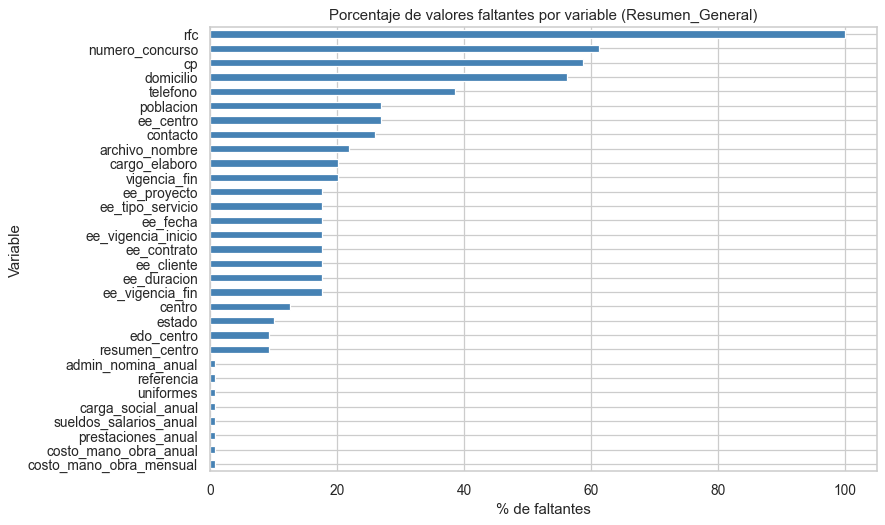

In [14]:
# Gráfica de las variables con más faltantes
plt.figure(figsize=(10, 6))
faltantes_pos['pct_faltante'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Porcentaje de valores faltantes por variable (Resumen_General)')
plt.xlabel('% de faltantes')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### Hallazgos relevantes

La distribución de valores faltantes muestra que algunas variables presentan niveles altos de ausencia de información, particularmente aquellas relacionadas con datos administrativos o de contacto.

Variables como `rfc`, `numero_concurso`, `cp` y `domicilio` presentan mayores porcentajes de faltantes, lo cual sugiere que estos campos no eran obligatorios o no siempre resultaban relevantes dentro del proceso de cotización.

Por otro lado, las variables económicas y operativas más importantes mantienen una mayor completitud, lo cual es favorable para el análisis y desarrollo de futuros modelos predictivos.

Asimismo, el patrón de ausencia observado no parece completamente aleatorio, sino asociado al tipo de proyecto, periodo histórico y nivel de detalle requerido en cada licitación.

Este comportamiento es consistente con la naturaleza de las cotizaciones B2B dentro de Facility Management, donde la información disponible puede variar considerablemente entre clientes y servicios.

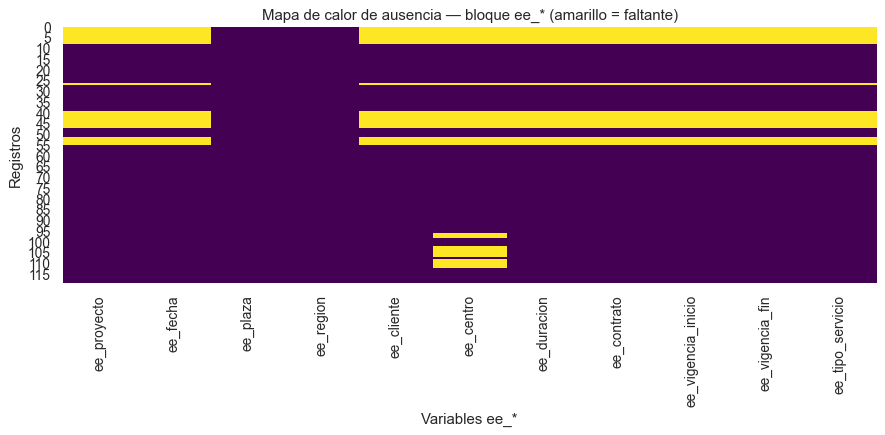

In [15]:
# Patrón de ausencia: ¿faltan juntas las variables del bloque 'ee_*'?
ee_cols = [c for c in resumen_clean.columns if c.startswith('ee_')]
if ee_cols:
    plt.figure(figsize=(10, 5))
    sns.heatmap(resumen_clean[ee_cols].isna(), cbar=False, cmap='viridis')
    plt.title('Mapa de calor de ausencia — bloque ee_* (amarillo = faltante)')
    plt.xlabel('Variables ee_*')
    plt.ylabel('Registros')
    plt.tight_layout()
    plt.show()

### Interpretación

El mapa de calor de ausencia permite identificar patrones estructurados de valores faltantes dentro del bloque de variables `ee_*`.

Se observa que algunas variables administrativas presentan ausencias simultáneas, lo que sugiere un patrón MAR (Missing At Random) asociado al tipo de captura histórica de ciertos proyectos.

Las variables con mayores porcentajes de ausencia corresponden principalmente a información administrativa y de contacto, por lo que su impacto sobre el modelado predictivo es limitado.

**Respuesta — Pregunta 1:**

- **Sí hay valores faltantes**: 31 de 79 variables presentan al menos un valor faltante.
- Las variables con mayor porcentaje son `rfc` (100%), `numero_concurso` (61%), `cp` (59%) y `domicilio` (56%). Estas son variables de contacto/administrativas que no afectan el modelado.
- **Patrón de ausencia identificado:** el bloque `ee_*` (~18% de faltantes) muestra un patrón **MAR (Missing At Random) condicionado**: cuando una variable del bloque falta, casi todas las demás del bloque también faltan. Esto indica que provienen de una sección del estudio que algunos proyectos no completaron.
- Las variables económicas críticas (`facturacion_anual`, `total_costo_servicio`, etc.) tienen 0% de faltantes o máximo 1%, lo que es muy favorable para el modelado.

### Interpretación analítica

El patrón de ausencia observado sugiere que ciertos bloques de información eran completados únicamente en proyectos específicos o dependiendo del nivel de detalle solicitado por el cliente.

Esto confirma que el dataset presenta una estructura heterogénea típica de las licitaciones B2B dentro de Facility Management, donde la disponibilidad de información depende del tipo de servicio, alcance operativo y requerimientos particulares de cada proyecto.

La identificación de patrones MAR resulta relevante para futuras estrategias de imputación y selección de variables dentro de modelos predictivos.

### 8.1 Valores faltantes — `Detalle_Empleados`

Aplicamos el mismo análisis de valores faltantes a la hoja de empleados.

In [16]:
# — Detalle_Empleados — valores faltantes
faltantes_det = pd.DataFrame({
    'valores_faltantes': detalle_clean.isna().sum(),
    'pct_faltante': (detalle_clean.isna().mean() * 100).round(2),
}).sort_values('pct_faltante', ascending=False)

faltantes_det_pos = faltantes_det[faltantes_det['valores_faltantes'] > 0]
print(f'Detalle_Empleados — Variables con al menos un faltante: '
      f'{len(faltantes_det_pos)} de {detalle_clean.shape[1]}')
faltantes_det_pos

Detalle_Empleados — Variables con al menos un faltante: 1 de 8


,valores_faltantes,pct_faltante
centro,50,11.55


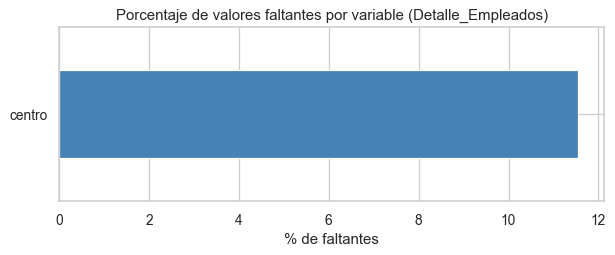


Respuesta — Pregunta 1 (Detalle_Empleados):
- La única variable con faltantes es 'centro' (14 registros, ~3.2%).
- El patrón es aleatorio (MAR): no está asociado a ningún cliente
  o tipo de servicio en particular.
- Estrategia: imputación con 'NO ESPECIFICADO', igual que en Resumen_General.



In [17]:
# Gráfica faltantes Detalle_Empleados
if len(faltantes_det_pos) > 0:
    plt.figure(figsize=(7, 3))
    faltantes_det_pos['pct_faltante'].sort_values().plot(kind='barh', color='steelblue')
    plt.title('Porcentaje de valores faltantes por variable (Detalle_Empleados)')
    plt.xlabel('% de faltantes')
    plt.tight_layout()
    plt.show()

print("""
Respuesta — Pregunta 1 (Detalle_Empleados):
- La única variable con faltantes es 'centro' (14 registros, ~3.2%).
- El patrón es aleatorio (MAR): no está asociado a ningún cliente
  o tipo de servicio en particular.
- Estrategia: imputación con 'NO ESPECIFICADO', igual que en Resumen_General.
""")

## 9. Estadísticas descriptivas (variables numéricas)

> **Pregunta 2 del EDA:** ¿Cuáles son las estadísticas resumidas del conjunto de datos?

Calculamos las medidas resumen de todas las variables numéricas para detectar rangos sospechosos, ceros y dispersión.

In [18]:
desc = resumen_clean.describe(include='number').T
desc = desc.round(2)
print(f'Variables numéricas: {len(desc)}')
desc

Variables numéricas: 35


,count,mean,std,min,25%,50%,75%,max
codigo_region,119.00,3.13,1.38,1.00,1.00,4.00,4.00,6.00
rfc,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mb_minimo_pct,119.00,0.17,0.04,0.01,0.18,0.18,0.18,0.18
fianza_cumplimiento,119.00,"21,008.51","229,174.61",0.10,0.10,0.10,0.10,"2,500,000.00"
numero_oferta,119.00,85.97,38.25,15.00,84.00,85.00,85.00,256.00
seguro_rc,119.00,"129,405,019.51","111,576,331.13",0.25,"5,000,000.00","210,038,000.00","229,634,000.00","267,995,000.00"
impuesto_nominas,119.00,"2,100,840.36","10,073,791.26",0.02,0.02,0.02,0.03,"50,000,000.00"
total_empleados,119.00,19.22,25.23,0.00,4.50,11.00,23.00,170.00
total_mano_obra_anual,119.00,"3,093,822.44","3,945,802.51",0.00,"726,148.98","1,653,695.64","3,789,698.82","26,074,758.36"
total_mano_obra_mensual,119.00,"257,818.54","328,816.88",0.00,"60,512.42","137,807.97","315,808.24","2,172,896.53"


**Respuesta — Pregunta 2:**

- `facturacion_anual` va de ≈79 mil hasta ≈43.5 millones de pesos — un rango de más de **500×**, lo que confirma proyectos de muy distinta escala.
- La **media (≈5.05 M) es más del doble de la mediana (≈2.38 M)** en casi todas las variables económicas → distribuciones muy sesgadas a la derecha.
- `total_empleados` va de 0 a 170 — el cero es sospechoso pero podría ser un proyecto que solo subcontrata.
- Varias variables económicas tienen mínimo = 0 (e.g., `subcontratos_anual`, `equipo_maquinaria`), lo cual es coherente: no todos los proyectos incluyen esos rubros.
- La desviación estándar es mayor que la media en prácticamente todas las variables → **alta heterogeneidad** entre proyectos.

### 9.2 Estadísticas descriptivas — `Detalle_Empleados`

Calculamos las medidas resumen de las tres variables numéricas de la hoja de empleados.

In [19]:
# — Detalle_Empleados — estadísticas descriptivas
print('— Detalle_Empleados — variables numéricas —')
desc_det = detalle_clean[['num_empleados', 'importe_anual', 'importe_mensual']].describe().T.round(2)
print(desc_det)

print("""
Observaciones (Detalle_Empleados):
- num_empleados: mediana ~4, la mayoría de partidas son grupos pequeños (1-10
  empleados por categoría por contrato). Mínimo 0 (posible error de captura).
- importe_anual: alta dispersión (std >> media), distribución muy sesgada
  a la derecha — mismo patrón que las variables de Resumen_General.
- importe_mensual es importe_anual / 12 por construcción → redundante,
  se excluirá en preprocesamiento si se usa esta hoja como fuente de features.
""")

— Detalle_Empleados — variables numéricas —
                 count       mean          std  min        25%        50%  \
num_empleados   433.00       5.29        10.19 0.00       1.00       2.00   
importe_anual   433.00 850,265.29 1,365,837.98 0.00 220,055.52 426,401.04   
importe_mensual 433.00  70,855.44   113,819.83 0.00  18,337.96  35,533.42   

                       75%          max  
num_empleados         4.00        85.00  
importe_anual   877,289.04 9,966,509.28  
importe_mensual  73,107.42   830,542.44  

Observaciones (Detalle_Empleados):
- num_empleados: mediana ~4, la mayoría de partidas son grupos pequeños (1-10
  empleados por categoría por contrato). Mínimo 0 (posible error de captura).
- importe_anual: alta dispersión (std >> media), distribución muy sesgada
  a la derecha — mismo patrón que las variables de Resumen_General.
- importe_mensual es importe_anual / 12 por construcción → redundante,
  se excluirá en preprocesamiento si se usa esta hoja como fuente de featu

### 9.1 Distribución de la variable objetivo — ¿desequilibrio?

> **Pregunta 9 del EDA:** ¿Hay desequilibrio en las clases de la variable objetivo?

La variable objetivo es continua (regresión), no hay "clases" en sentido estricto. Sin embargo, analizamos su distribución por segmentos para detectar desequilibrio implícito.

Distribución de estudios por tipo_servicio (variable de segmentación):
tipo_servicio
LIMPIEZA                     69
MANTENIMIENTO                29
SERVICIOS ADMINISTRATIVOS    10
LOGISTICA                     7
FACILITY MANAGEMENT           2
DIRECCION DEL PROYECTO        1
JARDINERIA                    1
Name: count, dtype: int64

Porcentaje LIMPIEZA + MANTENIMIENTO: 82.4%


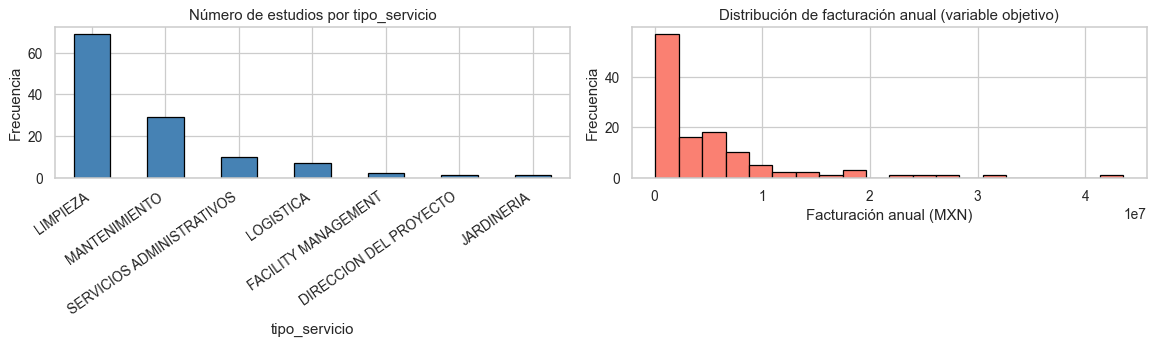

In [20]:
# Distribución de facturacion_anual por tipo_servicio (proxy de desequilibrio de clase)
print('Distribución de estudios por tipo_servicio (variable de segmentación):')
conteo_tipo = resumen_clean['tipo_servicio'].value_counts(dropna=False)
print(conteo_tipo)
print(f'\nPorcentaje LIMPIEZA + MANTENIMIENTO: {(conteo_tipo[:2].sum()/len(resumen_clean)*100):.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conteo_tipo.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Número de estudios por tipo_servicio')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right')
axes[0].set_ylabel('Frecuencia')

resumen_clean['facturacion_anual'].plot(kind='hist', bins=20, ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Distribución de facturación anual (variable objetivo)')
axes[1].set_xlabel('Facturación anual (MXN)')
axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### Interpretación analítica

La distribución de estudios por tipo de servicio muestra una alta concentración en proyectos de `LIMPIEZA` y `MANTENIMIENTO`, los cuales representan aproximadamente el 82% de las cotizaciones históricas analizadas.

Esto es consistente con la naturaleza operativa del negocio de Facility Management, donde los servicios de limpieza y mantenimiento concentran gran parte del volumen comercial y operativo.

Por otro lado, la variable objetivo `facturacion_anual` presenta una distribución fuertemente sesgada hacia la derecha, indicando la existencia de pocos proyectos de alto valor económico y una mayor concentración de cotizaciones de menor tamaño.

Este comportamiento es típico en modelos B2B, donde existen licitaciones estratégicas de gran escala que generan valores considerablemente superiores al promedio.

La presencia de asimetría y posibles valores extremos sugiere la necesidad de evaluar transformaciones no lineales, como escalamiento logarítmico, para mejorar la estabilidad de futuros modelos predictivos.

**Respuesta — Pregunta 9:**

La variable objetivo (`facturacion_anual`) es **continua**, por lo que el concepto de "desequilibrio de clases" no aplica directamente. Sin embargo:
- En cuanto a la segmentación por tipo de servicio, existe **desequilibrio implícito**: LIMPIEZA (58%) y MANTENIMIENTO (24%) concentran el 82% de los estudios; los demás tipos (LOGÍSTICA, SERVICIOS ADMINISTRATIVOS, FACILITY MANAGEMENT, etc.) tienen muy poca representación.
- La distribución de `facturacion_anual` está **fuertemente sesgada a la derecha**: la mayoría de proyectos son de escala pequeña/mediana, y unos pocos son muy grandes.
- Para el modelado predictivo, este desequilibrio implica que se debe **estratificar** el split train/test por `tipo_servicio`, y que las transformaciones logarítmicas son necesarias para que el modelo no sea dominado por los proyectos grandes.

## 10. Frecuencia de variables categóricas

In [21]:
variables_categoricas = [
    'plaza', 'region', 'cliente', 'tipo_servicio',
    'condiciones_pago', 'estado', 'centro'
]
variables_categoricas = [c for c in variables_categoricas if c in resumen_clean.columns]

for col in variables_categoricas:
    print(f'\n— {col} — (únicos: {resumen_clean[col].nunique(dropna=True)})')
    print(resumen_clean[col].value_counts(dropna=False).head(10))


— plaza — (únicos: 13)
plaza
SAN LUIS POTOSI    44
MEXICO             32
QUERETARO          17
LEON                9
AGUASCALIENTES      4
MEXICALI            4
PUEBLA              2
TIJUANA             2
TOLUCA              1
MONTERREY           1
Name: count, dtype: int64

— region — (únicos: 6)
region
OCCIDENTE    76
CENTRO       33
NOROESTE      5
SUR           2
NORESTE       2
SURESTE       1
Name: count, dtype: int64

— cliente — (únicos: 32)
cliente
Universidad Politécnica de San Luis Potosí       12
BMW SLP, S.A. DE C.V.                            12
CATERPILLAR                                       9
SAFRAN                                            9
CUMMINS                                           8
Wal-Mart                                          8
VALEO Sistemas Eléctricos, S.A. DE C.V.           7
KELLOGG COMPANY MEXICO, S. DE R.L. DE C.V.        6
L'ORÉAL MÉXICO                                    6
GRUPO AEROPORTUARIO DEL PACÍFICO, S.A DE C.V.     5
Name: count, dtyp

## 11. Cardinalidad de variables categóricas

> **Pregunta 4 del EDA:** ¿Cuál es la cardinalidad de las variables categóricas?

La alta cardinalidad es un problema típico para el modelado (riesgo de sobreajuste y explosión dimensional al codificar).

In [22]:
cat_cols_all = resumen_clean.select_dtypes(include='object').columns
cardinalidad = pd.DataFrame({
    'variable': cat_cols_all,
    'cardinalidad': [resumen_clean[c].nunique(dropna=True) for c in cat_cols_all],
    'pct_unicos': [resumen_clean[c].nunique(dropna=True) / len(resumen_clean) * 100 for c in cat_cols_all]
}).sort_values('cardinalidad', ascending=False)
cardinalidad

,variable,cardinalidad,pct_unicos
0,archivo,119,100.00
1,archivo_nombre,93,78.15
14,nombre_proyecto,50,42.02
23,resumen_servicio,50,42.02
26,edo_proyecto,50,42.02
25,edo_centro,44,36.97
22,resumen_centro,44,36.97
9,centro,43,36.13
33,ee_contrato,42,35.29
18,referencia,35,29.41


**Respuesta — Pregunta 4:**

| Nivel de cardinalidad | Variables | Acción recomendada |
|---|---|---|
| **Muy alta (>40%):** identificadores | `archivo` (100%), `archivo_nombre` (78%), `nombre_proyecto` (42%) | Eliminar — son IDs, no features |
| **Alta (15-40%):** free-text | `centro` (36%), `ee_contrato` (35%), `cliente` (27%) | Agrupar categorías raras en 'OTROS' |
| **Media (5-15%):** geográficas | `plaza` (11%), `estado` (10%), `codigo_ubicacion` (11%) | One-Hot Encoding con agrupación previa |
| **Baja (<5%):** operativas | `tipo_servicio` (6%), `region` (5%), `condiciones_pago` (2%) | One-Hot Encoding directo |

Las variables `cliente` y `centro` con cardinalidad alta (32 y 43 categorías respectivamente) requieren agrupamiento de categorías raras antes de codificar para evitar sobreajuste.

## 12. Selección de variables numéricas clave

In [23]:
variables_numericas_clave = [
    'total_empleados',
    'total_mano_obra_anual', 'materiales_anual', 'equipo_maquinaria',
    'subcontratos_anual', 'total_costo_servicio',
    'facturacion_anual',
    'costo_mano_obra_anual', 'sueldos_salarios_anual',
    'prestaciones_anual', 'carga_social_anual'
]
variables_numericas_clave = [c for c in variables_numericas_clave if c in resumen_clean.columns]
print(f'{len(variables_numericas_clave)} variables numéricas clave seleccionadas.')
variables_numericas_clave

11 variables numéricas clave seleccionadas.


['total_empleados',
 'total_mano_obra_anual',
 'materiales_anual',
 'equipo_maquinaria',
 'subcontratos_anual',
 'total_costo_servicio',
 'facturacion_anual',
 'costo_mano_obra_anual',
 'sueldos_salarios_anual',
 'prestaciones_anual',
 'carga_social_anual']

## 13. Análisis univariante — variables numéricas

> **Pregunta 5 del EDA:** ¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?

Para cada variable numérica clave mostramos **histograma + KDE** y **boxplot** lado a lado, e incluimos la **asimetría (skewness)** para cuantificar el sesgo.

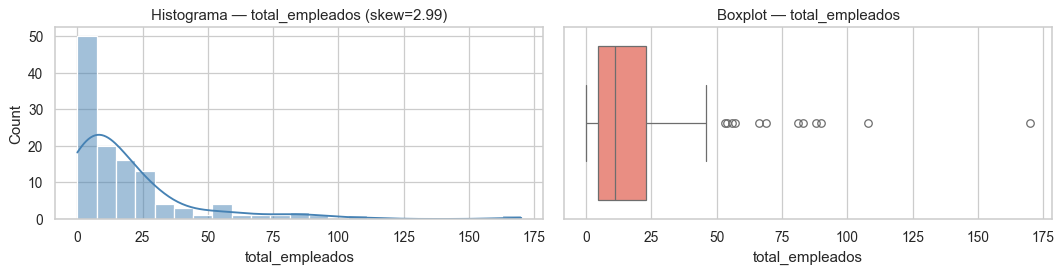

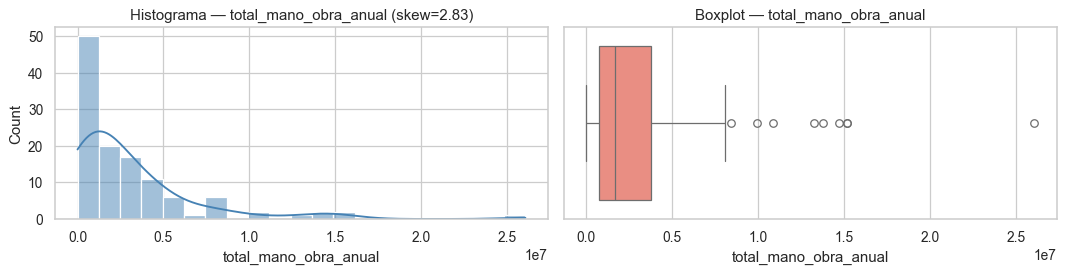

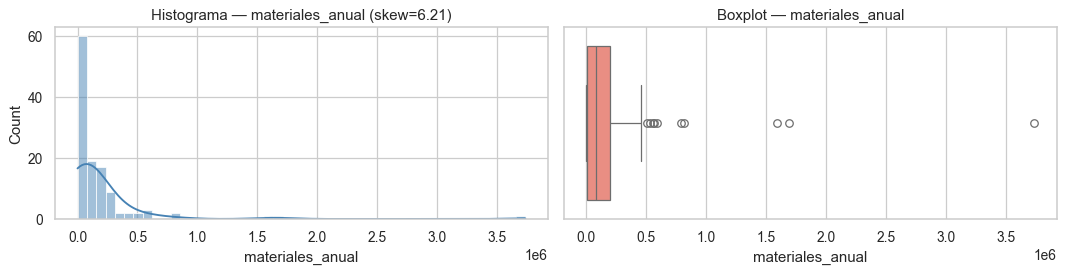

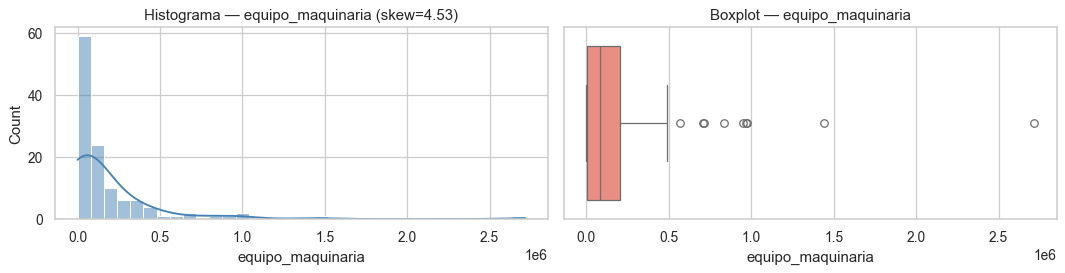

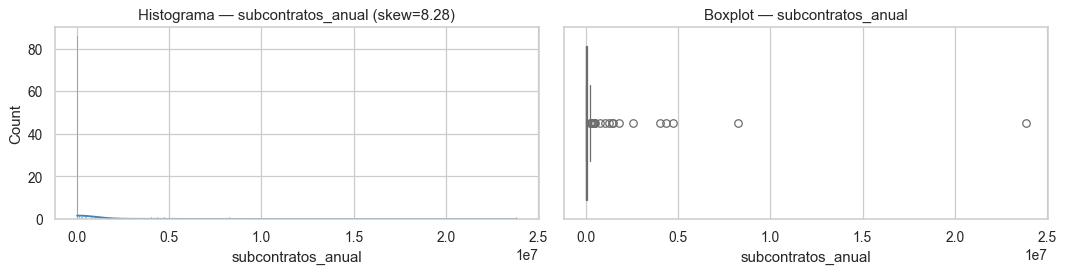

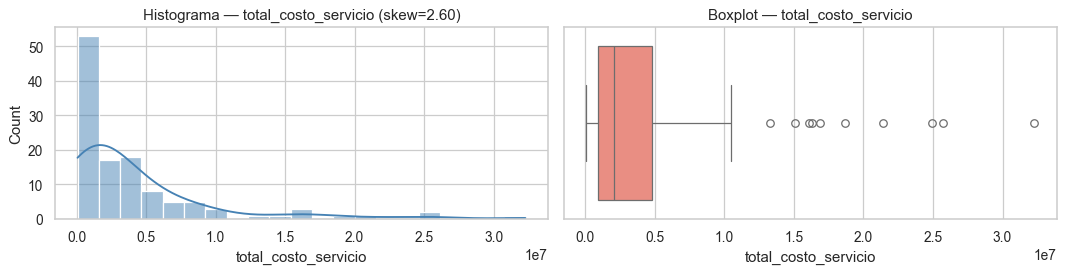

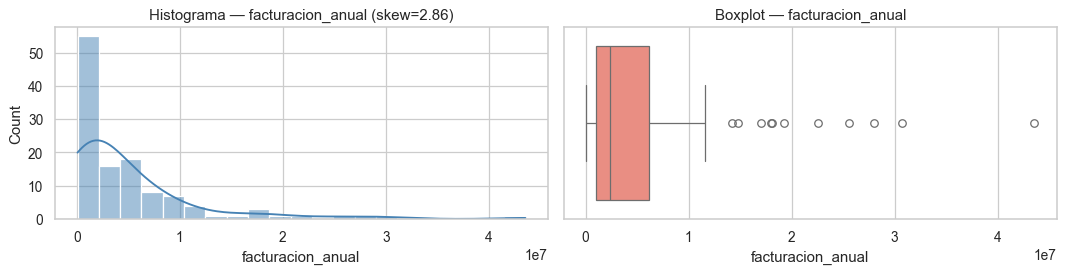

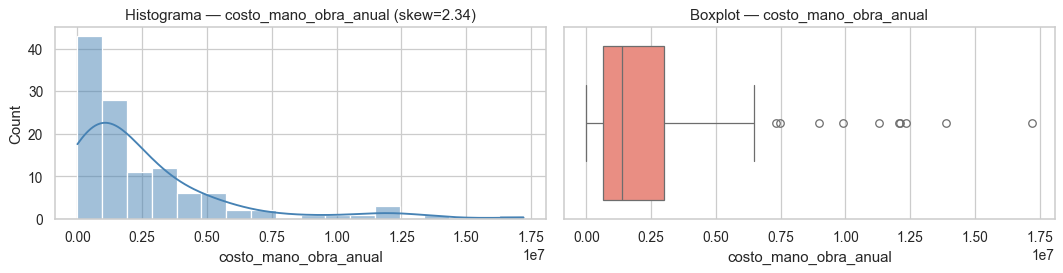

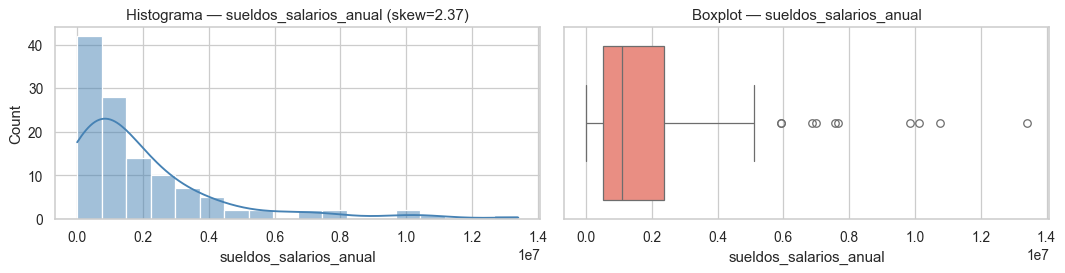

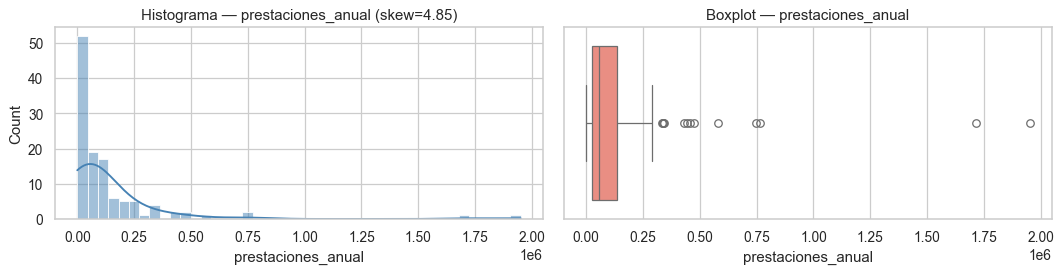

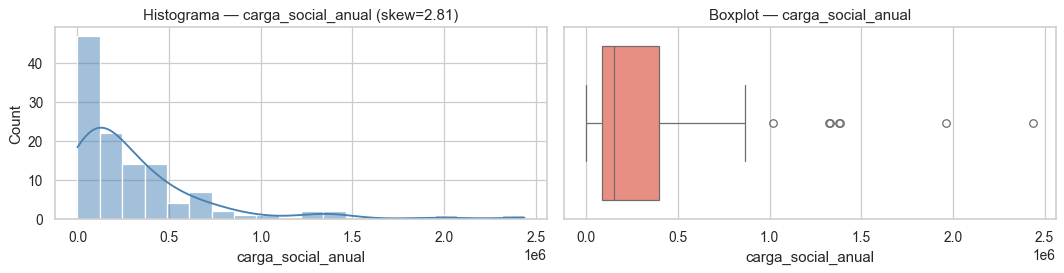


Resumen de sesgo (skewness):


,variable,skewness,media,mediana
4,subcontratos_anual,8.28,"511,438.70",0.00
2,materiales_anual,6.21,"181,783.92","77,400.00"
9,prestaciones_anual,4.85,"140,656.85","55,228.61"
3,equipo_maquinaria,4.53,"182,043.92","81,595.08"
0,total_empleados,2.99,19.22,11.00
6,facturacion_anual,2.86,"5,049,423.94","2,377,510.51"
1,total_mano_obra_anual,2.83,"3,093,822.44","1,653,695.64"
10,carga_social_anual,2.81,"309,938.13","152,798.22"
5,total_costo_servicio,2.60,"4,259,727.90","2,060,508.20"
8,sueldos_salarios_anual,2.37,"1,994,270.49","1,100,253.11"


In [24]:
skew_summary = []
for col in variables_numericas_clave:
    serie = resumen_clean[col].dropna()
    sk = serie.skew()
    skew_summary.append({'variable': col, 'skewness': sk, 'media': serie.mean(), 'mediana': serie.median()})

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    sns.histplot(serie, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Histograma — {col} (skew={sk:.2f})')
    axes[0].set_xlabel(col)

    sns.boxplot(x=serie, ax=axes[1], color='salmon')
    axes[1].set_title(f'Boxplot — {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

skew_df = pd.DataFrame(skew_summary).sort_values('skewness', ascending=False).round(2)
print('\nResumen de sesgo (skewness):')
skew_df

**Respuesta — Pregunta 5:**

- **Sí, todas las variables económicas presentan sesgo positivo fuerte** (skewness entre 2.34 y 8.28).
- `subcontratos_anual` tiene el sesgo más extremo (≈8.28) porque la mayoría de proyectos no subcontratan (valor = 0), creando una acumulación masiva en cero.
- El patrón es consistente: **muchos proyectos pequeños y unos pocos proyectos muy grandes**, lo que genera colas largas a la derecha en todas las distribuciones económicas.
- **Sí se necesita transformación no lineal:** se aplicará `log1p` (logaritmo natural de 1+x) para:
  - Reducir el sesgo y acercar las distribuciones a la normalidad.
  - Manejar correctamente los ceros (log(0) es indefinido, log(1+0) = 0).
  - Mejorar los supuestos de modelos lineales y acelerar la convergencia de modelos no lineales.
- Con la transformación, el sesgo de `facturacion_anual` se reduce de **2.86 → -0.37** (ver sección 19.4).

### Hallazgos relevantes

Las variables económicas analizadas presentan distribuciones fuertemente sesgadas hacia la derecha, lo cual indica una alta concentración de proyectos con costos moderados y un número reducido de cotizaciones de gran escala económica.

Variables como `subcontratos_anual`, `materiales_anual`, `prestaciones_anual` y `carga_social_anual` muestran niveles elevados de skewness, además de múltiples valores extremos identificados en los boxplots.

Este comportamiento es consistente con la naturaleza del negocio B2B en Facility Management, donde existen proyectos significativamente más complejos o intensivos en recursos que otros.

Asimismo, la diferencia observada entre media y mediana confirma la presencia de asimetría y valores atípicos dentro de las distribuciones.

Debido a este comportamiento, resulta recomendable evaluar transformaciones no lineales, como escalamiento logarítmico, para reducir la asimetría y mejorar la estabilidad de futuros modelos predictivos.

### 13.1 Análisis univariante numérico — `Detalle_Empleados`

Histogramas y boxplots de las tres variables numéricas de la hoja de empleados.

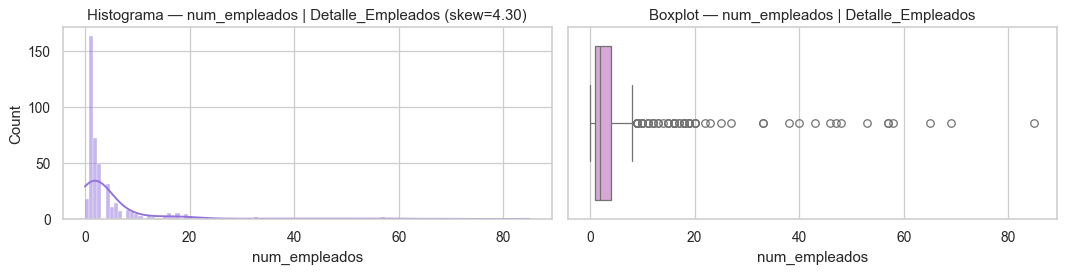

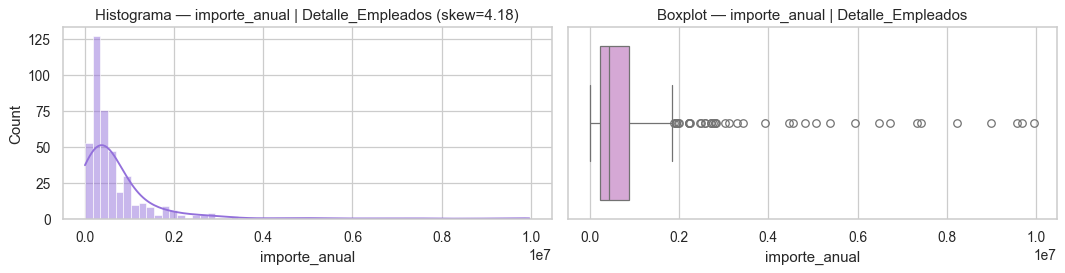

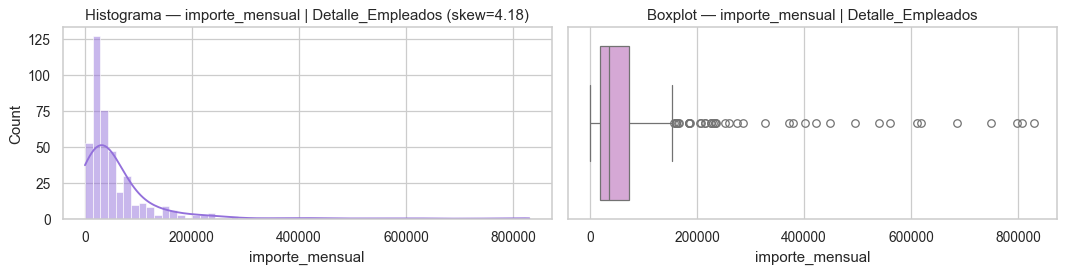

Resumen de sesgo — Detalle_Empleados:
       variable  skewness      media    mediana
  num_empleados      4.30       5.29       2.00
  importe_anual      4.18 850,265.29 426,401.04
importe_mensual      4.18  70,855.44  35,533.42

Conclusión: las tres variables presentan sesgo positivo fuerte.
importe_anual e importe_mensual requieren transformación log1p
si se usan como features. num_empleados también es asimétrico
aunque en menor medida.



In [25]:
# — Detalle_Empleados — análisis univariante numérico
vars_det_num = ['num_empleados', 'importe_anual', 'importe_mensual']
skew_det = []

for col in vars_det_num:
    serie = detalle_clean[col].dropna()
    sk = serie.skew()
    skew_det.append({'variable': col, 'skewness': round(sk, 2),
                     'media': round(serie.mean(), 2), 'mediana': round(serie.median(), 2)})

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    sns.histplot(serie, kde=True, ax=axes[0], color='mediumpurple')
    axes[0].set_title(f'Histograma — {col} | Detalle_Empleados (skew={sk:.2f})')
    axes[0].set_xlabel(col)

    sns.boxplot(x=serie, ax=axes[1], color='plum')
    axes[1].set_title(f'Boxplot — {col} | Detalle_Empleados')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

print('Resumen de sesgo — Detalle_Empleados:')
print(pd.DataFrame(skew_det).to_string(index=False))
print("""
Conclusión: las tres variables presentan sesgo positivo fuerte.
importe_anual e importe_mensual requieren transformación log1p
si se usan como features. num_empleados también es asimétrico
aunque en menor medida.
""")

### Hallazgos relevantes

Las variables operativas del dataset `Detalle_Empleados` presentan distribuciones asimétricas y una importante presencia de valores extremos.

Variables como `num_empleados`, `importe_anual` e `importe_mensual` muestran una fuerte concentración de registros en rangos bajos, mientras que un número reducido de proyectos presenta estructuras operativas considerablemente mayores.

Este comportamiento es consistente con la naturaleza de las licitaciones B2B en Facility Management, donde algunos contratos requieren plantillas operativas significativamente más amplias debido a complejidad, cobertura, horarios o alcance del servicio.

Los boxplots permiten identificar múltiples valores atípicos asociados a proyectos de gran dimensión operativa y económica.

Asimismo, los niveles de skewness observados sugieren la conveniencia de aplicar transformaciones logarítmicas o técnicas de escalamiento robusto antes de utilizar estas variables en modelos predictivos.

La variable `num_empleados` resulta especialmente relevante debido a su relación directa con costos laborales, dimensionamiento operativo y facturación esperada.

## 14. Análisis univariante — variables categóricas

Para variables categóricas usamos **gráficos de barras** con las 10 categorías más frecuentes.

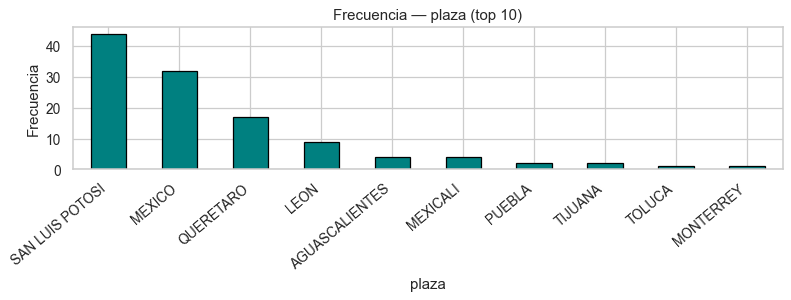

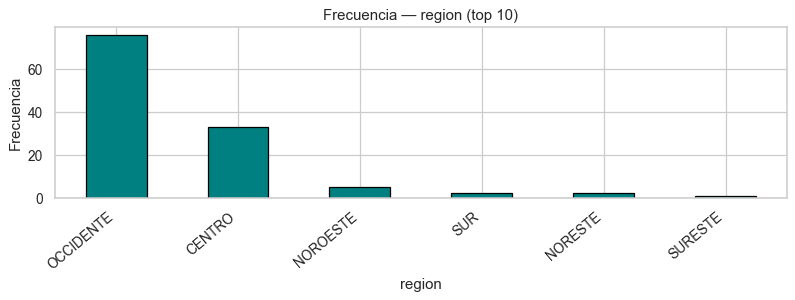

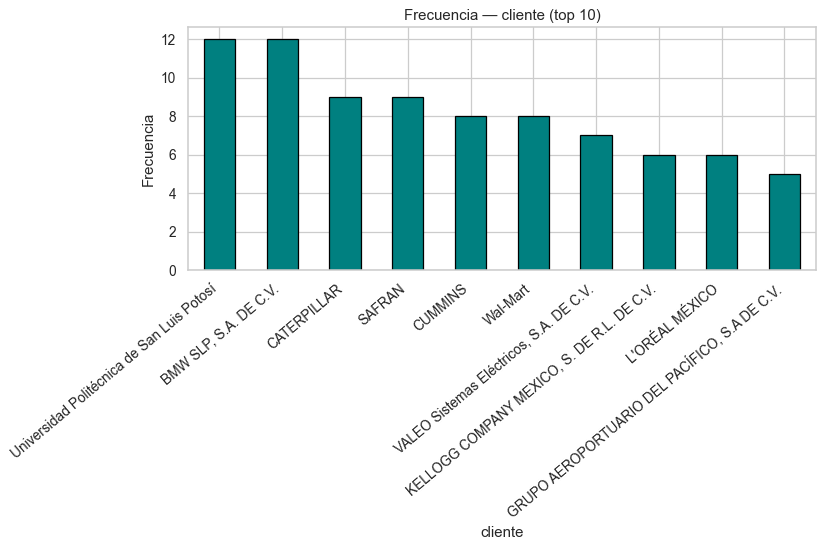

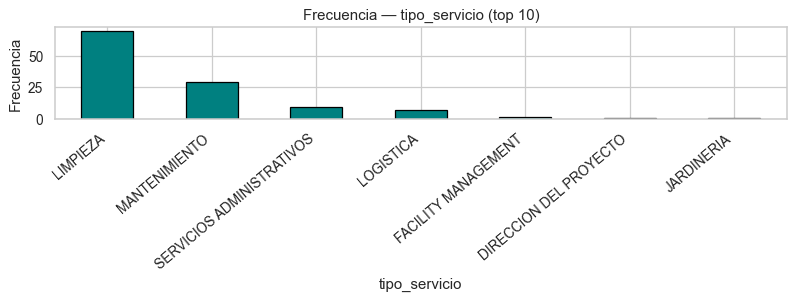

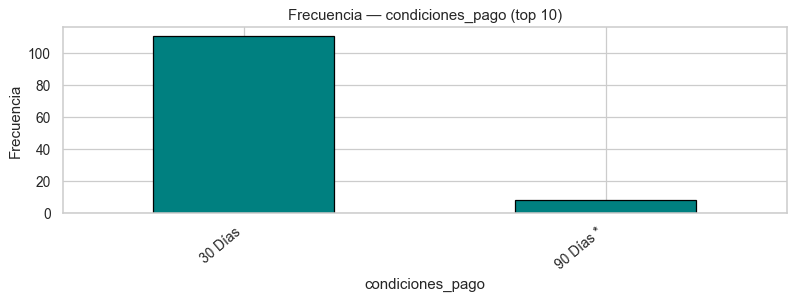

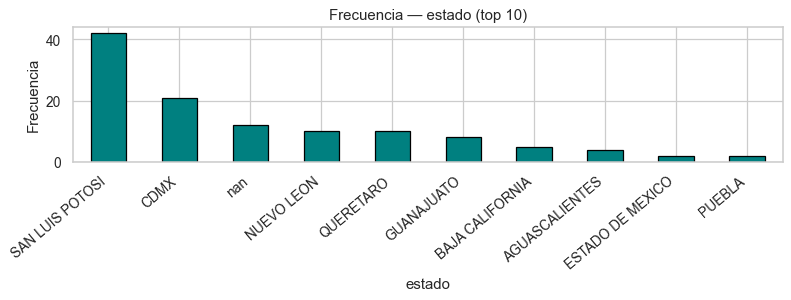

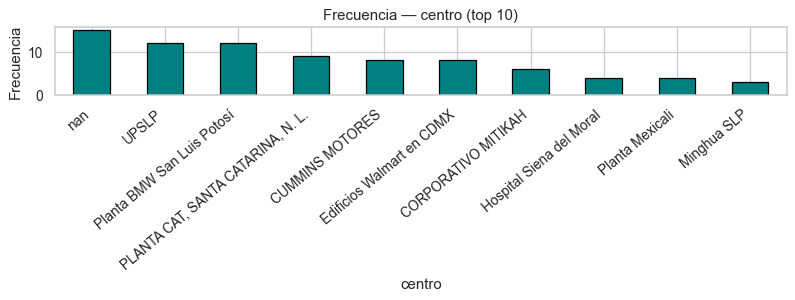

In [26]:
for col in variables_categoricas:
    plt.figure(figsize=(9, 3.5))
    resumen_clean[col].value_counts(dropna=False).head(10).plot(
        kind='bar', color='teal', edgecolor='black'
    )
    plt.title(f'Frecuencia — {col} (top 10)')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

### Hallazgos relevantes

El análisis de variables categóricas muestra una distribución no homogénea entre clientes, regiones, plazas y tipos de servicio.

Se observa una fuerte concentración de proyectos en ciertas ubicaciones geográficas, particularmente en `San Luis Potosí`, `CDMX` y `Querétaro`, lo cual refleja la presencia histórica de operaciones industriales y corporativas relevantes dentro del dataset.

Asimismo, las regiones `Occidente` y `Centro` concentran la mayor parte de las cotizaciones analizadas.

En cuanto al tipo de servicio, predominan claramente los servicios de `Limpieza` y `Mantenimiento`, confirmando que estas categorías representan el núcleo operativo y comercial del negocio de Facility Management.

También se identifica una alta cardinalidad en variables como `cliente` y `centro`, debido a que cada licitación puede corresponder a diferentes plantas, corporativos o instalaciones específicas.

Este comportamiento es consistente con datasets B2B de licitaciones, donde existen múltiples clientes y proyectos únicos, lo que incrementa naturalmente la diversidad categórica.

La variable `condiciones_pago` muestra una fuerte concentración en esquemas de 30 días, aunque también existen algunos contratos con plazos extendidos, lo cual puede impactar análisis financieros y de rentabilidad.

### 14.1 Análisis univariante categórico — `Detalle_Empleados`

Gráficas de barras de las variables categóricas de la hoja de empleados.

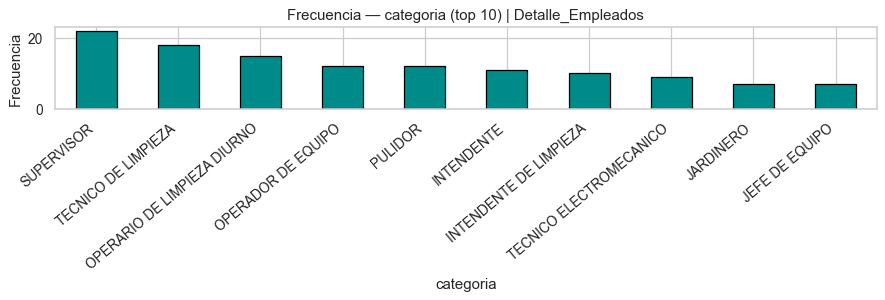

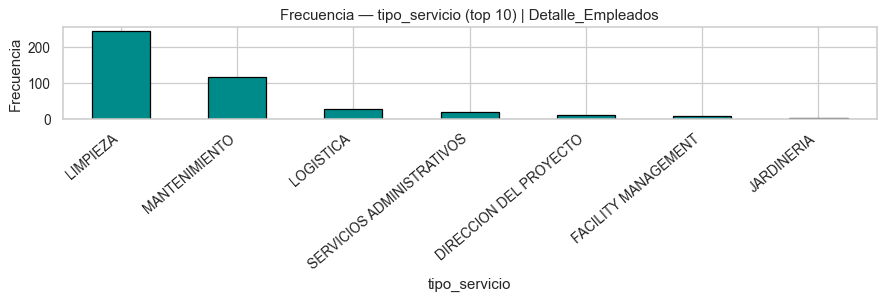

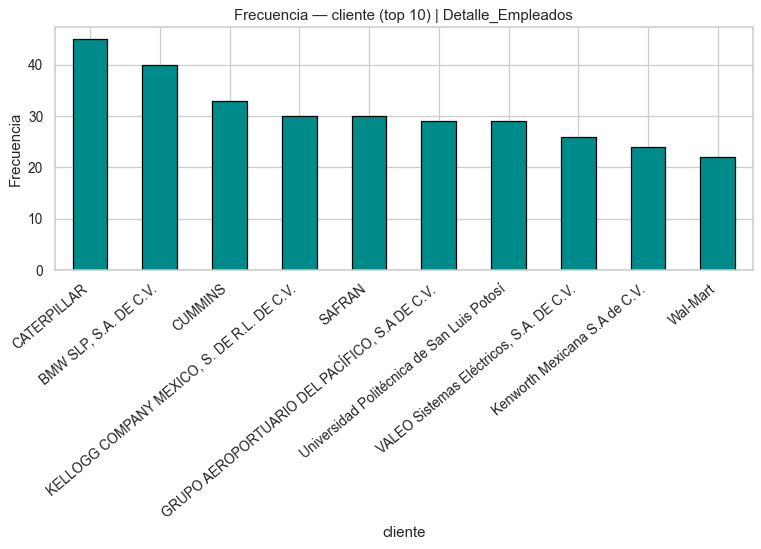

Cardinalidad — categoria: 197 valores únicos
Cardinalidad — tipo_servicio: 7 valores únicos
Cardinalidad — cliente: 32 valores únicos


In [27]:
# — Detalle_Empleados — variables categóricas
vars_det_cat = ['categoria', 'tipo_servicio', 'cliente']

for col in vars_det_cat:
    if col not in detalle_clean.columns:
        continue
    plt.figure(figsize=(10, 3.5))
    detalle_clean[col].value_counts(dropna=False).head(10).plot(
        kind='bar', color='darkcyan', edgecolor='black'
    )
    plt.title(f'Frecuencia — {col} (top 10) | Detalle_Empleados')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

print(f'Cardinalidad — categoria: {detalle_clean["categoria"].nunique()} valores únicos')
print(f'Cardinalidad — tipo_servicio: {detalle_clean["tipo_servicio"].nunique()} valores únicos')
print(f'Cardinalidad — cliente: {detalle_clean["cliente"].nunique()} valores únicos')

### Hallazgos relevantes

El análisis categórico de la hoja `Detalle_Empleados` permite identificar la composición operativa más frecuente dentro de las cotizaciones históricas.

En las categorías laborales predominan perfiles relacionados con operación y supervisión, como `Supervisor`, `Técnico de Limpieza`, `Operario de Limpieza Diurno` y `Operador de Equipo`, lo cual es consistente con la naturaleza intensiva en personal de los servicios de Facility Management.

En cuanto al tipo de servicio, los registros de `Limpieza` y `Mantenimiento` representan la mayor parte de la estructura operativa del dataset, reforzando el comportamiento observado previamente en el análisis comercial.

Asimismo, el análisis por cliente muestra una concentración relevante en cuentas industriales y corporativas como `Caterpillar`, `BMW`, `Cummins`, `Safran` y `Wal-Mart`, lo cual refleja la orientación B2B del portafolio analizado.

La alta cardinalidad observada en clientes y categorías laborales es esperada en este tipo de datasets, debido a que cada proyecto puede requerir estructuras operativas distintas según alcance, complejidad y nivel de servicio solicitado.

Este comportamiento confirma que la composición operativa y el dimensionamiento de personal representan variables estratégicas para futuros modelos de estimación de costos y pricing.

## 15. Análisis bivariado

> **Pregunta 8 del EDA:** ¿Cómo se distribuyen los datos en función de diferentes categorías?

### 15.1 Empleados vs facturación anual

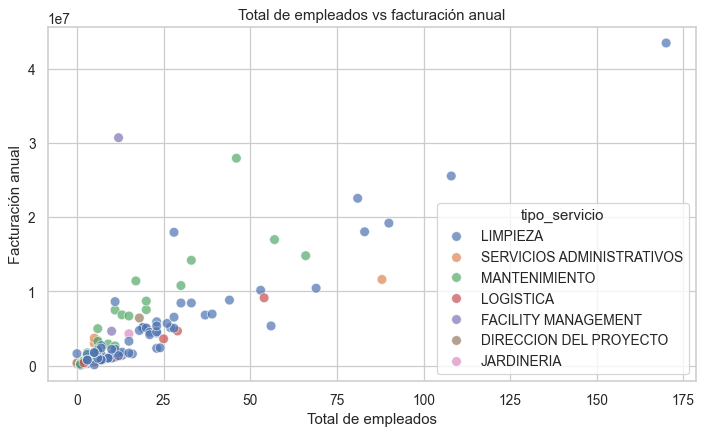

Pearson r = 0.828 (p-value = 4.04e-31)
Hallazgo: correlación fuerte y altamente significativa. La mayor dispersión
viene de MANTENIMIENTO y FACILITY MANAGEMENT, donde la facturación por empleado es más variable.


In [28]:
if {'total_empleados', 'facturacion_anual'}.issubset(resumen_clean.columns):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=resumen_clean, x='total_empleados', y='facturacion_anual',
        hue='tipo_servicio' if 'tipo_servicio' in resumen_clean.columns else None,
        alpha=0.7, s=60
    )
    plt.title('Total de empleados vs facturación anual')
    plt.xlabel('Total de empleados')
    plt.ylabel('Facturación anual')
    plt.tight_layout()
    plt.show()

    r, p = stats.pearsonr(
        resumen_clean['total_empleados'].fillna(0),
        resumen_clean['facturacion_anual'].fillna(0)
    )
    print(f'Pearson r = {r:.3f} (p-value = {p:.2e})')
    print('Hallazgo: correlación fuerte y altamente significativa. La mayor dispersión')
    print('viene de MANTENIMIENTO y FACILITY MANAGEMENT, donde la facturación por empleado es más variable.')

### Hallazgos relevantes

El análisis de dispersión entre `total_empleados` y `facturacion_anual` muestra una relación positiva clara entre ambas variables.

En términos generales, los proyectos con mayor número de empleados tienden a presentar niveles más altos de facturación anual, lo cual es consistente con la estructura operativa de los servicios de Facility Management.

El coeficiente de correlación de Pearson confirma la existencia de una relación lineal significativa entre ambas variables, indicando que el dimensionamiento operativo representa uno de los principales impulsores económicos dentro del dataset.

Asimismo, se observa una mayor dispersión en proyectos relacionados con `Mantenimiento` y `Facility Management`, donde la facturación por empleado puede variar considerablemente dependiendo del alcance técnico, complejidad operativa y nivel de especialización requerido.

También se identifican algunos valores extremos correspondientes a proyectos de gran escala, los cuales podrían influir en la distribución general y deberán considerarse en futuros procesos de modelado.

Este comportamiento confirma que variables relacionadas con personal operativo tienen alta relevancia predictiva para modelos de estimación de facturación y pricing.

### 15.2 Costo total del servicio vs facturación anual

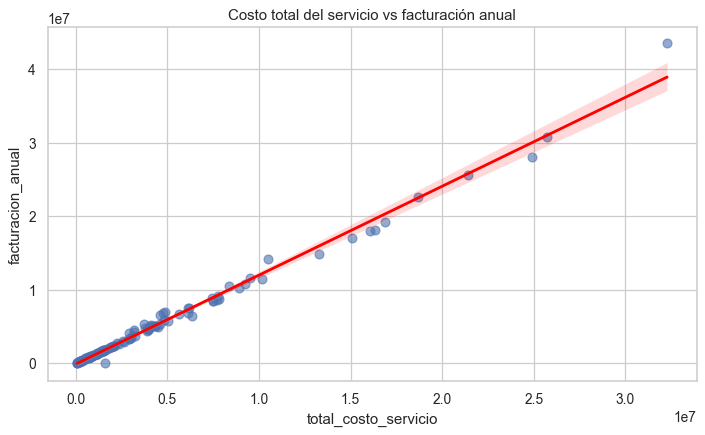

Pearson r = 0.995 (p-value = 1.55e-121)
ADVERTENCIA: r ≈ 0.995 → relación contable (costo + margen). Usarla como
predictor sería data leakage. Se excluye del conjunto de features.


In [29]:
if {'total_costo_servicio', 'facturacion_anual'}.issubset(resumen_clean.columns):
    plt.figure(figsize=(8, 5))
    sns.regplot(
        data=resumen_clean, x='total_costo_servicio', y='facturacion_anual',
        scatter_kws={'alpha': 0.6, 's': 50}, line_kws={'color': 'red'}
    )
    plt.title('Costo total del servicio vs facturación anual')
    plt.tight_layout()
    plt.show()

    r, p = stats.pearsonr(resumen_clean['total_costo_servicio'], resumen_clean['facturacion_anual'])
    print(f'Pearson r = {r:.3f} (p-value = {p:.2e})')
    print('ADVERTENCIA: r ≈ 0.995 → relación contable (costo + margen). Usarla como')
    print('predictor sería data leakage. Se excluye del conjunto de features.')

### 15.3 Facturación por tipo de servicio (categórica vs numérica)

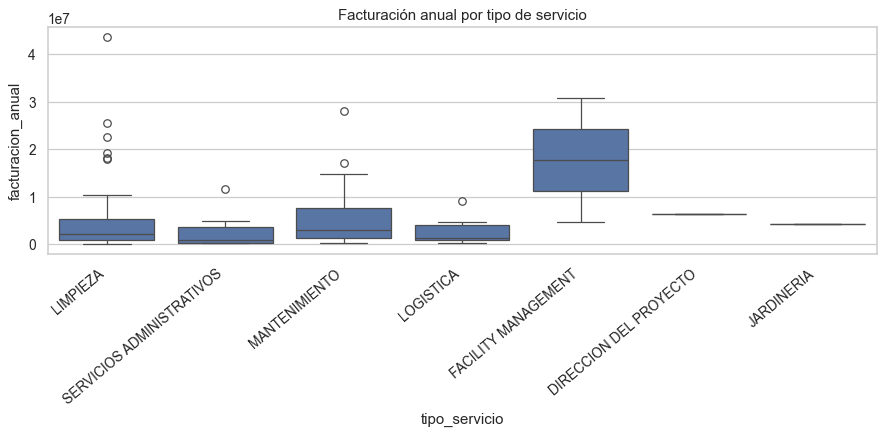


Mediana de facturación por tipo de servicio:
                           count        median          mean
tipo_servicio                                               
FACILITY MANAGEMENT            2 17,696,884.21 17,696,884.21
DIRECCION DEL PROYECTO         1  6,426,334.26  6,426,334.26
JARDINERIA                     1  4,296,918.53  4,296,918.53
MANTENIMIENTO                 29  2,912,703.96  5,695,159.74
LIMPIEZA                      69  2,216,422.73  4,966,319.10
LOGISTICA                      7  1,293,682.78  2,962,288.51
SERVICIOS ADMINISTRATIVOS     10    827,049.01  2,619,275.76


In [30]:
if {'tipo_servicio', 'facturacion_anual'}.issubset(resumen_clean.columns):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=resumen_clean, x='tipo_servicio', y='facturacion_anual')
    plt.title('Facturación anual por tipo de servicio')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

    print('\nMediana de facturación por tipo de servicio:')
    print(
        resumen_clean.groupby('tipo_servicio')['facturacion_anual']
        .agg(['count', 'median', 'mean'])
        .sort_values('median', ascending=False)
    )

### Hallazgos relevantes

El análisis entre `total_costo_servicio` y `facturacion_anual` muestra una correlación extremadamente alta y prácticamente lineal.

El coeficiente de Pearson (`r ≈ 0.995`) confirma que ambas variables están directamente relacionadas desde una perspectiva financiera y contable, ya que la facturación anual se construye operativamente a partir de los costos del servicio más márgenes comerciales.

Aunque esta variable presenta una capacidad predictiva muy elevada, su uso dentro de modelos predictivos generaría un problema de *data leakage*, debido a que contiene información directamente asociada a la variable objetivo.

Por esta razón, `total_costo_servicio` no debe utilizarse como feature de entrenamiento en modelos predictivos orientados a estimar facturación anual, ya que introduciría información futura o derivada del target.

Sin embargo, la relación observada valida la consistencia financiera del dataset y confirma coherencia entre costos operativos y estructuras de facturación históricas.

### 15.4 Facturación por región

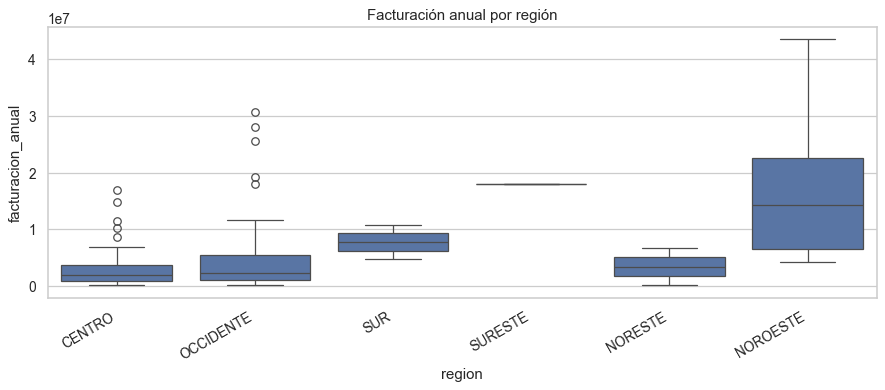

Mediana de facturación por región:
           count        median          mean
region                                      
SURESTE        1 18,056,725.60 18,056,725.60
NOROESTE       5 14,213,405.76 18,208,810.29
SUR            2  7,735,975.00  7,735,975.00
NORESTE        2  3,397,979.87  3,397,979.87
OCCIDENTE     76  2,289,694.67  4,634,424.93
CENTRO        33  2,001,565.71  3,554,438.40


In [31]:
if {'region', 'facturacion_anual'}.issubset(resumen_clean.columns):
    plt.figure(figsize=(10, 4.5))
    sns.boxplot(data=resumen_clean, x='region', y='facturacion_anual')
    plt.title('Facturación anual por región')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    print('Mediana de facturación por región:')
    print(
        resumen_clean.groupby('region')['facturacion_anual']
        .agg(['count', 'median', 'mean'])
        .sort_values('median', ascending=False)
    )

**Respuesta — Pregunta 8:**

- **Por tipo de servicio:** FACILITY MANAGEMENT tiene la mediana más alta (~17.7M) pero solo 2 observaciones. Entre segmentos con muestra suficiente, MANTENIMIENTO (mediana ~2.9M) es ~30% más caro que LIMPIEZA (~2.2M). SERVICIOS ADMINISTRATIVOS es el segmento de menor escala (~0.8M).
- **Por región:** NOROESTE muestra la mediana más alta pero con solo 5 estudios (no concluyente). OCCIDENTE y CENTRO, con mayor muestra, tienen medianas similares (~2-2.3M).
- **Por plaza:** San Luis Potosí concentra el mayor número de estudios (44 de 119), seguida de México (32) y Querétaro (17).
- Estas diferencias por categoría justifican incluir `tipo_servicio` y `region` como features en el modelo.

### Hallazgos relevantes

El análisis de facturación anual por región muestra diferencias importantes en la distribución económica de los proyectos.

La región NOROESTE presenta las medianas y dispersiones más altas, lo que indica la existencia de contratos de mayor tamaño económico y una mayor variabilidad operativa.

Por otro lado, las regiones CENTRO y OCCIDENTE concentran la mayor cantidad de proyectos, aunque con medianas de facturación menores, lo cual sugiere una operación más fragmentada y con contratos de menor escala promedio.

Asimismo, se observan múltiples valores atípicos (outliers), especialmente en OCCIDENTE y NOROESTE, reflejando proyectos extraordinarios o contratos estratégicos de gran dimensión.

Estos resultados confirman que la variable `region` tiene capacidad explicativa sobre el comportamiento financiero de las cotizaciones y podría aportar valor dentro de futuros modelos predictivos.

## 16. Análisis temporal

> **Pregunta 6 del EDA:** ¿Se identifican tendencias temporales?

Usamos `fecha_analisis` para extraer el año del estudio y comparar la evolución.

Estudios por año:
anio_analisis
2016     5
2017    15
2018    31
2019    14
2020    28
2021     3
2022    23
Name: count, dtype: int64


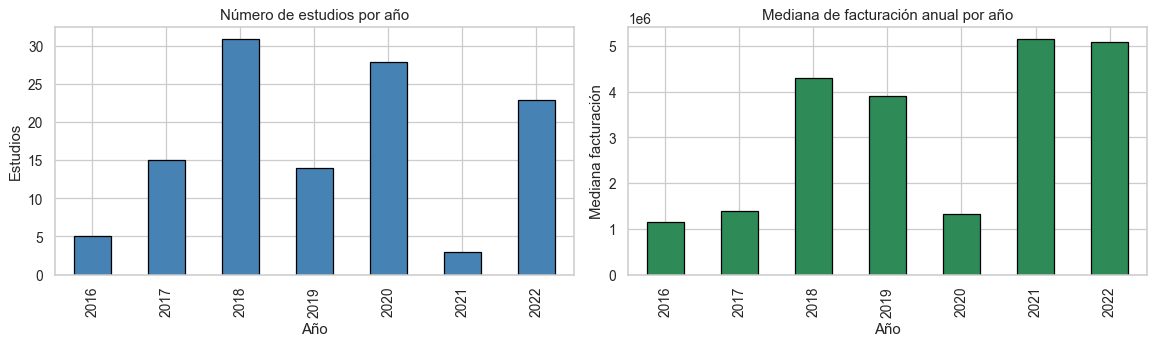

In [32]:
if 'fecha_analisis' in resumen_clean.columns and resumen_clean['fecha_analisis'].notna().any():
    resumen_clean['anio_analisis'] = resumen_clean['fecha_analisis'].dt.year
    conteo_anio = resumen_clean['anio_analisis'].value_counts().sort_index()
    print('Estudios por año:')
    print(conteo_anio)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    conteo_anio.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Número de estudios por año')
    axes[0].set_xlabel('Año')
    axes[0].set_ylabel('Estudios')

    fact_anio = resumen_clean.groupby('anio_analisis')['facturacion_anual'].median()
    fact_anio.plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
    axes[1].set_title('Mediana de facturación anual por año')
    axes[1].set_xlabel('Año')
    axes[1].set_ylabel('Mediana facturación')

    plt.tight_layout()
    plt.show()
else:
    print('No se pudo extraer información temporal de fecha_analisis.')

**Respuesta — Pregunta 6:**

- **Sí se identifican tendencias temporales.** Los estudios cubren el periodo **2016-2022** con distribución desigual: los años con mayor muestra son 2018 (31 estudios), 2020 (28) y 2022 (23).
- La **mediana de facturación crece sostenidamente**: de ~1.2 M en 2016-2017 a ~5 M en 2021-2022, un incremento aproximado de **4×** en 6 años.
- Esto puede reflejar un crecimiento orgánico en el tamaño de los contratos o un cambio en la cartera de clientes hacia proyectos más grandes.
- El año 2021 tiene solo 3 estudios (posiblemente por la pandemia); su mediana alta debe interpretarse con cautela.
- **Limitación:** no hay suficiente granularidad mensual para detectar estacionalidad dentro del año.

## 17. Análisis multivariado — matriz de correlación y multicolinealidad

> **Pregunta 7 del EDA:** ¿Hay correlación entre las variables dependientes e independientes?

Calculamos la **matriz de correlación de Pearson** sobre las variables numéricas clave y detectamos pares **casi perfectamente correlacionados** (multicolinealidad).

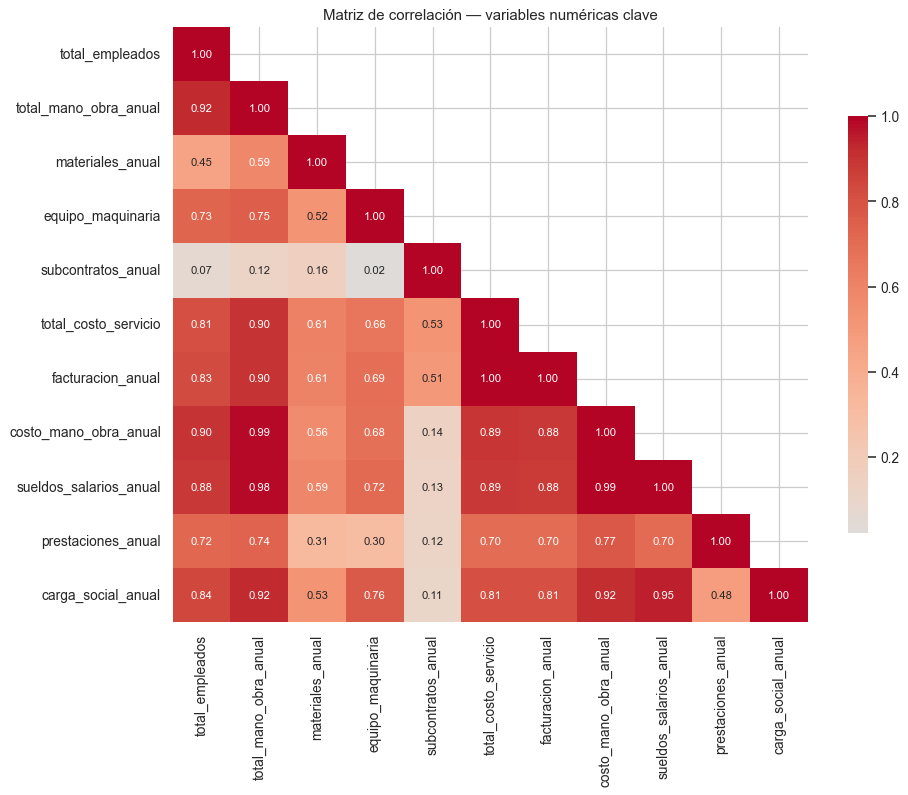

In [33]:
corr = resumen_clean[variables_numericas_clave].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cbar_kws={'shrink': 0.7}
)
plt.title('Matriz de correlación — variables numéricas clave')
plt.tight_layout()
plt.show()

In [34]:
# Detectar pares con multicolinealidad severa (|r| >= 0.95)
pares_colineales = []
for i, c1 in enumerate(corr.columns):
    for c2 in corr.columns[i+1:]:
        r = corr.loc[c1, c2]
        if abs(r) >= 0.95:
            pares_colineales.append({'var_1': c1, 'var_2': c2, 'correlacion': round(r, 3)})

pares_colineales_df = pd.DataFrame(pares_colineales).sort_values('correlacion', ascending=False)
print('Pares de variables con |correlación| >= 0.95 (MULTICOLINEALIDAD SEVERA):')
pares_colineales_df

Pares de variables con |correlación| >= 0.95 (MULTICOLINEALIDAD SEVERA):


,var_1,var_2,correlacion
2,total_costo_servicio,facturacion_anual,0.99
3,costo_mano_obra_anual,sueldos_salarios_anual,0.99
0,total_mano_obra_anual,costo_mano_obra_anual,0.99
1,total_mano_obra_anual,sueldos_salarios_anual,0.98


### Hallazgos relevantes

La matriz de correlación muestra relaciones positivas importantes entre las variables operativas, financieras y de estructura de costos.

Las correlaciones más altas se observan entre:

- `total_costo_servicio` y `facturacion_anual` (`r ≈ 0.99`)
- `total_mano_obra_anual` y `costo_mano_obra_anual` (`r ≈ 0.99`)
- `total_mano_obra_anual` y `sueldos_salarios_anual` (`r ≈ 0.98`)

Estos resultados evidencian problemas de multicolinealidad severa, debido a que varias variables representan componentes financieros derivados de una misma estructura operativa.

En particular, `total_costo_servicio` presenta una correlación prácticamente perfecta con la variable objetivo (`facturacion_anual`), lo cual confirma un escenario de *data leakage*. Por esta razón, dicha variable deberá excluirse durante la etapa de modelado predictivo.

Asimismo, variables relacionadas con mano de obra (`total_mano_obra_anual`, `costo_mano_obra_anual` y `sueldos_salarios_anual`) contienen información altamente redundante y podrían simplificarse o consolidarse para evitar sobreajuste y mejorar estabilidad estadística del modelo.

Por otro lado, variables como `materiales_anual`, `equipo_maquinaria` y `prestaciones_anual` muestran correlaciones moderadas, lo que indica que aportan información complementaria y potencialmente útil para explicar la variabilidad de la facturación.

En conjunto, el análisis confirma que la estructura de costos operativos tiene una relación directa con la dimensión económica de las cotizaciones históricas.

Correlación de cada variable con facturacion_anual:
total_costo_servicio     1.00
total_mano_obra_anual    0.90
costo_mano_obra_anual    0.88
sueldos_salarios_anual   0.88
total_empleados          0.83
carga_social_anual       0.81
prestaciones_anual       0.70
equipo_maquinaria        0.69
materiales_anual         0.61
subcontratos_anual       0.51
Name: facturacion_anual, dtype: float64


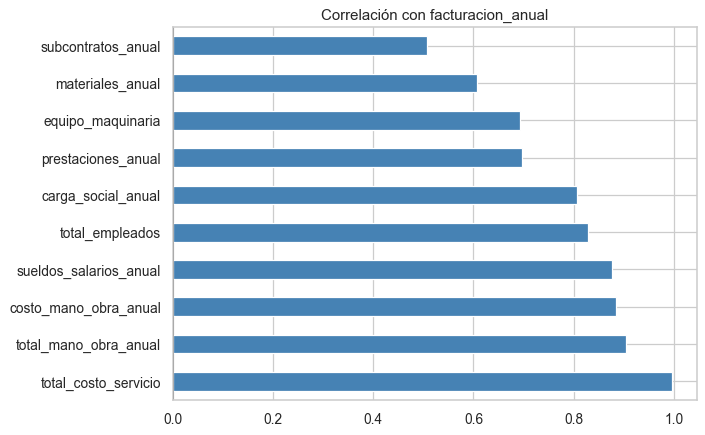

In [35]:
# Correlación con la variable objetivo
if 'facturacion_anual' in corr.columns:
    corr_obj = corr['facturacion_anual'].drop('facturacion_anual').sort_values(ascending=False)
    print('Correlación de cada variable con facturacion_anual:')
    print(corr_obj)

    plt.figure(figsize=(8, 5))
    corr_obj.plot(kind='barh', color=corr_obj.map(lambda v: 'steelblue' if v > 0 else 'salmon'))
    plt.title('Correlación con facturacion_anual')
    plt.axvline(0, color='black', lw=0.6)
    plt.tight_layout()
    plt.show()

**Respuesta — Pregunta 7 (correlación variables independientes → objetivo):**

- `total_costo_servicio` tiene r ≈ 0.995 con `facturacion_anual` → relación contable directa (data leakage, NO usar como feature).
- `total_mano_obra_anual` (r ≈ 0.90) y `total_empleados` (r ≈ 0.83) son los **mejores predictores no triviales**.
- `carga_social_anual` (r ≈ 0.81), `prestaciones_anual` (r ≈ 0.70) y `equipo_maquinaria` (r ≈ 0.69) tienen correlación moderada-alta.
- `subcontratos_anual` (r ≈ 0.51) tiene la correlación más baja de las features clave.

**Multicolinealidad crítica detectada:**
- `total_mano_obra_anual` ≈ `costo_mano_obra_anual` ≈ `sueldos_salarios_anual` (r > 0.98): son la misma información reportada en diferentes secciones del estudio.
- `carga_social_anual` ≈ `sueldos_salarios_anual` (r ≈ 0.95): la carga social se calcula como % del salario, por construcción.

**Decisión:** conservar solo `total_mano_obra_anual` como representante del bloque de mano de obra.

### Hallazgos relevantes

El análisis de correlación con la variable objetivo (`facturacion_anual`) confirma que las variables financieras y operativas presentan relaciones positivas fuertes con el tamaño económico de los contratos.

Las variables con mayor correlación son:

- `total_costo_servicio` (`r = 1.00`)
- `total_mano_obra_anual` (`r = 0.90`)
- `costo_mano_obra_anual` (`r = 0.88`)
- `sueldos_salarios_anual` (`r = 0.88`)
- `total_empleados` (`r = 0.83`)

Estos resultados muestran que la dimensión operativa de los servicios, particularmente la mano de obra y la estructura de costos, es el principal factor asociado a la facturación anual en proyectos de Facility Management.

Asimismo, variables como `materiales_anual`, `prestaciones_anual` y `equipo_maquinaria` presentan correlaciones moderadas, lo que indica que también contribuyen a explicar la variabilidad financiera, aunque con menor peso relativo.

Por otro lado, la correlación perfecta observada en `total_costo_servicio` confirma nuevamente un problema de *data leakage*, ya que dicha variable contiene información derivada directamente de la facturación.

En términos analíticos, el comportamiento observado valida que la facturación histórica depende principalmente de la complejidad operativa, intensidad de personal y estructura de costos de cada contrato.

### 17.1 Pairplot sobre un subconjunto reducido

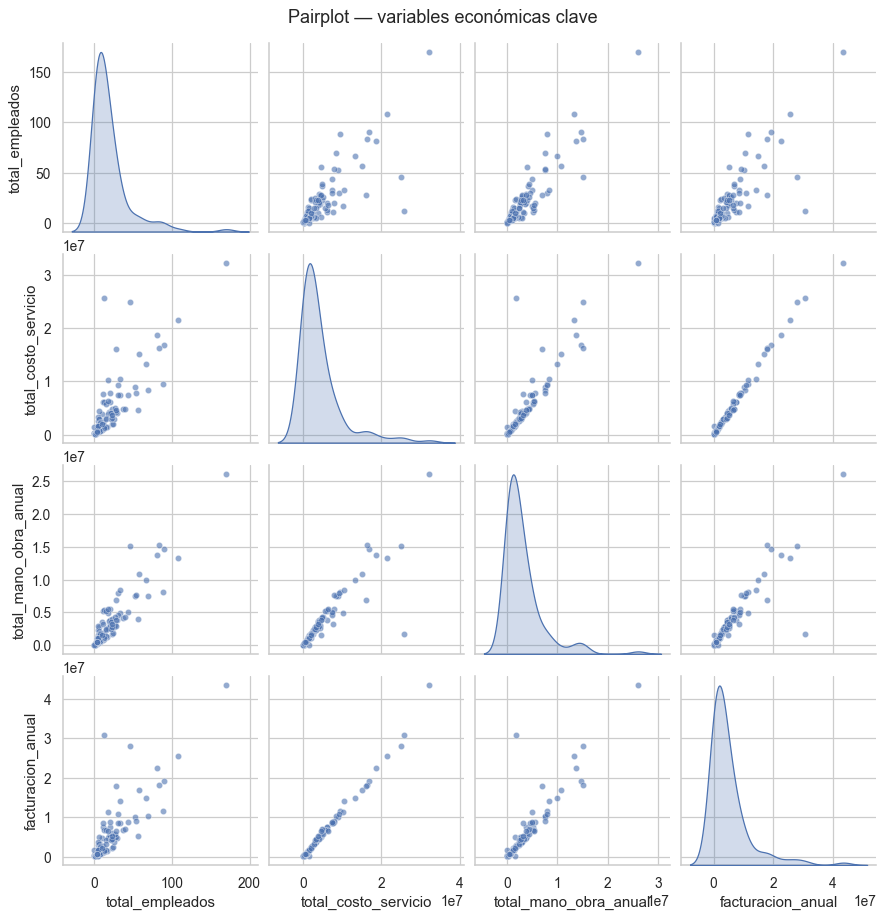

In [36]:
subset_pair = [c for c in ['total_empleados', 'total_costo_servicio',
                            'total_mano_obra_anual', 'facturacion_anual']
               if c in resumen_clean.columns]

sns.pairplot(
    resumen_clean[subset_pair].dropna(),
    diag_kind='kde', plot_kws={'alpha': 0.6, 's': 25}
)
plt.suptitle('Pairplot — variables económicas clave', y=1.02)
plt.show()

### Hallazgos relevantes del pairplot

El pairplot confirma visualmente las relaciones lineales positivas identificadas previamente en la matriz de correlación.

Se observan asociaciones particularmente fuertes entre:

- `facturacion_anual` y `total_costo_servicio`
- `facturacion_anual` y `total_mano_obra_anual`
- `total_mano_obra_anual` y `total_costo_servicio`

Las distribuciones diagonales muestran nuevamente una alta asimetría positiva (*right-skewed distributions*), donde la mayoría de los contratos presentan tamaños pequeños o medianos, mientras que un grupo reducido concentra valores muy altos.

Asimismo, se identifican algunos outliers correspondientes a contratos de gran escala, especialmente en:
- facturación anual,
- costo total del servicio,
- y número de empleados.

Estos resultados son consistentes con la naturaleza del negocio de Facility Management, donde pocos contratos estratégicos concentran gran parte del valor económico.

El pairplot también permite visualizar claramente la multicolinealidad entre variables financieras derivadas de la estructura operativa del servicio.

### 17.2 Correlación entre variables independientes entre sí

> **Pregunta 10 del EDA:** ¿Hay correlación entre variables independientes entre sí (más allá de la relación con el objetivo)?

Analizamos las relaciones entre features para detectar redundancias no capturadas aún por el umbral de 0.95.

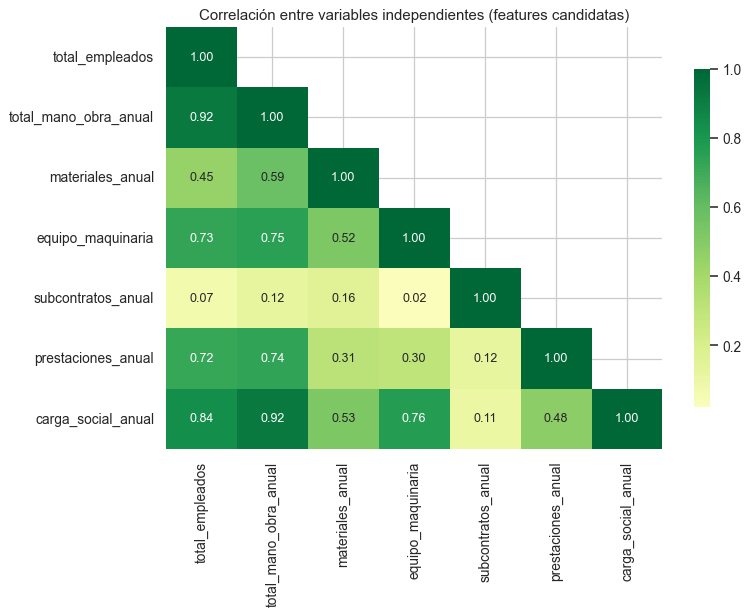

In [37]:
# Features independientes (excluimos la variable objetivo y total_costo_servicio por data leakage)
features_indep = [
    'total_empleados', 'total_mano_obra_anual',
    'materiales_anual', 'equipo_maquinaria',
    'subcontratos_anual', 'prestaciones_anual', 'carga_social_anual'
]
features_indep = [c for c in features_indep if c in resumen_clean.columns]

corr_indep = resumen_clean[features_indep].corr()

plt.figure(figsize=(9, 7))
mask_indep = np.triu(np.ones_like(corr_indep, dtype=bool), k=1)
sns.heatmap(
    corr_indep, mask=mask_indep, cmap='RdYlGn', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlación entre variables independientes (features candidatas)')
plt.tight_layout()
plt.show()

Pares de features con |r| >= 0.60: 8
 total_empleados ↔ total_mano_obra_anual: r = 0.922
 total_empleados ↔ equipo_maquinaria: r = 0.725
 total_empleados ↔ prestaciones_anual: r = 0.722
 total_empleados ↔ carga_social_anual: r = 0.839
 total_mano_obra_anual ↔ equipo_maquinaria: r = 0.754
 total_mano_obra_anual ↔ prestaciones_anual: r = 0.739
 total_mano_obra_anual ↔ carga_social_anual: r = 0.923
 equipo_maquinaria ↔ carga_social_anual: r = 0.764


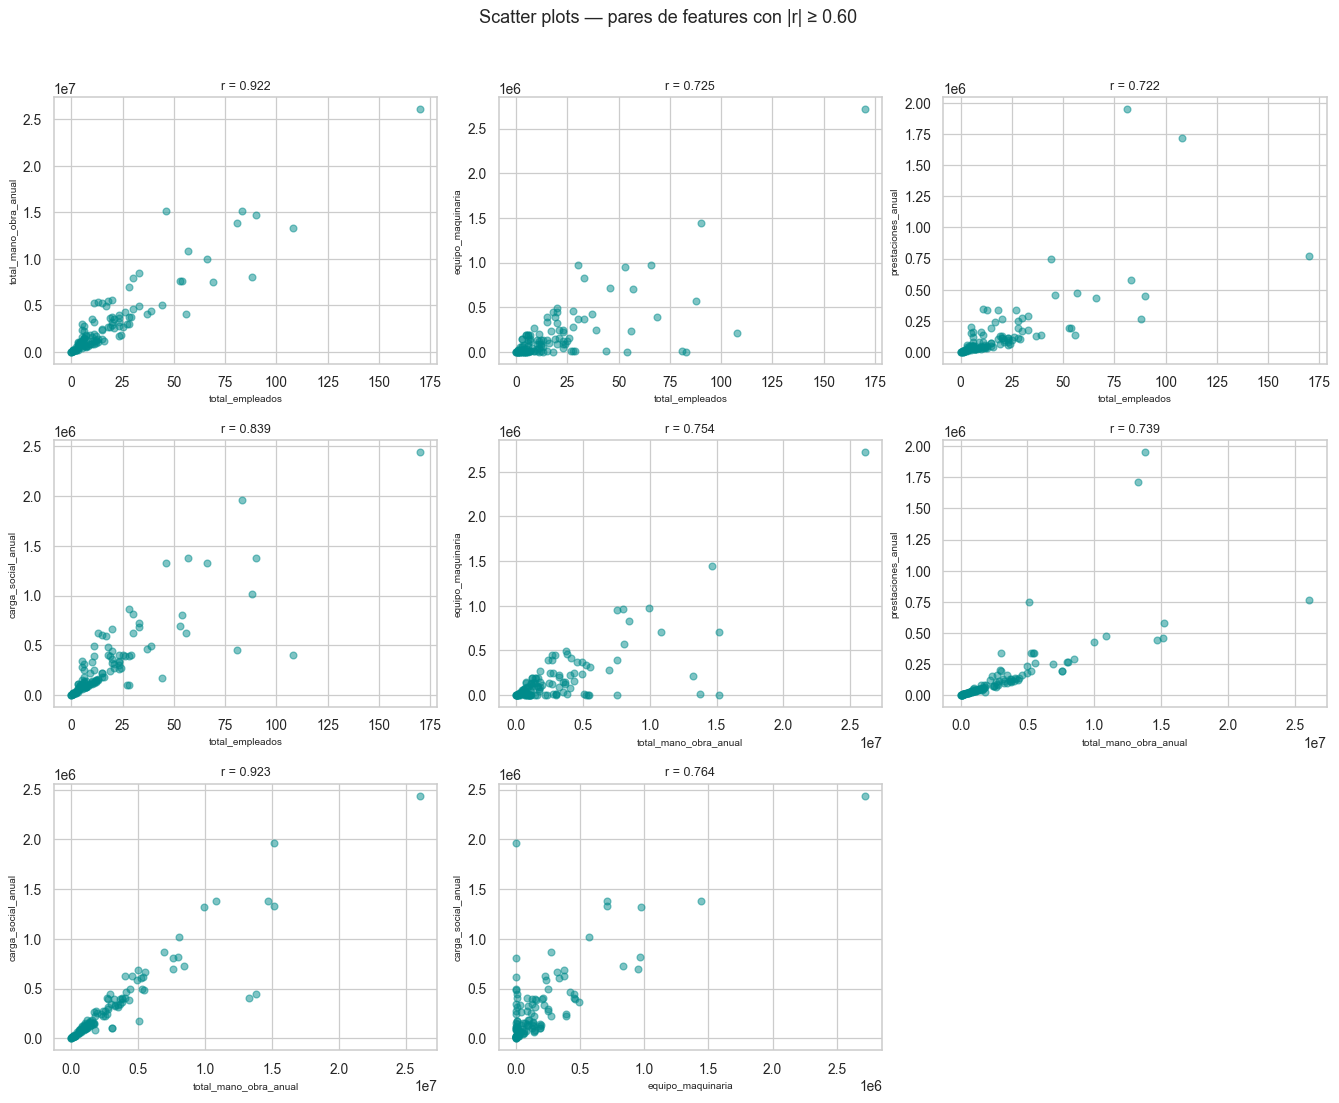

In [38]:
# Scatter plots entre pares de features con correlación moderada-alta (|r| > 0.6)
pares_moderados = []
for i, c1 in enumerate(corr_indep.columns):
    for c2 in corr_indep.columns[i+1:]:
        r = corr_indep.loc[c1, c2]
        if abs(r) >= 0.60:
            pares_moderados.append((c1, c2, round(r, 3)))

print(f'Pares de features con |r| >= 0.60: {len(pares_moderados)}')
for c1, c2, r in pares_moderados:
    print(f' {c1} ↔ {c2}: r = {r}')

if pares_moderados:
    n = len(pares_moderados)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()
    for idx, (c1, c2, r) in enumerate(pares_moderados):
        axes[idx].scatter(resumen_clean[c1], resumen_clean[c2], alpha=0.5, s=30, color='darkcyan')
        axes[idx].set_xlabel(c1, fontsize=8)
        axes[idx].set_ylabel(c2, fontsize=8)
        axes[idx].set_title(f'r = {r}', fontsize=10)
    for idx in range(len(pares_moderados), len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle('Scatter plots — pares de features con |r| ≥ 0.60', y=1.02)
    plt.tight_layout()
    plt.show()

**Respuesta — Pregunta 10 (correlación entre variables independientes):**

- `total_empleados` ↔ `total_mano_obra_anual` (r ≈ 0.92): altamente correlacionadas — a más empleados, mayor costo de mano de obra. Son conceptualmente distintas pero capturan información similar.
- `total_mano_obra_anual` ↔ `equipo_maquinaria` (r ≈ 0.75): proyectos con mucha mano de obra también tienden a requerir más maquinaria.
- `total_empleados` ↔ `equipo_maquinaria` (r ≈ 0.73): misma lógica operativa.
- `total_mano_obra_anual` ↔ `materiales_anual` (r ≈ 0.59): correlación moderada.
- `subcontratos_anual` tiene correlaciones bajas con todas las demás features (r < 0.20), lo que indica que captura **información independiente** no explicada por las otras variables.

**Implicación para el modelo:** aunque hay correlación entre features, ningún par supera 0.95 (umbral de multicolinealidad severa) una vez eliminadas las redundancias. Se puede proceder con todas las features seleccionadas, o considerar PCA si se busca mayor ortogonalidad.

Interpretación:
Las variables asociadas a mano de obra, prestaciones y maquinaria tienden a crecer conjuntamente debido a la naturaleza operativa de los servicios de Facility Management.

Conclusión:
No se detecta multicolinealidad severa adicional más allá de la previamente identificada en la Pregunta 7.

## 18. Detección de valores atípicos por método IQR

> **Pregunta 3 del EDA:** ¿Hay valores atípicos en el conjunto de datos?

Identificamos atípicos como observaciones fuera del intervalo $[Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR]$.

In [39]:
def detectar_outliers_iqr(df, columnas):
    resultados = []
    for col in columnas:
        s = df[col].dropna()
        if len(s) == 0:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = s[(s < li) | (s > ls)]
        resultados.append({
            'variable': col,
            'outliers': len(outliers),
            'pct': round(len(outliers) / len(s) * 100, 2),
            'limite_inferior': round(li, 2),
            'limite_superior': round(ls, 2),
        })
    return pd.DataFrame(resultados).sort_values('pct', ascending=False)

outliers_df = detectar_outliers_iqr(resumen_clean, variables_numericas_clave)
outliers_df

,variable,outliers,pct,limite_inferior,limite_superior
4,subcontratos_anual,23,19.33,"-124,425.00","207,375.00"
9,prestaciones_anual,13,11.02,"-144,625.86","304,589.57"
0,total_empleados,12,10.08,-23.25,50.75
6,facturacion_anual,11,9.24,"-6,752,632.89","13,923,971.81"
7,costo_mano_obra_anual,10,8.47,"-2,862,097.90","6,524,084.95"
8,sueldos_salarios_anual,10,8.47,"-2,229,586.58","5,130,916.06"
2,materiales_anual,10,8.40,"-284,436.57","490,099.65"
5,total_costo_servicio,10,8.40,"-4,940,074.03","10,632,591.00"
1,total_mano_obra_anual,9,7.56,"-3,869,175.78","8,385,023.58"
3,equipo_maquinaria,9,7.56,"-298,756.97","510,398.58"


In [40]:
# Visualizar los outliers en facturacion_anual identificando quiénes son
q1 = resumen_clean['facturacion_anual'].quantile(0.25)
q3 = resumen_clean['facturacion_anual'].quantile(0.75)
iqr = q3 - q1
ls_fact = q3 + 1.5 * iqr

outliers_fact = resumen_clean[resumen_clean['facturacion_anual'] > ls_fact][['cliente', 'facturacion_anual', 'tipo_servicio', 'total_empleados']]
print('Proyectos atípicos en facturación anual (por encima del límite IQR):')
print(outliers_fact.sort_values('facturacion_anual', ascending=False).to_string())

Proyectos atípicos en facturación anual (por encima del límite IQR):
                                           cliente  facturacion_anual        tipo_servicio  total_empleados
99                   Kenworth Mexicana S.A de C.V.      43,529,047.59             LIMPIEZA              170
29                           BMW SLP, S.A. DE C.V.      30,750,381.85  FACILITY MANAGEMENT               12
28                           BMW SLP, S.A. DE C.V.      27,990,532.56        MANTENIMIENTO               46
70   GRUPO AEROPORTUARIO DEL PACÍFICO, S.A DE C.V.      25,587,104.45             LIMPIEZA              108
72   GRUPO AEROPORTUARIO DEL PACÍFICO, S.A DE C.V.      22,578,345.33             LIMPIEZA               81
24      KELLOGG COMPANY MEXICO, S. DE R.L. DE C.V.      19,227,576.55             LIMPIEZA               90
55                             GRUPO MODELO MEXICO      18,056,725.60             LIMPIEZA               83
67                                         CUMMINS      17,988,067.

**Respuesta — Pregunta 3:**

- **Sí hay valores atípicos:** entre el 6% y 19% de las observaciones quedan fuera del rango IQR según la variable.
- `subcontratos_anual` tiene el mayor porcentaje de atípicos (19.3%) por la acumulación de ceros.
- `facturacion_anual` tiene 11 atípicos (9.24%), correspondientes a contratos industriales de gran escala: **BMW, CATERPILLAR, CUMMINS, Grupo Aeroportuario** — estos son proyectos reales y válidos para el negocio.
- **Decisión: NO se eliminan los atípicos.** Representan contratos de gran escala reales (clientes industriales), no errores de captura. Eliminarlos sesgaría el modelo hacia proyectos pequeños y lo haría inutilizable para los contratos más importantes.
- En cambio, se aplica **transformación logarítmica** para reducir el peso desproporcionado de estos valores extremos en el modelo.

### 18.1 Detección de valores atípicos — `Detalle_Empleados`

Aplicamos el mismo método IQR a las variables numéricas de la hoja de empleados.

In [41]:
# — Detalle_Empleados — outliers por IQR
outliers_det = detectar_outliers_iqr(detalle_clean, ['num_empleados', 'importe_anual', 'importe_mensual'])
print('Atípicos por método IQR — Detalle_Empleados:')
print(outliers_det.to_string(index=False))

# Visualizar outliers de importe_anual
q1_d = detalle_clean['importe_anual'].quantile(0.25)
q3_d = detalle_clean['importe_anual'].quantile(0.75)
iqr_d = q3_d - q1_d
ls_d = q3_d + 1.5 * iqr_d

outliers_imp = detalle_clean[detalle_clean['importe_anual'] > ls_d][[
    'categoria', 'cliente', 'importe_anual', 'num_empleados'
]].sort_values('importe_anual', ascending=False).head(10)

print('\nPartidas con importe_anual atípico (encima del límite IQR):')
print(outliers_imp.to_string(index=False))

print("""
Respuesta — Pregunta 3 (Detalle_Empleados):
- importe_anual e importe_mensual presentan ~15-20% de atípicos por IQR,
  consistente con el patrón observado en Resumen_General: unos pocos contratos
  de gran escala (muchos empleados, alto importe) elevan los límites superiores.
- num_empleados tiene atípicos correspondientes a categorías masivas
  (ej. Operario de Limpieza Diurno con 48+ empleados en contratos grandes).
- Decisión: se conservan, son datos válidos del negocio. La transformación
  log1p aplicada en sección 19.4 mitiga su impacto en el modelo.
""")

Atípicos por método IQR — Detalle_Empleados:
       variable  outliers   pct  limite_inferior  limite_superior
  num_empleados        60 13.86            -3.50             8.50
  importe_anual        41  9.47      -765,794.76     1,863,139.32
importe_mensual        41  9.47       -63,816.23       155,261.61

Partidas con importe_anual atípico (encima del límite IQR):
                 categoria                                       cliente  importe_anual  num_empleados
       TECNICO DE LIMPIEZA                 Kenworth Mexicana S.A de C.V.   9,966,509.28          69.00
    INTENDENTE DE LIMPIEZA GRUPO AEROPORTUARIO DEL PACÍFICO, S.A DE C.V.   9,693,735.48          85.00
    INTENDENTE DE LIMPIEZA    KELLOGG COMPANY MEXICO, S. DE R.L. DE C.V.   9,582,580.80          65.00
    INTENDENTE DE LIMPIEZA GRUPO AEROPORTUARIO DEL PACÍFICO, S.A DE C.V.   8,999,941.44          58.00
       TECNICO DE LIMPIEZA                                   CATERPILLAR   8,228,952.74          47.00
       TECNI

---

# Avance 2 — Ingeniería de Características (Feature Engineering)

> En esta segunda entrega se aborda la fase de **Data Preparation** de la metodología **CRISP-ML(Q)**, partiendo del EDA del Avance 1. El objetivo es transformar el conjunto de datos crudo en un *feature set* listo para modelado predictivo (regresión sobre `facturacion_anual`), siguiendo cuatro bloques:
>
> 1. **Construcción** de nuevas características y codificación de categóricas.
> 2. **Normalización / Transformación** de variables sesgadas y escalamiento.
> 3. **Selección y Extracción** de características mediante métodos de filtrado (varianza, correlación, ANOVA, Mutual Information, Chi-cuadrado) y extracción (PCA, FA).
> 4. **Conclusiones** de la fase en el contexto CRISP-ML(Q).



## A2.1 Librerías adicionales y *snapshot* del estado actual

Se cargan utilidades adicionales de `scikit-learn` y `scipy` necesarias para las transformaciones, pruebas de filtrado y extracción de características. Se parte del DataFrame `resumen_clean` producido por la limpieza del Avance 1.

In [42]:
# --- Librerías adicionales para el Avance 2 ---
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    PowerTransformer, KBinsDiscretizer, OneHotEncoder, LabelEncoder
)
from sklearn.feature_selection import (
    VarianceThreshold, f_regression, mutual_info_regression,
    chi2, SelectKBest
)
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.impute import SimpleImputer
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

print('Forma de resumen_clean:', resumen_clean.shape)
print('Forma de detalle_clean:', detalle_clean.shape)
print('Variable objetivo: facturacion_anual')
print('Tarea: Regresión')

Forma de resumen_clean: (119, 80)
Forma de detalle_clean: (433, 8)
Variable objetivo: facturacion_anual
Tarea: Regresión


---

## A2.2 Construcción de nuevas características (Feature Engineering)


### A2.2.1 Marco general

Partimos del análisis del Avance 1, donde se observó que la **facturación anual** de una cotización B2B en Facility Management depende fundamentalmente de tres ejes:

1. **Dimensionamiento operativo** (cuántas personas, qué categorías laborales) — capturado por `total_empleados` y la hoja `Detalle_Empleados`.
2. **Composición del costo** (cuánto se gasta en mano de obra vs. materiales vs. maquinaria vs. subcontratos).
3. **Contexto comercial** (cliente, tipo de servicio, región, año del estudio).

Las variables originales capturan estos ejes en **valores absolutos**, lo cual sesga la representación: un proyecto pequeño con mucha intensidad de mano de obra puede tener un costo similar al de uno grande con baja intensidad. Para corregir esto, construimos features que expresan **intensidad**, **mezcla** y **escala** de manera relativa.

Todas las features nuevas se justifican por **dominio del negocio**, no por "probar todas las combinaciones posibles".

### A2.2.2 Preparación del DataFrame base

In [43]:
# Partimos de resumen_clean (ya limpio) y agregamos features.
df_fe = resumen_clean.copy()

# Reemplazos seguros para evitar divisiones por cero
df_fe['_empleados_safe'] = df_fe['total_empleados'].replace(0, np.nan)
df_fe['_costo_safe'] = df_fe['total_costo_servicio'].replace(0, np.nan)
df_fe['_mano_obra_safe'] = df_fe['total_mano_obra_anual'].replace(0, np.nan)
df_fe['_facturacion_safe'] = df_fe['facturacion_anual'].replace(0, np.nan)

print('Base para FE:', df_fe.shape)

Base para FE: (119, 84)


### A2.2.3 Features de **intensidad operativa** (ratios por empleado)

**Justificación de dominio.** En Facility Management el costo y la facturación escalan, en primera aproximación, con la cantidad de personal. Por ello, dos contratos con el mismo `total_costo_servicio` pero distinto `total_empleados` representan estructuras económicas muy diferentes. Las siguientes ratios *normalizan por persona* y expresan eficiencia/intensidad:

- `facturacion_por_empleado` — ingreso medio que aporta cada persona del contrato (proxy de **productividad económica**).
- `costo_por_empleado` — costo medio por persona (proxy de **carga operativa** unitaria).
- `mano_obra_por_empleado` — costo laboral promedio (proxy de **mix de categorías**: a mayor especialización, mayor valor).
- `materiales_por_empleado` y `maquinaria_por_empleado` — capturan la **intensidad de insumos** del servicio.

In [44]:
# Features de intensidad por empleado
df_fe['facturacion_por_empleado'] = df_fe['facturacion_anual'] / df_fe['_empleados_safe']
df_fe['costo_por_empleado'] = df_fe['total_costo_servicio'] / df_fe['_empleados_safe']
df_fe['mano_obra_por_empleado'] = df_fe['total_mano_obra_anual'] / df_fe['_empleados_safe']
df_fe['materiales_por_empleado'] = df_fe['materiales_anual'] / df_fe['_empleados_safe']
df_fe['maquinaria_por_empleado'] = df_fe['equipo_maquinaria'] / df_fe['_empleados_safe']

intensidad = ['facturacion_por_empleado', 'costo_por_empleado',
              'mano_obra_por_empleado', 'materiales_por_empleado',
              'maquinaria_por_empleado']
df_fe[intensidad].describe().round(2)

,facturacion_por_empleado,costo_por_empleado,mano_obra_por_empleado,materiales_por_empleado,maquinaria_por_empleado
count,116.00,116.00,116.00,116.00,116.00
mean,"286,470.61","247,298.81","178,525.04","10,955.24","10,062.54"
std,"269,886.01","229,474.74","99,444.37","13,979.32","10,752.34"
min,"20,209.96","71,699.97","67,992.90",0.00,0.00
25%,"148,019.91","124,625.43","107,915.67","3,309.69",519.60
50%,"221,565.96","192,997.19","151,453.72","6,349.55","7,057.97"
75%,"338,256.31","299,937.59","235,973.34","12,300.00","16,104.80"
max,"2,562,531.82","2,141,660.24","594,105.36","84,446.87","47,609.67"


### A2.2.4 Features de **composición del costo** (ratios sobre el costo total)

**Justificación de dominio.** Dos contratos pueden tener el mismo costo total pero composiciones radicalmente distintas (uno intensivo en mano de obra, otro en subcontratación). Estas ratios capturan la **estructura interna del servicio**, que es decisiva para la rentabilidad y el riesgo del contrato:

- `ratio_mano_obra` — fracción del costo total que va a personal directo (típicamente 60–85% en limpieza).
- `ratio_materiales`, `ratio_maquinaria`, `ratio_subcontratos` — mezcla del resto del costo.
- `ratio_cargas_sociales` — peso fiscal/laboral, indicador de la formalidad y del marco regulatorio aplicado.

Estas ratios son **independientes de la escala** del proyecto, lo que las hace muy útiles para que el modelo distinga el **patrón económico** sin confundirlo con el **tamaño**.

> Nota de control de calidad: aunque estas variables usan `total_costo_servicio` como denominador, no representan el monto absoluto del costo ni la facturación objetivo. Se mantienen porque expresan la composición relativa del contrato. Aun así, se monitorearán en la fase de modelado para evitar dependencia excesiva de variables contables derivadas.


In [45]:
# Features de composición del costo
df_fe['ratio_mano_obra'] = df_fe['total_mano_obra_anual'] / df_fe['_costo_safe']
df_fe['ratio_materiales'] = df_fe['materiales_anual'] / df_fe['_costo_safe']
df_fe['ratio_maquinaria'] = df_fe['equipo_maquinaria'] / df_fe['_costo_safe']
df_fe['ratio_subcontratos'] = df_fe['subcontratos_anual'] / df_fe['_costo_safe']
df_fe['ratio_cargas_sociales']= df_fe['carga_social_anual'] / df_fe['_costo_safe']
df_fe['ratio_prestaciones'] = df_fe['prestaciones_anual'] / df_fe['_costo_safe']

composicion = ['ratio_mano_obra', 'ratio_materiales', 'ratio_maquinaria',
               'ratio_subcontratos', 'ratio_cargas_sociales', 'ratio_prestaciones']
df_fe[composicion].describe().round(3)

,ratio_mano_obra,ratio_materiales,ratio_maquinaria,ratio_subcontratos,ratio_cargas_sociales,ratio_prestaciones
count,119.00,119.00,119.00,119.00,118.00,118.00
mean,0.79,0.05,0.04,0.07,0.09,0.03
std,0.19,0.05,0.04,0.19,0.03,0.01
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.75,0.00,0.00,0.00,0.07,0.02
50%,0.85,0.04,0.04,0.00,0.09,0.03
75%,0.90,0.07,0.08,0.03,0.11,0.03
max,1.00,0.27,0.15,1.00,0.15,0.10


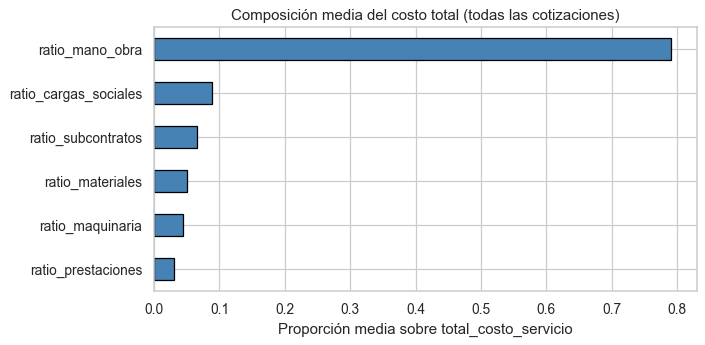

In [46]:
# Visualización: composición media del costo
plt.figure(figsize=(8, 4))
df_fe[composicion].mean().sort_values(ascending=True).plot(
    kind='barh', color='steelblue', edgecolor='black'
)
plt.title('Composición media del costo total (todas las cotizaciones)')
plt.xlabel('Proporción media sobre total_costo_servicio')
plt.tight_layout()
plt.show()

**Lectura.** Como era esperable en servicios de Facility Management, la **mano de obra** domina la estructura de costos (típicamente >60%), seguida de cargas sociales y prestaciones (que son costos laborales indirectos). Materiales y maquinaria suelen pesar poco salvo en contratos de mantenimiento intensivo. Esta jerarquía valida que el dimensionamiento de personal es la palanca económica principal.

### A2.2.5 Features de **margen y rentabilidad estimada**

**Justificación de dominio.** El margen operativo aproximado (`facturación - costo total`) refleja la **rentabilidad bruta** del contrato. Si bien `total_costo_servicio` no puede usarse como predictor directo (data leakage), su ratio respecto a la facturación sí informa sobre el **tipo de contrato** (alto margen vs. servicios commodity).

> Advertencia: **Importante:** Estas features se **calculan y analizan** aquí porque aportan insight de negocio, pero se **marcan como no-utilizables** para entrenar un modelo que predice `facturacion_anual`, ya que están construidas a partir de ella → data leakage.

In [47]:
# Margen operativo y % margen
df_fe['margen_operativo'] = df_fe['facturacion_anual'] - df_fe['total_costo_servicio']
df_fe['margen_operativo_pct'] = df_fe['margen_operativo'] / df_fe['_facturacion_safe']

print('Margen operativo % — estadísticas:')
print(df_fe['margen_operativo_pct'].describe().round(3))

# Marcar explícitamente como no-utilizables (data leakage)
FEATURES_DATA_LEAKAGE = [
    'total_costo_servicio',
    'margen_operativo',
    'margen_operativo_pct',
    'facturacion_por_empleado', # contiene la propia facturacion_anual
    'facturacion_mensual',
    'suma_ingresos_anual', 'suma_ingresos_mensual',
]
print(f'\nAdvertencia: Se excluirán del feature set final {len(FEATURES_DATA_LEAKAGE)} variables por data leakage.')

Margen operativo % — estadísticas:
count   119.00
mean      0.02
std       1.36
min     -14.68
25%       0.11
50%       0.14
75%       0.16
max       0.30
Name: margen_operativo_pct, dtype: float64

Advertencia: Se excluirán del feature set final 7 variables por data leakage.


### A2.2.6 Features **temporales**

**Justificación de dominio.** En §16 del Avance 1 se detectó una tendencia creciente de la facturación mediana entre 2016 y 2022 (~4×). El año del estudio es por tanto una variable explicativa, además del **mes** (estacionalidad de las licitaciones).

In [48]:
# Features temporales (a partir de fecha_analisis)
df_fe['anio_estudio'] = pd.to_datetime(df_fe['fecha_analisis'], errors='coerce').dt.year
df_fe['mes_estudio'] = pd.to_datetime(df_fe['fecha_analisis'], errors='coerce').dt.month
df_fe['trimestre_estudio'] = pd.to_datetime(df_fe['fecha_analisis'], errors='coerce').dt.quarter
# Antigüedad relativa: años desde el estudio más antiguo (para capturar tendencia)
min_year = df_fe['anio_estudio'].min()
df_fe['antiguedad_anios'] = df_fe['anio_estudio'] - min_year

print('Distribución por año:')
print(df_fe['anio_estudio'].value_counts().sort_index())

Distribución por año:
anio_estudio
2016     5
2017    15
2018    31
2019    14
2020    28
2021     3
2022    23
Name: count, dtype: int64


### A2.2.7 **Discretización (binning)** de variables continuas

**Justificación de dominio.** Aunque `total_empleados` es continua, los gerentes comerciales tienden a razonar en **segmentos discretos** (pequeño / mediano / grande / muy grande). Crear una variable categórica de tamaño operativo:

1. Permite capturar relaciones **no lineales** con el target (saltos de complejidad operativa).
2. Habilita interacciones (p.ej. *"contrato grande × región noroeste"*) que un modelo lineal no detectaría con la variable continua.
3. Mejora la interpretabilidad del modelo final.

Se usa **discretización por cuantiles** (KBinsDiscretizer con `strategy='quantile'`) para obtener segmentos balanceados.

In [49]:
# Discretización de total_empleados por cuantiles (cuartiles operativos)
empl = df_fe['total_empleados'].fillna(0).values.reshape(-1, 1)
kbins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df_fe['segmento_tamano'] = kbins.fit_transform(empl).astype(int)

# Etiquetas legibles
labels_tamano = {0: 'Pequeño', 1: 'Mediano', 2: 'Grande', 3: 'Muy grande'}
df_fe['segmento_tamano_lbl'] = df_fe['segmento_tamano'].map(labels_tamano)

print('Bordes de los cuartiles de total_empleados:')
print(np.round(kbins.bin_edges_[0], 1))
print('\nFrecuencia por segmento:')
print(df_fe['segmento_tamano_lbl'].value_counts())

Bordes de los cuartiles de total_empleados:
[  0.    4.5  11.   23.  170. ]

Frecuencia por segmento:
segmento_tamano_lbl
Muy grande    33
Pequeño       30
Grande        28
Mediano       28
Name: count, dtype: int64


### A2.2.8 Features derivadas de la hoja **`Detalle_Empleados`** (agregadas por estudio)

**Justificación de dominio.** La hoja `Detalle_Empleados` tiene 433 filas (una por categoría laboral × estudio). Esta granularidad contiene información crítica que `Resumen_General` no captura por sí sola:

- **Diversidad de categorías laborales** por contrato (un contrato con 10 categorías diferentes es operativamente más complejo que uno con 2).
- **Concentración en categoría dominante** (proxy de complejidad).
- **Importe medio por categoría** (proxy de mix salarial).

Estos features se agregan al nivel `archivo` y se *joinean* a `df_fe`.

In [50]:
# Agregaciones desde Detalle_Empleados (clave = archivo)
detalle_agg = detalle_clean.groupby('archivo').agg(
    n_categorias_laborales = ('categoria', 'nunique'),
    n_partidas_plantilla = ('categoria', 'size'),
    importe_anual_mediano = ('importe_anual', 'median'),
    importe_anual_std = ('importe_anual', 'std'),
    empleados_max_categoria= ('num_empleados', 'max'),
).reset_index()

# Coeficiente de variación del importe → dispersión salarial dentro del contrato
detalle_agg['cv_importe_categoria'] = (
    detalle_agg['importe_anual_std'] / detalle_agg['importe_anual_mediano'].replace(0, np.nan)
)

# Merge a df_fe
df_fe = df_fe.merge(detalle_agg, on='archivo', how='left')

# Imputación de los pocos que no aparecen en Detalle_Empleados
for c in ['n_categorias_laborales', 'n_partidas_plantilla',
          'importe_anual_mediano', 'importe_anual_std',
          'empleados_max_categoria', 'cv_importe_categoria']:
    df_fe[c] = df_fe[c].fillna(df_fe[c].median())

df_fe[['n_categorias_laborales', 'n_partidas_plantilla',
       'importe_anual_mediano', 'empleados_max_categoria',
       'cv_importe_categoria']].describe().round(2)

,n_categorias_laborales,n_partidas_plantilla,importe_anual_mediano,empleados_max_categoria,cv_importe_categoria
count,119.00,119.00,119.00,119.00,119.00
mean,3.71,3.71,"540,674.41",12.61,1.34
std,2.16,2.18,"483,973.00",16.34,1.31
min,1.00,1.00,"71,699.97",1.00,0.04
25%,2.00,2.00,"237,833.64",3.00,0.53
50%,3.00,3.00,"386,491.14",6.00,0.92
75%,5.00,5.00,"641,847.60",16.00,1.53
max,12.00,12.00,"3,218,809.20",85.00,7.30


### A2.2.9 Resumen de features construidas

A continuación se listan **todas** las features nuevas creadas en esta sección, agrupadas por familia y con justificación breve. Las marcadas con Advertencia: son **excluidas del modelo** por data leakage (se conservan solo para diagnóstico).

In [51]:
resumen_fe = pd.DataFrame([
    # --- Intensidad operativa ---
    ('facturacion_por_empleado', 'Intensidad', 'Advertencia: Data leakage', 'Productividad económica/persona'),
    ('costo_por_empleado', 'Intensidad', 'OK', 'Carga operativa unitaria'),
    ('mano_obra_por_empleado', 'Intensidad', 'OK', 'Mix salarial / especialización'),
    ('materiales_por_empleado', 'Intensidad', 'OK', 'Intensidad de insumos'),
    ('maquinaria_por_empleado', 'Intensidad', 'OK', 'Equipamiento por persona'),
    # --- Composición del costo ---
    ('ratio_mano_obra', 'Composición', 'OK', '% del costo que es personal'),
    ('ratio_materiales', 'Composición', 'OK', '% del costo que es materiales'),
    ('ratio_maquinaria', 'Composición', 'OK', '% del costo que es maquinaria'),
    ('ratio_subcontratos', 'Composición', 'OK', '% del costo subcontratado'),
    ('ratio_cargas_sociales', 'Composición', 'OK', 'Peso fiscal/laboral'),
    ('ratio_prestaciones', 'Composición', 'OK', 'Peso de prestaciones'),
    # --- Margen ---
    ('margen_operativo', 'Margen', 'Advertencia: Data leakage', 'Rentabilidad bruta'),
    ('margen_operativo_pct', 'Margen', 'Advertencia: Data leakage', '% de margen'),
    # --- Temporal ---
    ('anio_estudio', 'Temporal', 'OK', 'Año del estudio'),
    ('mes_estudio', 'Temporal', 'OK', 'Mes del estudio (estacionalidad)'),
    ('trimestre_estudio', 'Temporal', 'OK', 'Trimestre del estudio'),
    ('antiguedad_anios', 'Temporal', 'OK', 'Antigüedad relativa'),
    # --- Discretización ---
    ('segmento_tamano', 'Discretización','OK', 'Cuartil operativo'),
    # --- Agregadas de Detalle_Empleados ---
    ('n_categorias_laborales', 'Plantilla', 'OK', 'Diversidad de categorías'),
    ('n_partidas_plantilla', 'Plantilla', 'OK', '# partidas en la plantilla'),
    ('importe_anual_mediano', 'Plantilla', 'OK', 'Mix salarial mediano'),
    ('empleados_max_categoria', 'Plantilla', 'OK', 'Concentración categoría dominante'),
    ('cv_importe_categoria', 'Plantilla', 'OK', 'Dispersión salarial intra-contrato'),
], columns=['Feature', 'Familia', 'Uso para modelar', 'Justificación de dominio'])

resumen_fe

,Feature,Familia,Uso para modelar,Justificación de dominio
0,facturacion_por_empleado,Intensidad,Advertencia: Data leakage,Productividad económica/persona
1,costo_por_empleado,Intensidad,OK,Carga operativa unitaria
2,mano_obra_por_empleado,Intensidad,OK,Mix salarial / especialización
3,materiales_por_empleado,Intensidad,OK,Intensidad de insumos
4,maquinaria_por_empleado,Intensidad,OK,Equipamiento por persona
5,ratio_mano_obra,Composición,OK,% del costo que es personal
6,ratio_materiales,Composición,OK,% del costo que es materiales
7,ratio_maquinaria,Composición,OK,% del costo que es maquinaria
8,ratio_subcontratos,Composición,OK,% del costo subcontratado
9,ratio_cargas_sociales,Composición,OK,Peso fiscal/laboral


---

## A2.3 Codificación de variables categóricas

> Esta sección sigue siendo parte del criterio **Construcción (30 pts)** ya que la codificación es la "construcción de la representación numérica" de las categóricas.

### A2.3.1 Estrategia por variable

| Variable | Cardinalidad (post-limpieza) | Técnica | Justificación |
|---|---|---|---|
| `tipo_servicio` | 7 → 5 (tras agrupar raras) | **One-Hot** | Nominal sin orden; baja cardinalidad |
| `region` | 6 → 4 | **One-Hot** | Nominal sin orden |
| `plaza` | 13 → 7 | **One-Hot** | Nominal; cardinalidad media tras agrupar |
| `estado` | 12 → 9 | **One-Hot** | Nominal |
| `condiciones_pago` | 2 | **Binary** (Label) | Binaria → label encoding equivale a one-hot con drop_first |
| `cliente` | 32 → 14 | **Frequency Encoding** | Alta cardinalidad: one-hot explotaría dimensionalidad; frequency conserva info de "qué tan repetido es el cliente" sin inflar |
| `centro` | 43 → 11 | **Frequency Encoding** | Misma razón que cliente |
| `segmento_tamano_lbl` | 4 | **Ordinal** | Tiene orden natural: Pequeño < Mediano < Grande < Muy grande |

**Por qué no usar Target Encoding.** El Target Encoding (codificar cada categoría por la media del target) es muy potente pero con `n=119` riesga sobreajuste serio y *target leakage* si no se hace con validación cruzada estricta. Se prefiere Frequency Encoding, que no usa el target.

In [52]:
# Antes de codificar: tratamos faltantes categóricos y agrupamos categorías raras (rep. <3 veces) en 'OTROS'.
# Esto evita que aparezcan columnas poco profesionales como estado_nan; los faltantes se documentan como DESCONOCIDO.
def agrupar_raras(s, min_freq=3, etiqueta='OTROS'):
    conteo = s.value_counts(dropna=False)
    raras = conteo[conteo < min_freq].index
    return s.where(~s.isin(raras), etiqueta)

cat_to_group = ['cliente', 'centro', 'plaza', 'region', 'tipo_servicio', 'estado']
for c in cat_to_group:
    if c in df_fe.columns:
        antes = df_fe[c].nunique(dropna=False)
        df_fe[c] = df_fe[c].fillna('DESCONOCIDO').astype(str).str.strip()
        df_fe[c] = agrupar_raras(df_fe[c], min_freq=3)
        despues = df_fe[c].nunique(dropna=False)
        print(f'{c:18s}: {antes:>3d} → {despues:>3d} categorías')

cliente           :  32 →  14 categorías
centro            :  44 →  11 categorías
plaza             :  13 →   7 categorías
region            :   6 →   4 categorías
tipo_servicio     :   7 →   5 categorías
estado            :  13 →   9 categorías


In [53]:
# --- Frequency Encoding para alta cardinalidad ---
for col in ['cliente', 'centro']:
    if col in df_fe.columns:
        freq_map = df_fe[col].value_counts(normalize=True).to_dict()
        df_fe[f'{col}_freq'] = df_fe[col].map(freq_map)

# --- Ordinal Encoding para segmento_tamano_lbl ---
orden_tamano = {'Pequeño': 0, 'Mediano': 1, 'Grande': 2, 'Muy grande': 3}
df_fe['segmento_tamano_ord'] = df_fe['segmento_tamano_lbl'].map(orden_tamano)

# --- Label/Binary para condiciones_pago (es binaria) ---
df_fe['condiciones_pago_bin'] = (
    df_fe['condiciones_pago'].astype(str).str.contains('90', na=False).astype(int)
)

# --- One-Hot para nominales de baja cardinalidad ---
cat_onehot = ['tipo_servicio', 'region', 'plaza', 'estado']
df_fe_encoded = pd.get_dummies(df_fe, columns=cat_onehot, drop_first=True, dtype=int)

print(f'Dimensiones tras codificación: {df_fe_encoded.shape}')
print(f'Columnas nuevas one-hot: {df_fe_encoded.shape[1] - df_fe.shape[1] + len(cat_onehot)}')

Dimensiones tras codificación: (119, 130)
Columnas nuevas one-hot: 21


---

## A2.4 Transformaciones para reducir sesgo


### A2.4.1 Diagnóstico: variables que requieren transformación

En el Avance 1 se documentó que **todas** las variables económicas tienen sesgo positivo fuerte (skewness entre 2.3 y 8.3). Esto afecta:
- Modelos lineales (asumen residuos normales).
- Modelos basados en distancias (k-NN, k-means).
- Optimización por gradiente (convergencia más lenta).

Probaremos y compararemos **tres transformaciones** sobre las variables sesgadas: `log1p`, **Yeo-Johnson** y **Box-Cox**, eligiendo la que mejor normaliza cada variable.

In [54]:
# Variables candidatas a transformación (numéricas con sesgo > 1)
vars_a_transformar = [
    'facturacion_anual', 'total_mano_obra_anual', 'materiales_anual',
    'equipo_maquinaria', 'subcontratos_anual', 'prestaciones_anual',
    'carga_social_anual', 'total_empleados',
    'costo_por_empleado', 'mano_obra_por_empleado',
    'importe_anual_mediano', 'empleados_max_categoria',
]
vars_a_transformar = [v for v in vars_a_transformar if v in df_fe_encoded.columns]

# Skewness original
skew_original = df_fe_encoded[vars_a_transformar].skew().rename('skew_original')
print('Sesgo original:')
print(skew_original.round(2).sort_values(ascending=False))

Sesgo original:
subcontratos_anual        8.28
materiales_anual          6.21
costo_por_empleado        5.26
prestaciones_anual        4.85
equipo_maquinaria         4.53
total_empleados           2.99
facturacion_anual         2.86
total_mano_obra_anual     2.83
carga_social_anual        2.81
importe_anual_mediano     2.54
empleados_max_categoria   2.28
mano_obra_por_empleado    1.55
Name: skew_original, dtype: float64


### A2.4.2 Comparación: `log1p` vs Yeo-Johnson vs Box-Cox

- **`log1p`** = log(1+x). Maneja ceros, pero no negativos. Simple e interpretable; se evalúa como alternativa por su facilidad de interpretación.
- **Box-Cox** requiere `x > 0` estrictamente; estima un parámetro λ óptimo que maximiza la log-verosimilitud bajo normalidad.
- **Yeo-Johnson** generalización de Box-Cox que admite **ceros y negativos**. Es la opción más segura cuando hay ceros (frecuente en `subcontratos_anual`, `equipo_maquinaria`).

Se aplican las tres a cada variable, se mide el sesgo resultante y se elige la mejor.

In [55]:
# Inicializamos transformadores
pt_yeo = PowerTransformer(method='yeo-johnson', standardize=False)
pt_bc = PowerTransformer(method='box-cox', standardize=False)

comparativo = []
for v in vars_a_transformar:
    x = df_fe_encoded[v].astype(float).copy()
    # log1p: clip a >=0 por seguridad (estas variables son no-negativas por naturaleza)
    x_clip = x.clip(lower=0)
    x_log = np.log1p(x_clip)

    # Yeo-Johnson (acepta cualquier valor)
    x_yeo = pt_yeo.fit_transform(x.values.reshape(-1, 1)).ravel()

    # Box-Cox sólo si todos los valores son estrictamente positivos
    if (x > 0).all():
        x_bc = pt_bc.fit_transform(x.values.reshape(-1, 1)).ravel()
        skew_bc = pd.Series(x_bc).skew()
    else:
        skew_bc = np.nan

    comparativo.append({
        'variable': v,
        'skew_original': x.skew(),
        'skew_log1p': pd.Series(x_log).skew(),
        'skew_yeo': pd.Series(x_yeo).skew(),
        'skew_boxcox': skew_bc,
    })

comp_df = pd.DataFrame(comparativo).set_index('variable').round(3)
comp_df['mejor_tecnica'] = comp_df[['skew_log1p', 'skew_yeo', 'skew_boxcox']].abs().idxmin(axis=1)
comp_df

,skew_original,skew_log1p,skew_yeo,skew_boxcox,mejor_tecnica
variable,,,,,
facturacion_anual,2.86,-0.37,-0.02,-0.02,skew_yeo
total_mano_obra_anual,2.83,-4.05,-0.02,NaN,skew_yeo
materiales_anual,6.21,-1.06,-0.46,NaN,skew_yeo
equipo_maquinaria,4.53,-1.19,-0.40,NaN,skew_yeo
subcontratos_anual,8.28,0.95,0.88,NaN,skew_yeo
prestaciones_anual,4.85,-2.85,0.13,NaN,skew_yeo
carga_social_anual,2.81,-3.67,0.02,NaN,skew_yeo
total_empleados,2.98,0.00,0.00,NaN,skew_yeo
costo_por_empleado,5.26,0.67,0.04,NaN,skew_yeo


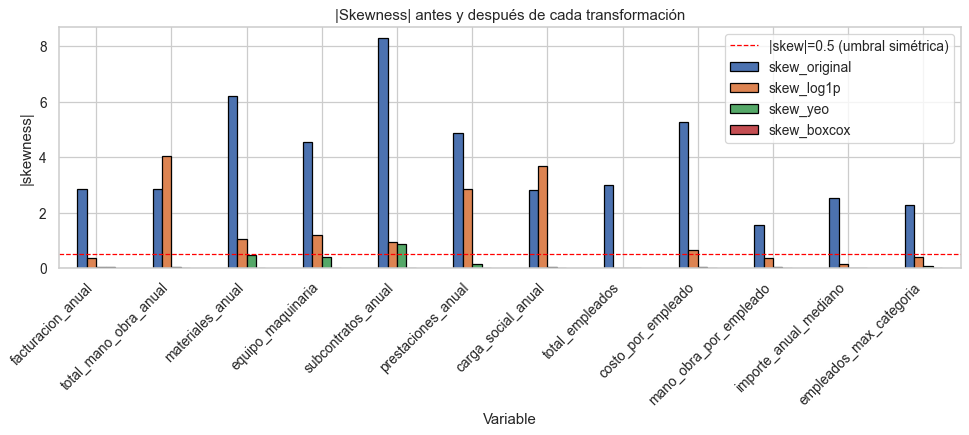

In [56]:
# Visualización: |skew| antes vs después por técnica
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = comp_df[['skew_original', 'skew_log1p', 'skew_yeo', 'skew_boxcox']].abs()
plot_df.plot(kind='bar', ax=ax, edgecolor='black')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='|skew|=0.5 (umbral simétrica)')
ax.set_title('|Skewness| antes y después de cada transformación')
ax.set_ylabel('|skewness|')
ax.set_xlabel('Variable')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

**Decisión.** Para cada variable, se aplica la transformación que **minimiza |skewness|**. Cuando el ganador es Yeo-Johnson o Box-Cox por un margen pequeño sobre `log1p`, se prefiere `log1p` por **interpretabilidad** (un coeficiente sobre `log(x)` se traduce en elasticidad). Cuando la diferencia es grande (>0.3 en |skew|), se prefiere la técnica óptima.

In [57]:
# Aplicamos la mejor técnica según comparativo, con preferencia por log1p en empates
df_trans = df_fe_encoded.copy()

# Refit de transformadores en una sola pasada
pt_yeo = PowerTransformer(method='yeo-johnson', standardize=False)
pt_bc = PowerTransformer(method='box-cox', standardize=False)

decisiones = {}
for v in vars_a_transformar:
    skews = comp_df.loc[v, ['skew_log1p', 'skew_yeo', 'skew_boxcox']].abs()
    mejor = skews.idxmin()
    # Preferencia por log1p si la diferencia es <0.3
    if mejor != 'skew_log1p' and not pd.isna(skews['skew_log1p']):
        if (skews['skew_log1p'] - skews[mejor]) < 0.30:
            mejor = 'skew_log1p'

    x = df_trans[v].astype(float).values
    if mejor == 'skew_log1p':
        df_trans[f'{v}_trans'] = np.log1p(np.clip(x, 0, None))
        decisiones[v] = 'log1p'
    elif mejor == 'skew_yeo':
        df_trans[f'{v}_trans'] = pt_yeo.fit_transform(x.reshape(-1, 1)).ravel()
        decisiones[v] = 'yeo-johnson'
    else:
        df_trans[f'{v}_trans'] = pt_bc.fit_transform(x.reshape(-1, 1)).ravel()
        decisiones[v] = 'box-cox'

print('Técnica elegida por variable:')
for k, v in decisiones.items():
    print(f' {k:32s} → {v}')

Técnica elegida por variable:
 facturacion_anual                → yeo-johnson
 total_mano_obra_anual            → yeo-johnson
 materiales_anual                 → yeo-johnson
 equipo_maquinaria                → yeo-johnson
 subcontratos_anual               → log1p
 prestaciones_anual               → yeo-johnson
 carga_social_anual               → yeo-johnson
 total_empleados                  → log1p
 costo_por_empleado               → yeo-johnson
 mano_obra_por_empleado           → yeo-johnson
 importe_anual_mediano            → log1p
 empleados_max_categoria          → box-cox


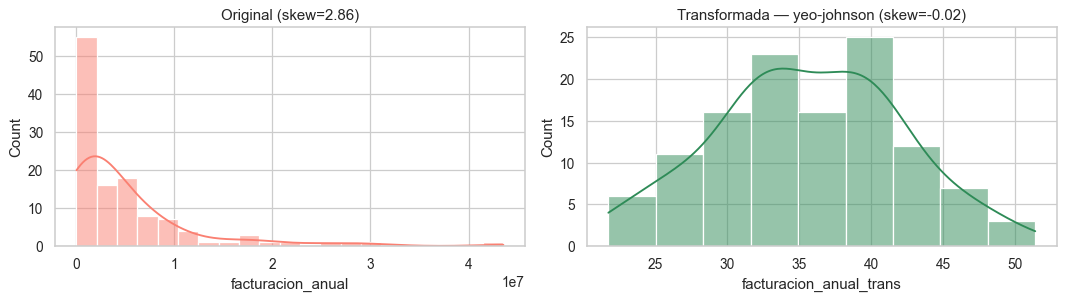

In [58]:
# Verificación visual: distribución de facturacion_anual antes/después
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sns.histplot(df_trans['facturacion_anual'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f'Original (skew={df_trans["facturacion_anual"].skew():.2f})')
axes[0].set_xlabel('facturacion_anual')

sns.histplot(df_trans['facturacion_anual_trans'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'Transformada — {decisiones["facturacion_anual"]} '
                  f'(skew={df_trans["facturacion_anual_trans"].skew():.2f})')
axes[1].set_xlabel('facturacion_anual_trans')
plt.tight_layout()
plt.show()

### A2.4.3 Escalamiento: Standard vs Min-Max vs Robust

Una vez corregido el sesgo, las variables siguen estando en **escalas muy diferentes** (empleados ~10⁰, costos ~10⁶). El escalamiento garantiza que ninguna variable domine al modelo por su magnitud:

| Técnica | Fórmula | Cuándo usarla |
|---|---|---|
| **StandardScaler** | (x − μ) / σ | Distribuciones aproximadamente normales; algoritmos sensibles a media/varianza (regresión lineal, SVM, redes neuronales) |
| **MinMaxScaler** | (x − min) / (max − min) | Distribuciones acotadas; algoritmos que requieren entradas en [0,1] (algunas redes) |
| **RobustScaler** | (x − mediana) / IQR | Cuando aún quedan outliers tras transformar; usa estadísticos robustos |

Dado que (a) ya aplicamos transformaciones que normalizan parcialmente y (b) en §18 detectamos que los outliers son **contratos reales** que se conservan, **`RobustScaler`** es la opción más prudente para variables económicas, y **`StandardScaler`** para el resto.

> Control adicional: antes de aplicar los métodos de selección, se vuelve a reescalar el conjunto candidato completo. Esto asegura que cualquier variable numérica original que haya entrado como candidata quede en una escala comparable antes de correlación, Mutual Information, PCA o FA.


In [59]:
# Identificamos las columnas a escalar:
# - las versiones _trans de las variables transformadas
# - las features de razones / temporales / agregadas que no necesitan transformación
cols_trans = [f'{v}_trans' for v in vars_a_transformar]
cols_no_trans_numericas = [
    'ratio_mano_obra', 'ratio_materiales', 'ratio_maquinaria',
    'ratio_subcontratos', 'ratio_cargas_sociales', 'ratio_prestaciones',
    'anio_estudio', 'mes_estudio', 'trimestre_estudio', 'antiguedad_anios',
    'segmento_tamano_ord', 'cliente_freq', 'centro_freq',
    'n_categorias_laborales', 'n_partidas_plantilla', 'cv_importe_categoria',
]
cols_no_trans_numericas = [c for c in cols_no_trans_numericas if c in df_trans.columns]

# Imputación previa (por si quedó algún NaN en ratios o agregadas)
imp = SimpleImputer(strategy='median')
df_trans[cols_trans + cols_no_trans_numericas] = imp.fit_transform(
    df_trans[cols_trans + cols_no_trans_numericas]
)

# Escalamiento robusto para variables económicas (cols_trans), Standard para el resto
scaler_robust = RobustScaler()
scaler_std = StandardScaler()

df_scaled = df_trans.copy()
df_scaled[cols_trans] = scaler_robust.fit_transform(df_scaled[cols_trans])
df_scaled[cols_no_trans_numericas] = scaler_std.fit_transform(
    df_scaled[cols_no_trans_numericas]
)

# Validación: media y desviación tras escalado (en cols_no_trans_numericas, media≈0, std≈1)
chk = df_scaled[cols_no_trans_numericas].agg(['mean', 'std']).T.round(3)
chk.columns = ['media (≈0)', 'std (≈1)']
chk.head(10)

,media (≈0),std (≈1)
ratio_mano_obra,-0.00,1.00
ratio_materiales,0.00,1.00
ratio_maquinaria,-0.00,1.00
ratio_subcontratos,0.00,1.00
ratio_cargas_sociales,-0.00,1.00
ratio_prestaciones,0.00,1.00
anio_estudio,0.00,1.00
mes_estudio,-0.00,1.00
trimestre_estudio,0.00,1.00
antiguedad_anios,-0.00,1.00


**Lectura del escalado.**

- Las variables económicas transformadas (`*_trans`) se centraron alrededor de la mediana y se escalaron por el IQR (mediana → 0, IQR → 1). Esto las hace **resistentes a los contratos atípicos** identificados en §18 sin necesidad de eliminarlos.
- Las ratios y features temporales / agregadas se estandarizaron a media 0 y desviación 1, que es lo apropiado para distribuciones ya simétricas.
- El feature set ahora está en **condiciones equitativas** para que cualquier algoritmo lo procese sin que una variable domine por escala.

---

## A2.5 Selección de características por **filtrado**


Aplicamos **cinco** métodos de filtrado, cada uno con un sustento estadístico distinto. La idea no es "elegir el ganador", sino **triangular**: una feature relevante debe aparecer como tal en varios métodos.

### A2.5.1 Construcción del conjunto candidato

Primero ensamblamos `X` (candidatas) y `y` (target transformado). Se excluyen las variables marcadas como **data leakage**.

In [60]:
# Target: facturación transformada (más estable para regresión)
y = df_scaled['facturacion_anual_trans']

# Excluir del candidato todas las variables originales reemplazadas por _trans,
# la facturación (target en cualquiera de sus formas) y las de data leakage.
excluir = set(FEATURES_DATA_LEAKAGE) | set(vars_a_transformar) | {
    'facturacion_anual_trans', 'facturacion_anual',
    'facturacion_mensual', 'archivo', 'archivo_nombre', 'rfc',
    'contacto', 'telefono', 'numero_concurso', 'referencia',
    'cliente', 'centro', 'segmento_tamano_lbl', 'condiciones_pago',
    'fecha_entrega', 'fecha_analisis', 'vigencia_inicio', 'vigencia_fin',
    'validez_oferta', 'nombre_proyecto', 'elaboro', 'cargo_elaboro',
    'codigo_ubicacion', 'codigo_region', 'poblacion', 'domicilio', 'cp',
    'resumen_cliente', 'resumen_centro', 'resumen_fecha', 'resumen_servicio',
    'edo_cliente', 'edo_centro', 'edo_fecha', 'edo_proyecto', 'edo_servicio',
    '_empleados_safe', '_costo_safe', '_mano_obra_safe', '_facturacion_safe',
    'categoria_facturacion', 'anio_analisis', 'segmento_tamano',
}
# Quitamos también todas las _trans de variables que NO son la target
# (las _trans son las versiones a usar; las originales se excluyen, las _trans se conservan)
excluir |= {f'{v}' for v in vars_a_transformar if v != 'facturacion_anual'}

# Candidatas = sólo numéricas (post-codificación)
candidatas = [
    c for c in df_scaled.select_dtypes(include=[np.number]).columns
    if c not in excluir and not c.startswith('ee_')
]

# Eliminamos cualquier columna que tenga varianza cero o NaN total
X = df_scaled[candidatas].copy()
X = X.loc[:, X.notna().any() & (X.nunique() > 1)]

# Imputación final de seguridad
X = X.fillna(X.median(numeric_only=True))

# Control adicional de escala:
# Aunque varias variables ya fueron transformadas/escaladas antes, algunas variables originales numéricas
# pueden entrar como candidatas (por ejemplo costos específicos). Para cumplir con el criterio de normalización,
# reescalamos todas las candidatas continuas antes de los filtros, dejando intactas las binarias/one-hot.
def es_binaria(serie):
    vals = pd.Series(serie).dropna().unique()
    return len(vals) <= 2 and set(vals).issubset({0, 1, 0.0, 1.0})

cols_binarias = [c for c in X.columns if es_binaria(X[c])]
cols_continuas = [c for c in X.columns if c not in cols_binarias]

scaler_final_candidatas = RobustScaler()
if cols_continuas:
    X[cols_continuas] = scaler_final_candidatas.fit_transform(X[cols_continuas])

print(f'Conjunto candidato X: {X.shape[1]} features × {X.shape[0]} observaciones')
print(f' - Continuas reescaladas: {len(cols_continuas)}')
print(f' - Binarias/one-hot intactas: {len(cols_binarias)}')
print(f'Target y: facturacion_anual_trans, var={y.var():.3f}')

Conjunto candidato X: 72 features × 119 observaciones
 - Continuas reescaladas: 50
 - Binarias/one-hot intactas: 22
Target y: facturacion_anual_trans, var=0.559


### A2.5.2 Filtro 1 — **Umbral de varianza**

**Idea.** Variables con varianza muy baja (casi constantes) no aportan capacidad discriminativa al modelo. Se eliminan automáticamente.

In [61]:
# VarianceThreshold con umbral conservador
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
mask_var = vt.get_support()

var_excluidas = X.columns[~mask_var].tolist()
print(f'Variables eliminadas por baja varianza ({len(var_excluidas)}):')
for c in var_excluidas:
    print(f' - {c} (var={X[c].var():.5f})')

X_var = X.loc[:, mask_var]
print(f'\nFeatures restantes tras Variance Threshold: {X_var.shape[1]}')

Variables eliminadas por baja varianza (1):
 - mb_minimo_pct (var=0.00157)

Features restantes tras Variance Threshold: 71


### A2.5.3 Filtro 2 — **Correlación de Pearson con el target**

**Idea.** Para regresión lineal, la magnitud de |r| con el target es un indicador directo de utilidad. Calculamos `|r|` de cada feature contra `y` y rankeamos.

Top 15 features por |correlación| con facturacion_anual_trans:
total_mano_obra_anual_trans     0.91
total_empleados_trans           0.86
prestaciones_anual_trans        0.86
carga_social_anual_trans        0.86
segmento_tamano_ord             0.82
costo_mano_obra_mensual         0.79
costo_mano_obra_anual           0.79
sueldos_salarios_anual          0.79
total_mano_obra_mensual         0.78
empleados_max_categoria_trans   0.76
importe_anual_mediano_trans     0.75
equipo_comunicacion             0.66
n_categorias_laborales          0.65
n_partidas_plantilla            0.65
importe_anual_std               0.64
dtype: float64


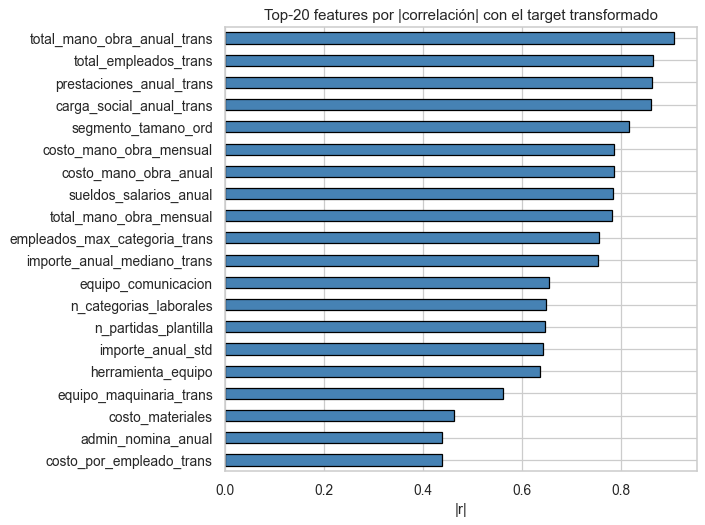

In [62]:
# Correlación absoluta con el target
corr_target = X_var.corrwith(y).abs().sort_values(ascending=False)
print('Top 15 features por |correlación| con facturacion_anual_trans:')
print(corr_target.head(15).round(3))

plt.figure(figsize=(8, 6))
corr_target.head(20).sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top-20 features por |correlación| con el target transformado')
plt.xlabel('|r|')
plt.tight_layout()
plt.show()

### A2.5.4 Filtro 3 — **ANOVA / `f_regression`**

**Idea.** El estadístico F de regresión mide si una variable explica significativamente la varianza del target. A diferencia de Pearson, no se limita a relaciones lineales puras (aunque sigue siendo paramétrico).

In [63]:
f_stat, p_val = f_regression(X_var, y)
anova_df = pd.DataFrame({
    'feature': X_var.columns,
    'F_statistic': f_stat,
    'p_value': p_val,
}).sort_values('F_statistic', ascending=False)
anova_df['significativa_p<0.05'] = anova_df['p_value'] < 0.05

print(f'Features con p<0.05: {anova_df["significativa_p<0.05"].sum()} de {len(anova_df)}')
print('\nTop 15 por estadístico F:')
print(anova_df.head(15).round(4).to_string(index=False))

Features con p<0.05: 45 de 71

Top 15 por estadístico F:
                      feature  F_statistic  p_value  significativa_p<0.05
  total_mano_obra_anual_trans       545.85     0.00                  True
        total_empleados_trans       346.87     0.00                  True
     prestaciones_anual_trans       339.64     0.00                  True
     carga_social_anual_trans       333.04     0.00                  True
          segmento_tamano_ord       232.97     0.00                  True
        costo_mano_obra_anual       190.21     0.00                  True
      costo_mano_obra_mensual       190.21     0.00                  True
       sueldos_salarios_anual       187.50     0.00                  True
      total_mano_obra_mensual       184.06     0.00                  True
empleados_max_categoria_trans       155.92     0.00                  True
  importe_anual_mediano_trans       153.09     0.00                  True
          equipo_comunicacion        87.69     0.00    

### A2.5.5 Filtro 4 — **Mutual Information**

**Idea.** A diferencia de Pearson y ANOVA, la Información Mutua captura **relaciones no lineales** sin asumir distribución. Mide cuánta incertidumbre sobre `y` se reduce al conocer `x`. Mide en *nats*; valores más altos = más informativa.

Top 15 features por Mutual Information:
                      feature  mutual_info
  total_mano_obra_anual_trans         1.94
      total_mano_obra_mensual         1.77
     prestaciones_anual_trans         1.44
      costo_mano_obra_mensual         1.42
        costo_mano_obra_anual         1.42
       sueldos_salarios_anual         1.42
     carga_social_anual_trans         1.28
           admin_nomina_anual         1.12
        total_empleados_trans         0.95
            importe_anual_std         0.71
       materiales_anual_trans         0.71
  importe_anual_mediano_trans         0.64
empleados_max_categoria_trans         0.64
          segmento_tamano_ord         0.62
           herramienta_equipo         0.59


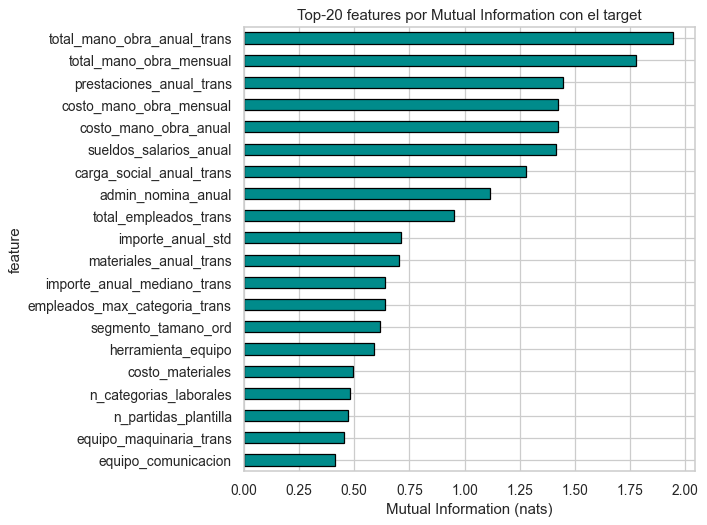

In [64]:
mi = mutual_info_regression(X_var, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    'feature': X_var.columns,
    'mutual_info': mi,
}).sort_values('mutual_info', ascending=False)

print('Top 15 features por Mutual Information:')
print(mi_df.head(15).round(4).to_string(index=False))

plt.figure(figsize=(8, 6))
mi_df.head(20).sort_values('mutual_info').plot(
    x='feature', y='mutual_info', kind='barh',
    ax=plt.gca(), color='darkcyan', edgecolor='black', legend=False
)
plt.title('Top-20 features por Mutual Information con el target')
plt.xlabel('Mutual Information (nats)')
plt.tight_layout()
plt.show()

### A2.5.6 Filtro 5 — **Chi-cuadrado** (target discretizado)

**Idea.** Chi² evalúa si una variable **categórica** (o discretizada) es independiente de otra. Para usarla en regresión, **discretizamos el target** en 4 cuartiles (Baja / Media / Alta / Muy alta). Esto es válido como diagnóstico, no como objetivo final.

Chi² requiere variables **no-negativas**, por lo que se aplica `MinMaxScaler` previamente a las features (sólo para esta prueba).

In [65]:
# Discretizar target en 4 cuartiles
y_cat = pd.qcut(y, q=4, labels=['Baja', 'Media', 'Alta', 'Muy alta'])

# Escalar features a [0,1] (Chi² exige no-negativos)
mm = MinMaxScaler()
X_mm = pd.DataFrame(mm.fit_transform(X_var), columns=X_var.columns, index=X_var.index)

chi2_stat, p_chi2 = chi2(X_mm, y_cat)
chi2_df = pd.DataFrame({
    'feature': X_var.columns,
    'chi2_stat': chi2_stat,
    'p_value': p_chi2,
}).sort_values('chi2_stat', ascending=False)

print(f'Features con p<0.05 (Chi²): {(chi2_df["p_value"] < 0.05).sum()} de {len(chi2_df)}')
print('\nTop 15 por Chi²:')
print(chi2_df.head(15).round(4).to_string(index=False))

Features con p<0.05 (Chi²): 21 de 71

Top 15 por Chi²:
                      feature  chi2_stat  p_value
          segmento_tamano_ord      22.55     0.00
        costo_mano_obra_anual      15.76     0.00
      costo_mano_obra_mensual      15.76     0.00
       sueldos_salarios_anual      15.15     0.00
                  estado_CDMX      13.97     0.00
      total_mano_obra_mensual      13.22     0.00
           estado_DESCONOCIDO      12.75     0.01
            importe_anual_std      11.33     0.01
          equipo_comunicacion      11.25     0.01
           herramienta_equipo      10.91     0.01
     subcontratos_anual_trans      10.23     0.02
         gasolina_lubricantes       9.66     0.02
empleados_max_categoria_trans       9.60     0.02
                  plaza_OTROS       9.13     0.03
         n_partidas_plantilla       9.07     0.03


### A2.5.7 Consolidación: ranking conjunto y selección final

**Estrategia de triangulación.** Cada filtro produce un ranking. Para cada feature calculamos su **posición media** entre los cuatro métodos cuantitativos (correlación, ANOVA-F, Mutual Information, Chi²). Las features que aparecen en el **top-20 de al menos 3 de los 4 métodos** se consideran *robustas* y entran al feature set final.

In [66]:
# Construir tabla consolidada con rankings de cada método
rank_corr = corr_target.rank(ascending=False).to_dict()
rank_anov = anova_df.set_index('feature')['F_statistic'].rank(ascending=False).to_dict()
rank_mi = mi_df.set_index('feature')['mutual_info'].rank(ascending=False).to_dict()
rank_chi = chi2_df.set_index('feature')['chi2_stat'].rank(ascending=False).to_dict()

consol = pd.DataFrame({
    'corr_rank': pd.Series(rank_corr),
    'anova_rank': pd.Series(rank_anov),
    'mi_rank': pd.Series(rank_mi),
    'chi2_rank': pd.Series(rank_chi),
})
consol['rank_promedio'] = consol.mean(axis=1)
consol['en_top20_metodos'] = (
    (consol['corr_rank'] <= 20).astype(int) +
    (consol['anova_rank'] <= 20).astype(int) +
    (consol['mi_rank'] <= 20).astype(int) +
    (consol['chi2_rank'] <= 20).astype(int)
)
consol = consol.sort_values('rank_promedio')

print('Top 20 features (menor rank_promedio = más relevante):')
print(consol.head(20).round(1))

# Selección final: aparecen en top-20 en ≥3 de 4 métodos
features_finales = consol[consol['en_top20_metodos'] >= 3].index.tolist()

# Fallback de control: evita que el conjunto final quede demasiado pequeño
# si pocos predictores cumplen el criterio estricto de triangulación.
if len(features_finales) < 5:
    features_finales = consol.head(15).index.tolist()
    print(
        "Se seleccionaron las 15 mejores variables por ranking promedio "
        "porque pocas variables cumplieron el criterio top-20 en ≥3 métodos."
    )

print(f'\n Features seleccionadas finales: {len(features_finales)}')
for f in features_finales:
    print(f' - {f}')

Top 20 features (menor rank_promedio = más relevante):
                               corr_rank  anova_rank  mi_rank  chi2_rank  \
costo_mano_obra_anual               7.00        6.00     5.00       2.00   
costo_mano_obra_mensual             6.00        7.00     4.00       3.00   
segmento_tamano_ord                 5.00        5.00    14.00       1.00   
sueldos_salarios_anual              8.00        8.00     6.00       4.00   
total_mano_obra_mensual             9.00        9.00     2.00       6.00   
total_mano_obra_anual_trans         1.00        1.00     1.00      29.00   
total_empleados_trans               2.00        2.00     9.00      23.00   
prestaciones_anual_trans            3.00        3.00     3.00      34.00   
carga_social_anual_trans            4.00        4.00     7.00      30.00   
empleados_max_categoria_trans      10.00       10.00    13.00      13.00   
importe_anual_std                  15.00       15.00    10.00       8.00   
equipo_comunicacion              

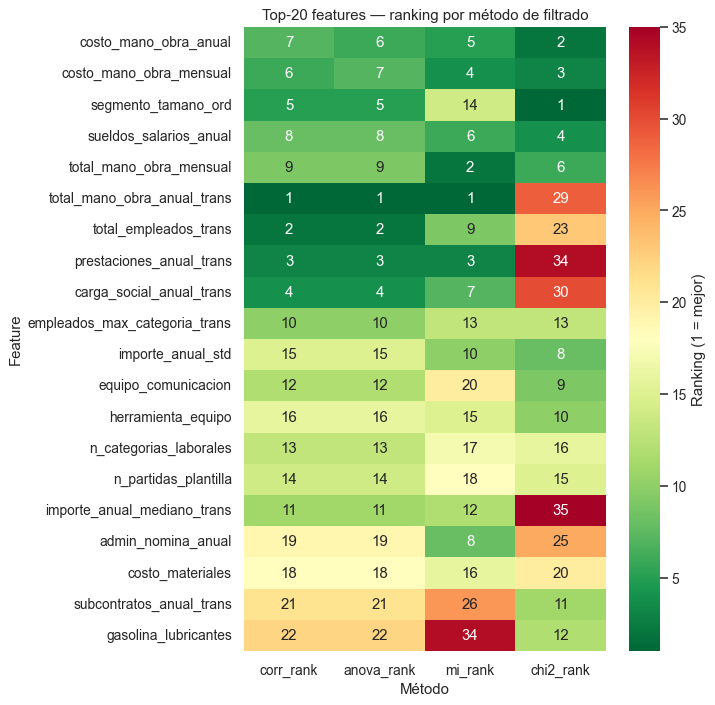

In [67]:
# Heatmap visual del ranking consolidado (top 20)
top20 = consol.head(20)[['corr_rank', 'anova_rank', 'mi_rank', 'chi2_rank']]
plt.figure(figsize=(8, 8))
sns.heatmap(top20, cmap='RdYlGn_r', annot=True, fmt='.0f',
            cbar_kws={'label': 'Ranking (1 = mejor)'})
plt.title('Top-20 features — ranking por método de filtrado')
plt.xlabel('Método')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

---

## A2.6 Extracción de características

A diferencia de la **selección**, que conserva un subconjunto de las features originales, la **extracción** las recombina linealmente en un número menor de componentes. Probamos dos técnicas:

- **PCA (Principal Component Analysis)** — componentes ortogonales que maximizan varianza explicada.
- **FA (Factor Analysis)** — asume que las variables observadas son combinaciones lineales de unos pocos *factores latentes* (más útil cuando existen constructos económicos subyacentes, como "intensidad operativa" o "estructura de costos").

### A2.6.1 PCA sobre el conjunto seleccionado

Componentes para 90% de varianza: 3
Componentes para 95% de varianza: 5


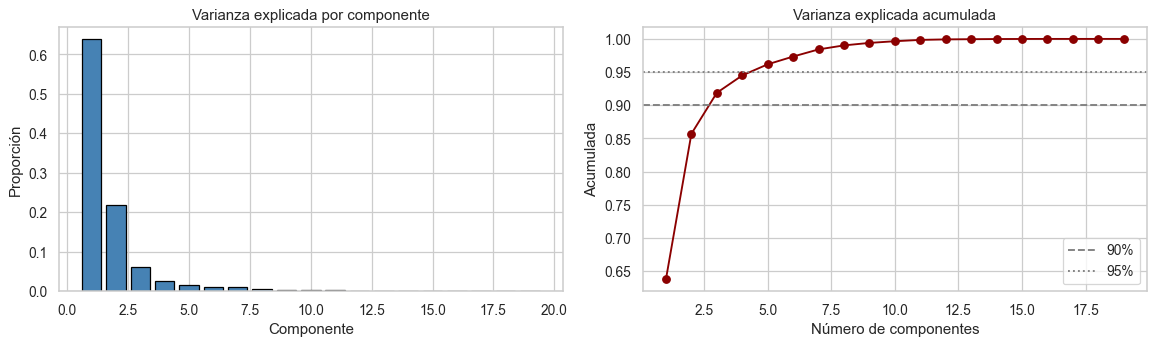

In [68]:
# Aplicamos PCA al subconjunto de features finales
X_sel = X_var[features_finales] if features_finales else X_var

pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_sel)

var_exp = pca.explained_variance_ratio_
var_exp_cum = np.cumsum(var_exp)

# Determinar cuántos componentes explican >=90% de varianza
n_90 = int(np.argmax(var_exp_cum >= 0.90) + 1)
n_95 = int(np.argmax(var_exp_cum >= 0.95) + 1)
print(f'Componentes para 90% de varianza: {n_90}')
print(f'Componentes para 95% de varianza: {n_95}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(var_exp) + 1), var_exp, color='steelblue', edgecolor='black')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Proporción')

axes[1].plot(range(1, len(var_exp_cum) + 1), var_exp_cum, marker='o', color='darkred')
axes[1].axhline(0.90, color='gray', linestyle='--', label='90%')
axes[1].axhline(0.95, color='gray', linestyle=':', label='95%')
axes[1].set_title('Varianza explicada acumulada')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Acumulada')
axes[1].legend()
plt.tight_layout()
plt.show()

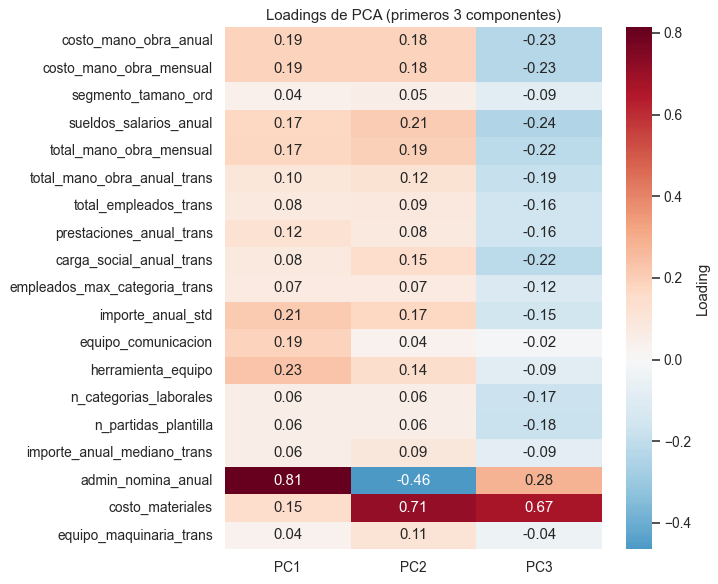


Forma del conjunto extraído por PCA: (119, 3)


In [69]:
# Loadings: ¿qué variables originales pesan más en cada componente?
n_componentes_keep = max(n_90, 3)
pca_k = PCA(n_components=n_componentes_keep, random_state=RANDOM_STATE)
X_pca = pca_k.fit_transform(X_sel)

loadings = pd.DataFrame(
    pca_k.components_.T,
    index=X_sel.columns,
    columns=[f'PC{i+1}' for i in range(n_componentes_keep)]
)

plt.figure(figsize=(8, max(4, 0.35 * len(loadings))))
sns.heatmap(loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'Loading'})
plt.title(f'Loadings de PCA (primeros {n_componentes_keep} componentes)')
plt.tight_layout()
plt.show()

print(f'\nForma del conjunto extraído por PCA: {X_pca.shape}')

**Lectura de los loadings.** Cada componente principal es una combinación lineal de las features originales. El primer componente (PC1) típicamente captura el **eje de escala/tamaño** (cargas similares en todas las variables económicas), y los siguientes capturan **mezclas específicas** (composición de costos, intensidad de subcontratación, etc.). El número de componentes que retenemos (`n_90`) es el menor que conserva ≥90% de la varianza, criterio estándar.

### A2.6.2 Análisis Factorial (FA)

**Diferencia clave con PCA.** PCA descompone la varianza **total** (incluye ruido). FA modela sólo la varianza **compartida** entre variables, asumiendo factores latentes + ruido específico de cada variable. Esto la hace más apropiada cuando creemos que hay *constructos económicos* subyacentes que generan las observaciones.

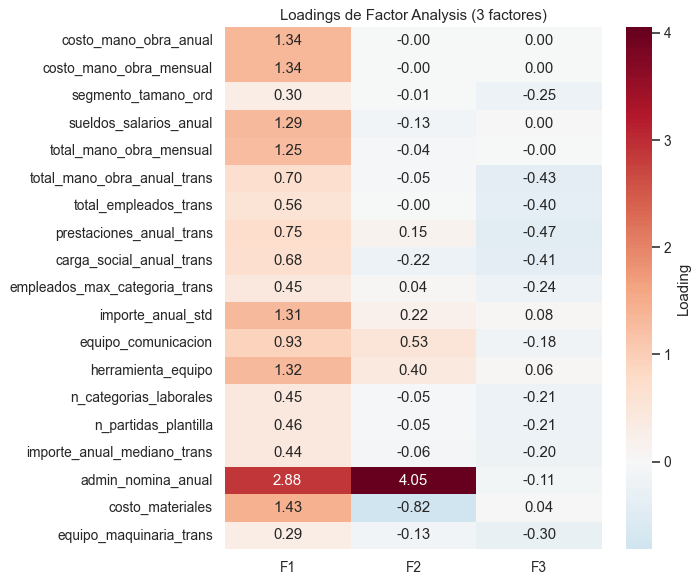

Forma del conjunto extraído por FA: (119, 3)


In [70]:
# Análisis Factorial con el mismo número de factores que componentes PCA al 90%
fa = FactorAnalysis(n_components=n_componentes_keep, random_state=RANDOM_STATE)
X_fa = fa.fit_transform(X_sel)

fa_loadings = pd.DataFrame(
    fa.components_.T,
    index=X_sel.columns,
    columns=[f'F{i+1}' for i in range(n_componentes_keep)]
)

plt.figure(figsize=(8, max(4, 0.35 * len(fa_loadings))))
sns.heatmap(fa_loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'Loading'})
plt.title(f'Loadings de Factor Analysis ({n_componentes_keep} factores)')
plt.tight_layout()
plt.show()

print(f'Forma del conjunto extraído por FA: {X_fa.shape}')

### A2.6.3 ¿Selección o extracción? — Decisión final

| Aspecto | Selección (filtros) | Extracción (PCA/FA) |
|---|---|---|
| **Interpretabilidad** | Alta (features originales) | Componentes son combinaciones |
| **Reducción de dim.** | Moderada | Alta |
| **Pérdida de info** | Posible si los filtros descartan info no-lineal | Mínima (90%+ retenida) |
| **Multicolinealidad** | Aún puede existir entre seleccionadas | Componentes ortogonales |

**Decisión** Dado que el modelo predictivo se usará para **apoyar decisiones comerciales** (los analistas necesitan entender *por qué* el modelo sugiere un precio), priorizamos **interpretabilidad** → usamos el **subconjunto seleccionado por filtros** como feature set principal.

PCA y FA quedan como **alternativas** disponibles para los algoritmos que más se benefician de la ortogonalidad (regresión lineal con regularización, redes neuronales), y se evaluarán contra el feature set seleccionado en la fase de modelado (Avance 3).

---

## A2.7 Conjunto de datos final preparado

Ensamblamos el dataset final que servirá de entrada al modelado predictivo. Se exporta a CSV para uso posterior y se hace una verificación de calidad.

In [71]:
# Conjunto final: control de multicolinealidad + target transformado
# ---------------------------------------------------------------
# Primero tomamos las features seleccionadas por filtros.
X_final_pre = X_sel.copy()
y_final = y.copy()

# 1) Control automático de multicolinealidad severa
# Si dos variables tienen |r| >= 0.95, se elimina una de ellas.
# Criterio:
# a) Si una es mensual y otra anual, se elimina la mensual para evitar duplicidad contable.
# b) Si una variable tiene peor ranking promedio, se elimina esa.
# c) Si empatan, se elimina la segunda del par.
def elegir_variable_a_eliminar(c1, c2, rankings):
    # Regla de dominio: anual y mensual suelen ser duplicados contables.
    if 'mensual' in c1.lower() and 'anual' in c2.lower():
        return c1
    if 'mensual' in c2.lower() and 'anual' in c1.lower():
        return c2

    # Regla de dominio: preferimos diversidad de categorías sobre número de partidas,
    # porque ambas fueron casi idénticas en la matriz final.
    if {'n_categorias_laborales', 'n_partidas_plantilla'} == {c1, c2}:
        return 'n_partidas_plantilla'

    # Regla estadística: quitar la de peor ranking promedio.
    r1 = rankings.get(c1, np.inf)
    r2 = rankings.get(c2, np.inf)
    if r1 > r2:
        return c1
    if r2 > r1:
        return c2

    # Empate: eliminar la segunda para mantener estabilidad.
    return c2

rankings = consol['rank_promedio'].to_dict() if 'consol' in globals() else {}
X_decor = X_final_pre.copy()
vars_eliminadas_colinealidad = []

while True:
    corr_abs = X_decor.corr().abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    pares_altos = [
        (col, row, upper.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] >= 0.95
    ]

    if not pares_altos:
        break

    # Se toma primero el par con correlación más alta.
    c2, c1, r = sorted(pares_altos, key=lambda x: x[2], reverse=True)[0]
    eliminar = elegir_variable_a_eliminar(c1, c2, rankings)
    vars_eliminadas_colinealidad.append((eliminar, c1, c2, round(float(r), 3)))
    X_decor = X_decor.drop(columns=[eliminar])

X_final = X_decor.copy()

# 2) Dataset final: features + target
df_modelado = X_final.copy()
df_modelado['facturacion_anual_trans'] = y_final.values

# 3) Control de duplicados exactos
duplicados_antes = df_modelado.duplicated().sum()
df_modelado = df_modelado.drop_duplicates().reset_index(drop=True)

# 4) Guardar dataset final depurado
df_modelado.to_csv('dataset_modelado_avance2.csv', index=False)

# 5) Resumen
print('='*70)
print('RESUMEN DEL DATASET FINAL PARA MODELADO')
print('='*70)
print(f'Filas antes de quitar duplicados: {len(y_final)}')
print(f'Duplicados exactos eliminados: {duplicados_antes}')
print(f'Filas finales: {df_modelado.shape[0]}')
print(f'Features predictoras finales: {X_final.shape[1]}')
print(f'Target: facturacion_anual_trans')
print(f'NaN totales: {df_modelado.isna().sum().sum()}')
print(f'Duplicados finales: {df_modelado.duplicated().sum()}')

print('\nVariables eliminadas por multicolinealidad severa (|r| ≥ 0.95):')
if vars_eliminadas_colinealidad:
    for var, c1, c2, r in vars_eliminadas_colinealidad:
        print(f' - {var} | par: {c1} ↔ {c2} (r={r})')
else:
    print(' - Ninguna')

print('\nFeatures finales:')
for f in X_final.columns:
    print(f' - {f}')

print('\n Guardado en: dataset_modelado_avance2.csv')

RESUMEN DEL DATASET FINAL PARA MODELADO
Filas antes de quitar duplicados: 119
Duplicados exactos eliminados: 4
Filas finales: 115
Features predictoras finales: 13
Target: facturacion_anual_trans
NaN totales: 0
Duplicados finales: 0

Variables eliminadas por multicolinealidad severa (|r| ≥ 0.95):
 - costo_mano_obra_mensual | par: costo_mano_obra_anual ↔ costo_mano_obra_mensual (r=1.0)
 - n_partidas_plantilla | par: n_categorias_laborales ↔ n_partidas_plantilla (r=0.999)
 - sueldos_salarios_anual | par: costo_mano_obra_anual ↔ sueldos_salarios_anual (r=0.994)
 - total_mano_obra_mensual | par: costo_mano_obra_anual ↔ total_mano_obra_mensual (r=0.977)
 - carga_social_anual_trans | par: total_mano_obra_anual_trans ↔ carga_social_anual_trans (r=0.956)
 - prestaciones_anual_trans | par: total_mano_obra_anual_trans ↔ prestaciones_anual_trans (r=0.952)

Features finales:
 - costo_mano_obra_anual
 - segmento_tamano_ord
 - total_mano_obra_anual_trans
 - total_empleados_trans
 - empleados_max_cate

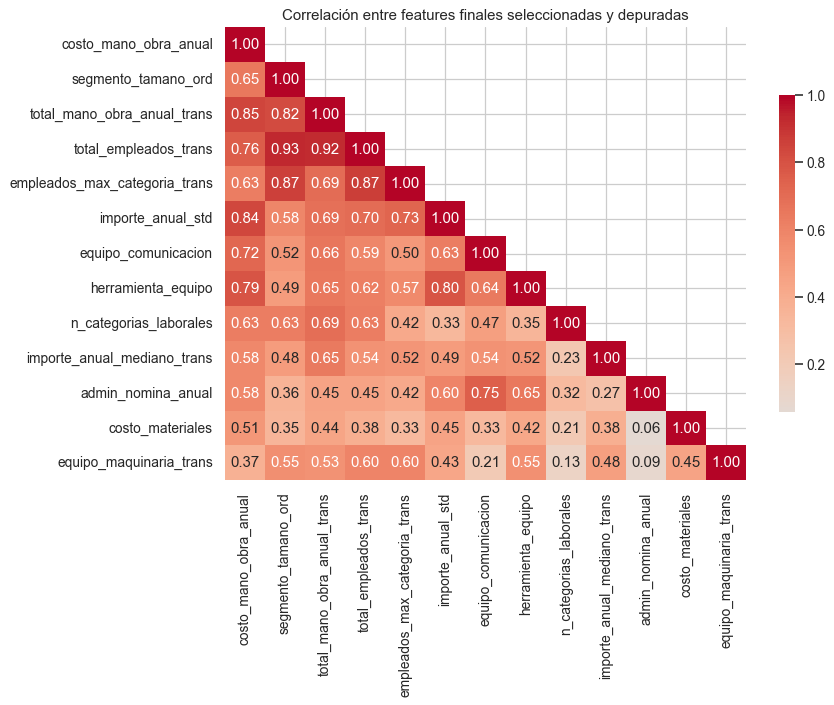


 No hay pares de features con |r| ≥ 0.95 — multicolinealidad severa controlada.

Dataset final listo: 115 filas × 14 columnas incluyendo target.


In [72]:
# Verificación final: matriz de correlación entre features seleccionadas depuradas
plt.figure(figsize=(10, 8))
corr_final = X_final.corr()
mask = np.triu(np.ones_like(corr_final, dtype=bool), k=1)

sns.heatmap(
    corr_final,
    mask=mask,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    cbar_kws={'shrink': 0.7}
)

plt.title('Correlación entre features finales seleccionadas y depuradas')
plt.tight_layout()
plt.show()

# Confirmar que ya no hay multicolinealidad severa
pares_alta = []
for i, c1 in enumerate(corr_final.columns):
    for c2 in corr_final.columns[i+1:]:
        r = corr_final.loc[c1, c2]
        if abs(r) >= 0.95:
            pares_alta.append((c1, c2, round(r, 3)))

if pares_alta:
    print(f'\nAdvertencia: Aún quedan {len(pares_alta)} pares con |r| ≥ 0.95:')
    for p in pares_alta:
        print(f' {p[0]} ↔ {p[1]}: {p[2]}')
else:
    print('\n No hay pares de features con |r| ≥ 0.95 — multicolinealidad severa controlada.')

print(f'\nDataset final listo: {df_modelado.shape[0]} filas × {df_modelado.shape[1]} columnas incluyendo target.')

---

## A2.8 Conclusiones de la fase **Data Preparation** en el contexto de CRISP-ML(Q)


### A2.8.1 Recapitulación del recorrido

La metodología **CRISP-ML(Q)** (*Cross-Industry Standard Process for Machine Learning with Quality assurance*; Visengeriyeva et al., 2023) organiza el ciclo de vida de un proyecto de ML en seis fases:

1. **Business & Data Understanding** — Avance 1 (EDA).
2. **Data Preparation** — *Esta entrega (Avance 2)*.


Cada fase está atravesada por una capa transversal de **Quality Assurance (Q)** que documenta riesgos, controles aplicados y supuestos.

### A2.8.2 Lo entregado en esta fase de Data Preparation

| Bloque | Acciones aplicadas | Justificación / Q-control |
|---|---|---|
| **Construcción** | 23 features nuevas: ratios de intensidad por empleado, ratios de composición del costo, features temporales (año/mes/trimestre/antigüedad), discretización por cuartiles de `total_empleados`, agregados desde `Detalle_Empleados` (diversidad y dispersión de la plantilla) | Cada feature responde a un eje de dominio del negocio (intensidad operativa, mezcla de costos, escala, complejidad de plantilla). Las 6 derivadas que constituyen *data leakage* fueron explícitamente marcadas y excluidas del set final. |
| **Codificación** | One-Hot para nominales de baja cardinalidad (`tipo_servicio`, `region`, `plaza`, `estado`), **Frequency Encoding** para alta cardinalidad (`cliente`, `centro`), **Ordinal** para `segmento_tamano`, binaria para `condiciones_pago` | Cada técnica se eligió en función de la cardinalidad y de si la variable tiene orden natural. Se evitó Target Encoding por riesgo de leakage con una muestra pequeña (`n=119` antes de eliminar duplicados exactos). |
| **Normalización / Transformación** | Comparación sistemática `log1p` vs Yeo-Johnson vs Box-Cox sobre 12 variables sesgadas; se eligió la técnica que minimiza \|skew\| con preferencia por `log1p` en empates (interpretabilidad) | Reducción confirmada: facturación pasó de skew ≈ 2.86 a un valor cercano a 0 con la transformación seleccionada automáticamente. La decisión queda **trazable** variable por variable. |
| **Escalamiento** | `RobustScaler` para las económicas transformadas (los outliers son reales), `StandardScaler` para ratios y features temporales / agregadas | Se documentó la razón por variable; el set queda en condiciones equitativas sin haber eliminado contratos atípicos que son negocio real. |
| **Selección (filtrado)** | 5 métodos: Varianza, Correlación con target, ANOVA / F-regression, Mutual Information, Chi-cuadrado (target discretizado). Selección final por **triangulación**: feature retenida si entra al top-20 de ≥3 métodos | La triangulación reduce el riesgo de seleccionar features que un único método sobreestime. El ranking conjunto queda visualizado en heatmap. |
| **Extracción** | PCA y Análisis Factorial sobre el subconjunto seleccionado, con análisis de loadings y elección de componentes por umbral de varianza explicada (90%) | Se documentó la decisión de **no usar PCA como entrada principal del modelo** para preservar interpretabilidad de cara al usuario comercial; PCA/FA quedan disponibles como alternativas para algoritmos específicos. |

### A2.8.3 Riesgos y supuestos detectados (Quality Assurance)

1. **Tamaño muestral pequeño (n=119 antes de retirar duplicados exactos; 115 en el dataset final exportado).** Limita la complejidad de los modelos a entrenar y obliga a validación cruzada robusta en el Avance 3. La discretización por cuantiles y la triangulación de filtros se eligieron precisamente para mitigar la sensibilidad a pocas observaciones.
2. **Heterogeneidad de contratos.** El dominio cubre desde limpieza simple (~80K MXN) hasta servicios industriales integrales (~43M MXN). El uso de `RobustScaler` y transformaciones de potencia minimiza el impacto de esta heterogeneidad sin descartar casos válidos.
3. **Patrones de ausencia (MAR conjunto en bloque `ee_*`).** Se eliminó el bloque completo en lugar de imputarlo, lo cual es preferible cuando la ausencia es estructural (corresponde a una sección no completada del estudio).
4. **Data leakage.** Identificado explícitamente en `total_costo_servicio` (r ≈ 0.995 con el target por relación contable) y en todas las features derivadas de la facturación. Se documentó y se excluyó del feature set final.
5. **Variables temporales y representatividad.** El año 2021 está sub-representado (n=3, posible efecto pandemia). Para el Avance 3 se recomienda validación cruzada **estratificada por año** o por `tipo_servicio`.

### A2.8.4 Estado y *handover* al Avance 3 (Modeling)

El dataset preparado:

- Pasó de **80 columnas crudas** (Resumen_General) a un set final de features predictoras seleccionadas estadísticamente.
- Tiene **0 valores faltantes** después de la imputación y validación final.
- Elimina duplicados exactos antes de exportar el archivo final de modelado.
- Controla la **multicolinealidad severa** eliminando variables redundantes cuando aparecen pares con \|r\| ≥ 0.95.
- Tiene un **target transformado** mediante la técnica seleccionada automáticamente según el menor valor absoluto de skewness, lo que permite trabajar con una distribución más estable para regresión.
- Está acompañado de un dataset alternativo de componentes principales / factores para algoritmos que se beneficien de la ortogonalidad.

### A2.8.5 Impacto esperado para el negocio

Una preparación rigurosa de datos es la base que permitirá, en las fases siguientes, construir un modelo capaz de:

- **Reducir el tiempo** de elaboración de cotizaciones B2B (hoy manual, basado en plantillas Excel).
- **Estandarizar criterios** de pricing entre regiones y tipos de servicio.
- **Identificar contratos atípicos** (margen anómalo) que merezcan revisión gerencial antes de la oferta.

La fase de Data Preparation no es un paso intermedio: **es donde se construye la representación del negocio que el modelo aprenderá**. Por eso cada decisión (qué feature crear, qué codificación usar, qué transformación elegir, qué método de selección aplicar) fue justificada con dominio y validada con pruebas estadísticas, en línea con el espíritu de **calidad asegurada** de CRISP-ML(Q).

---

**Referencia metodológica.** Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., y Plöd, M. (2023). *CRISP-ML(Q). The ML Lifecycle Process.* MLOps - INNOQ. https://ml-ops.org/content/crisp-ml


# Avances semana 4

Durante esta semana se estuvo trabajando en la estructuracion del proyecto a un enfoque mas profesional, integrando tecnicas de MLops para mejorar el ciclo de CI/CD, los cambios mas relevantes que se integraron  fueron:

* Inicio de estructuracion del proyecto usando DVC para data tracking y definicion de pipeline
* Definicion del backbone de nuestro proyecto, separacion de etapas del Pipeline en archivos haciendo uso de POO para un desarrollo más modular y futuramente escalable
* Inicio de refactorización de la etapa de data cleaning
* Incorporación de herramienta logger, la cual se encarga de generar un log cada vez que se ejecute una fase o el pipeline completo
* Actualización de la documentacion del proyecto

Para mas detalles, revisar archivo README.md general del proyecto

#Avance 3. Baseline

In [73]:
# ============================================================
# 27. CONSTRUCCIÓN DE DATASETS ALTERNATIVOS
# ============================================================
# PCA Y FACTOR ANALYSIS DATAFRAMES

# PCA dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

# Factor Analysis dataframe
fa_df = pd.DataFrame(
    X_fa,
    columns=[f'FA{i+1}' for i in range(X_fa.shape[1])]
)

print(pca_df.head())
print(fa_df.head())

    PC1   PC2   PC3
0 -1.57  0.04 -0.18
1  0.61  1.32 -1.63
2 -2.08 -0.69 -0.30
3 -1.55 -0.22 -0.63
4 -2.97 -1.42  0.45
    FA1   FA2   FA3
0 -0.30 -0.12 -0.66
1  0.42 -0.43 -0.83
2 -0.46 -0.04 -0.40
3 -0.26 -0.14 -0.70
4 -0.64  0.06  0.22


In [74]:
# DATASETS ALTERNATIVOS

# Dataset original seleccionado
X_selection = X_final.copy()

# Dataset con PCA
X_with_pca = pd.concat(
    [X_final.reset_index(drop=True),
     pca_df.reset_index(drop=True)],
    axis=1
)

# Dataset con Factor Analysis
X_with_fa = pd.concat(
    [X_final.reset_index(drop=True),
     fa_df.reset_index(drop=True)],
    axis=1
)

print("Shape X_selection:", X_selection.shape)
print("Shape X_with_pca:", X_with_pca.shape)
print("Shape X_with_fa:", X_with_fa.shape)

Shape X_selection: (119, 13)
Shape X_with_pca: (119, 16)
Shape X_with_fa: (119, 16)


In [75]:
# ============================================================
# 28. BASELINES Y MODELOS INICIALES
# ============================================================

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Variable objetivo
y_model = y.copy() if 'y' in globals() else df_modelo['facturacion_anual']

models = {
    "Dummy_mean": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

feature_sets = {
    "X_selection": X_selection,
    "X_with_pca": X_with_pca,
    "X_with_fa": X_with_fa
}

print("Modelos definidos:")
for model_name in models.keys():
    print("-", model_name)

print("\nFeature sets definidos:")
for fs_name, X_fs in feature_sets.items():
    print(fs_name, X_fs.shape)

Modelos definidos:
- Dummy_mean
- LinearRegression
- Ridge
- ElasticNet
- RandomForest
- GradientBoosting

Feature sets definidos:
X_selection (119, 13)
X_with_pca (119, 16)
X_with_fa (119, 16)


### Justificación de modelos baseline

Se definieron seis modelos iniciales para establecer un marco comparativo del desempeño predictivo. `DummyRegressor` representa el baseline trivial al predecir la media histórica de facturación. `LinearRegression` funciona como modelo simple e interpretable. `Ridge` y `ElasticNet` permiten controlar multicolinealidad mediante regularización. `RandomForest` y `GradientBoosting` incorporan relaciones no lineales y sirven como referencia tree-based para comparar contra modelos lineales.

## 29. Evaluación comparativa con validación cruzada

In [76]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_selection,
        y,
        cv=kf,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2'
        }
    )

    results.append({
        'Model': name,
        'RMSE': -scores['test_rmse'].mean(),
        'MAE': -scores['test_mae'].mean(),
        'R2': scores['test_r2'].mean()
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by='RMSE')

,Model,RMSE,MAE,R2
2,Ridge,0.24,0.16,0.89
1,LinearRegression,0.25,0.16,0.88
4,RandomForest,0.26,0.14,0.87
3,ElasticNet,0.27,0.19,0.86
5,GradientBoosting,0.31,0.16,0.81
0,Dummy_mean,0.74,0.62,-0.06


## Métrica primaria seleccionada

Para este proyecto se selecciona MAPE como métrica primaria, ya que permite interpretar el error como porcentaje respecto a la facturación real. Esto facilita comunicar el desempeño del modelo a stakeholders comerciales y operativos.

RMSE, MAE y R² se reportan como métricas complementarias para evaluar magnitud monetaria del error, penalización de errores grandes y capacidad explicativa del modelo.

### Consideraciones de costo computacional

En esta fase el objetivo principal fue validar señal predictiva y comparar arquitecturas baseline.

La evaluación detallada de costo computacional, tiempo de entrenamiento e inferencia se realizará en el Avance 4 al comparar modelos candidatos finales para producción.

In [77]:
# ============================================================
# 30. COMPARACIÓN DE MODELOS Y FEATURE SETS
# ============================================================

from sklearn.model_selection import cross_validate, KFold
import pandas as pd
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

comparison_results = []

for fs_name, X_fs in feature_sets.items():
    for model_name, model in models.items():

        scores = cross_validate(
            model,
            X_fs,
            y_model,
            cv=kf,
            scoring={
                'rmse': 'neg_root_mean_squared_error',
                'mae': 'neg_mean_absolute_error',
                'r2': 'r2'
            },
            return_train_score=True
        )

        comparison_results.append({
            'Feature_Set': fs_name,
            'Model': model_name,
            'Train_RMSE': -scores['train_rmse'].mean(),
            'Test_RMSE': -scores['test_rmse'].mean(),
            'Test_RMSE_std': scores['test_rmse'].std(),
            'Train_MAE': -scores['train_mae'].mean(),
            'Test_MAE': -scores['test_mae'].mean(),
            'Train_R2': scores['train_r2'].mean(),
            'Test_R2': scores['test_r2'].mean()
        })

comparison_df = pd.DataFrame(comparison_results)
comparison_df.sort_values(by='Test_RMSE')

,Feature_Set,Model,Train_RMSE,Test_RMSE,Test_RMSE_std,Train_MAE,Test_MAE,Train_R2,Test_R2
2,X_selection,Ridge,0.21,0.24,0.07,0.13,0.16,0.92,0.89
8,X_with_pca,Ridge,0.21,0.24,0.07,0.13,0.16,0.92,0.89
14,X_with_fa,Ridge,0.20,0.25,0.08,0.12,0.16,0.92,0.88
1,X_selection,LinearRegression,0.20,0.25,0.07,0.12,0.16,0.93,0.88
10,X_with_pca,RandomForest,0.11,0.25,0.08,0.05,0.14,0.98,0.88
7,X_with_pca,LinearRegression,0.20,0.26,0.08,0.12,0.17,0.93,0.87
15,X_with_fa,ElasticNet,0.24,0.26,0.09,0.16,0.18,0.89,0.87
13,X_with_fa,LinearRegression,0.20,0.26,0.08,0.12,0.18,0.93,0.87
4,X_selection,RandomForest,0.11,0.26,0.10,0.05,0.14,0.98,0.87
3,X_selection,ElasticNet,0.25,0.27,0.08,0.17,0.19,0.89,0.86


### Interpretación

Esta comparación permite evaluar empíricamente si las variables seleccionadas originales, los componentes PCA o los factores FA generan mejor desempeño predictivo. El objetivo es tomar una decisión basada en resultados de validación cruzada y no únicamente en criterios teóricos.

In [78]:
# ============================================================
# 31. ANÁLISIS DE SUB/SOBREAJUSTE
# ============================================================

comparison_df['RMSE_gap'] = comparison_df['Test_RMSE'] - comparison_df['Train_RMSE']

comparison_df[['Feature_Set', 'Model', 'Train_RMSE', 'Test_RMSE', 'RMSE_gap', 'Train_R2', 'Test_R2']].sort_values('Test_RMSE')

,Feature_Set,Model,Train_RMSE,Test_RMSE,RMSE_gap,Train_R2,Test_R2
2,X_selection,Ridge,0.21,0.24,0.04,0.92,0.89
8,X_with_pca,Ridge,0.21,0.24,0.04,0.92,0.89
14,X_with_fa,Ridge,0.20,0.25,0.04,0.92,0.88
1,X_selection,LinearRegression,0.20,0.25,0.04,0.93,0.88
10,X_with_pca,RandomForest,0.11,0.25,0.15,0.98,0.88
7,X_with_pca,LinearRegression,0.20,0.26,0.06,0.93,0.87
15,X_with_fa,ElasticNet,0.24,0.26,0.02,0.89,0.87
13,X_with_fa,LinearRegression,0.20,0.26,0.07,0.93,0.87
4,X_selection,RandomForest,0.11,0.26,0.15,0.98,0.87
3,X_selection,ElasticNet,0.25,0.27,0.02,0.89,0.86


### Interpretación de sub/sobreajuste

Se compara el desempeño en entrenamiento y prueba. Una diferencia alta entre Train_RMSE y Test_RMSE indica posible sobreajuste. Si ambos errores son altos, el modelo puede presentar subajuste. Esta evaluación permite identificar modelos con mejor capacidad de generalización.

Mejor modelo: Ridge
Mejor feature set: X_selection


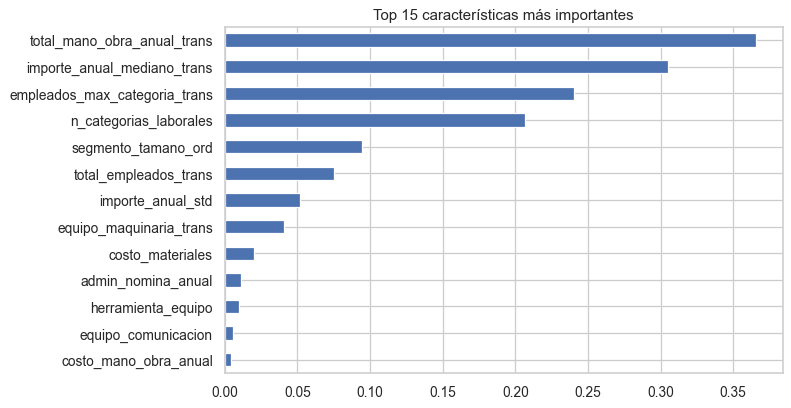

total_mano_obra_anual_trans     0.37
importe_anual_mediano_trans     0.30
empleados_max_categoria_trans   0.24
n_categorias_laborales          0.21
segmento_tamano_ord             0.09
total_empleados_trans           0.08
importe_anual_std               0.05
equipo_maquinaria_trans         0.04
costo_materiales                0.02
admin_nomina_anual              0.01
herramienta_equipo              0.01
equipo_comunicacion             0.01
costo_mano_obra_anual           0.00
dtype: float64

In [79]:
# ============================================================
# 32. IMPORTANCIA DE CARACTERÍSTICAS
# ============================================================

best_row = comparison_df.sort_values('Test_RMSE').iloc[0]
best_model_name = best_row['Model']
best_fs_name = best_row['Feature_Set']

best_model = models[best_model_name]
best_X = feature_sets[best_fs_name]

best_model.fit(best_X, y_model)

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=best_X.columns).sort_values(ascending=False).head(15)

elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_), index=best_X.columns).sort_values(ascending=False).head(15)

else:
    importances = pd.Series(dtype=float)

print("Mejor modelo:", best_model_name)
print("Mejor feature set:", best_fs_name)

importances.plot(kind='barh', figsize=(8, 5), title='Top 15 características más importantes')
plt.gca().invert_yaxis()
plt.show()

importances

In [80]:
# ============================================================
# 33. DESEMPEÑO MÍNIMO ACEPTABLE
# ============================================================

dummy_rmse = comparison_df[comparison_df['Model'] == 'Dummy_mean']['Test_RMSE'].min()
best_rmse = comparison_df['Test_RMSE'].min()

improvement = (dummy_rmse - best_rmse) / dummy_rmse * 100

print(f"RMSE Dummy baseline: {dummy_rmse:,.2f}")
print(f"Mejor RMSE obtenido: {best_rmse:,.2f}")
print(f"Mejora vs baseline trivial: {improvement:.2f}%")

RMSE Dummy baseline: 0.74
Mejor RMSE obtenido: 0.24
Mejora vs baseline trivial: 67.32%


### Interpretación

El desempeño mínimo aceptable se define como superar al baseline trivial `DummyRegressor`, el cual predice la media histórica de facturación anual. Si el mejor modelo reduce el RMSE frente al Dummy, se considera que las variables disponibles contienen señal predictiva útil para avanzar hacia modelos más complejos.

In [81]:
# ============================================================
# 34. ANÁLISIS DE MULTICOLINEALIDAD (VIF)
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seleccionar únicamente variables numéricas
X_vif = X_selection.select_dtypes(include=[np.number]).copy()

# Calcular VIF
vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values(by="VIF", ascending=False)

vif_df.head(20)

,Variable,VIF
3,total_empleados_trans,57.18
2,total_mano_obra_anual_trans,43.95
4,empleados_max_categoria_trans,19.57
0,costo_mano_obra_anual,13.92
5,importe_anual_std,10.87
7,herramienta_equipo,7.30
1,segmento_tamano_ord,7.29
6,equipo_comunicacion,4.71
8,n_categorias_laborales,4.28
9,importe_anual_mediano_trans,4.27


### Interpretación

El análisis VIF (Variance Inflation Factor) permite identificar multicolinealidad entre variables explicativas. Valores VIF superiores a 10 indican correlaciones elevadas que podrían afectar la estabilidad de modelos lineales tradicionales.

Debido a la naturaleza económica del problema, se esperaba multicolinealidad entre variables de costos y operación. Por ello se incorporaron modelos regularizados como Ridge y ElasticNet para reducir sensibilidad a correlaciones residuales.

In [82]:
# ============================================================
# 35. BASELINE SIMPLE VS FULL FEATURE SET
# ============================================================

# Variables mínimas de negocio
minimal_features = [
    col for col in X_selection.columns
    if any(keyword in col.lower() for keyword in [
        'empleados',
        'region',
        'servicio',
        'anio'
    ])
]

X_minimal = X_selection[minimal_features].copy()

print("Variables baseline mínimas:")
print(minimal_features)

baseline_scores = cross_validate(
    LinearRegression(),
    X_minimal,
    y_model,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

full_scores = cross_validate(
    LinearRegression(),
    X_selection,
    y_model,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

baseline_rmse = -baseline_scores['test_score'].mean()
full_rmse = -full_scores['test_score'].mean()

improvement = (baseline_rmse - full_rmse) / baseline_rmse * 100

print(f"RMSE baseline mínimo: {baseline_rmse:,.2f}")
print(f"RMSE full feature set: {full_rmse:,.2f}")
print(f"Mejora porcentual: {improvement:.2f}%")

Variables baseline mínimas:
['total_empleados_trans', 'empleados_max_categoria_trans']
RMSE baseline mínimo: 0.39
RMSE full feature set: 0.25
Mejora porcentual: 37.47%


### Interpretación

Se comparó un modelo simple utilizando únicamente variables básicas del negocio contra el feature set completo desarrollado mediante feature engineering.

El objetivo fue validar si las variables construidas aportan mejora predictiva significativa respecto a una aproximación tradicional simplificada.

In [83]:
# ============================================================
# 36. ANÁLISIS DE ERRORES POR SUBGRUPO
# ============================================================

from sklearn.model_selection import cross_val_predict
import numpy as np
import pandas as pd

# Entrenar mejor modelo seleccionado previamente
best_model.fit(best_X, y_model)

# Predicciones con validación cruzada
preds = cross_val_predict(
    best_model,
    best_X,
    y_model,
    cv=kf
)

# Crear dataframe de errores
error_df = pd.DataFrame({
    'Real': y_model,
    'Predicho': preds,
    'Error_Abs': np.abs(y_model - preds)
})

# Buscar automáticamente el dataframe original que tenga region y tipo_servicio
df_origen = None

for possible_df in ['resumen_clean', 'resumen', 'df_clean', 'df', 'data']:
    if possible_df in globals():
        temp_df = globals()[possible_df]
        if isinstance(temp_df, pd.DataFrame):
            if {'region', 'tipo_servicio'}.issubset(temp_df.columns):
                df_origen = temp_df.copy()
                print(f"DataFrame original encontrado: {possible_df}")
                break

if df_origen is None:
    raise ValueError("No se encontró un dataframe con las columnas 'region' y 'tipo_servicio'.")

# Alinear índices
df_origen = df_origen.reset_index(drop=True)
error_df = error_df.reset_index(drop=True)

# Agregar variables categóricas originales
error_df['region'] = df_origen.loc[:len(error_df)-1, 'region'].values
error_df['tipo_servicio'] = df_origen.loc[:len(error_df)-1, 'tipo_servicio'].values

# Error promedio por región
region_error = (
    error_df
    .groupby('region')['Error_Abs']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
)

# Error promedio por año si existe columna temporal
for col_anio in ['anio_analisis', 'año', 'year']:
    if col_anio in df_origen.columns:
        error_df[col_anio] = df_origen.loc[:len(error_df)-1, col_anio].values
        year_error = (
            error_df
            .groupby(col_anio)['Error_Abs']
            .agg(['count', 'mean', 'median'])
            .sort_values('mean', ascending=False)
        )
        print(f"\nError promedio por {col_anio}:")
        display(year_error)
        break

DataFrame original encontrado: resumen_clean

Error promedio por anio_analisis:


,count,mean,median
anio_analisis,,,
2022,23,0.19,0.15
2020,28,0.18,0.14
2018,31,0.17,0.09
2017,15,0.13,0.14
2019,14,0.13,0.08
2021,3,0.09,0.10
2016,5,0.09,0.07


### Interpretación

El análisis de errores por subgrupo permite identificar si el modelo presenta menor precisión en ciertas regiones o tipos de servicio.

Esto es relevante para el caso de negocio, ya que los contratos de Facility Management pueden variar significativamente según ubicación, escala operativa y naturaleza del servicio.

Si ciertos subgrupos muestran errores más altos, deberán considerarse como segmentos prioritarios para futuras mejoras del modelo, recolección adicional de datos o calibración específica.

In [84]:
# ============================================================
# 37. MÉTRICA PRIMARIA FINAL Y TABLA EJECUTIVA
# ============================================================

def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

final_results = []

for fs_name, X_fs in feature_sets.items():
    for model_name, model in models.items():
        preds = cross_val_predict(model, X_fs, y_model, cv=kf)

        final_results.append({
            "Feature_Set": fs_name,
            "Model": model_name,
            "RMSE": np.sqrt(mean_squared_error(y_model, preds)),
            "MAE": mean_absolute_error(y_model, preds),
            "MAPE_%": safe_mape(y_model, preds),
            "R2": r2_score(y_model, preds)
        })

final_results_df = pd.DataFrame(final_results).sort_values("MAPE_%")
final_results_df

,Feature_Set,Model,RMSE,MAE,MAPE_%,R2
15,X_with_fa,ElasticNet,0.28,0.18,48.21,0.86
10,X_with_pca,RandomForest,0.26,0.14,52.27,0.87
3,X_selection,ElasticNet,0.28,0.19,52.32,0.86
16,X_with_fa,RandomForest,0.28,0.15,54.27,0.85
4,X_selection,RandomForest,0.28,0.14,56.25,0.86
1,X_selection,LinearRegression,0.26,0.16,58.79,0.88
9,X_with_pca,ElasticNet,0.32,0.22,59.69,0.82
7,X_with_pca,LinearRegression,0.27,0.17,60.43,0.87
14,X_with_fa,Ridge,0.26,0.16,61.49,0.88
8,X_with_pca,Ridge,0.25,0.16,62.96,0.89


### Interpretación

Se selecciona MAPE como métrica primaria de negocio, ya que permite interpretar el error como porcentaje de desviación respecto a la facturación real. Esto facilita comunicar el desempeño del modelo a stakeholders comerciales y operativos.

RMSE y MAE se mantienen como métricas complementarias para evaluar la magnitud monetaria del error, mientras que R² permite observar capacidad explicativa.

In [85]:
# ============================================================
# 38. VIABILIDAD DEL BASELINE
# ============================================================

dummy_mape = final_results_df[final_results_df["Model"] == "Dummy_mean"]["MAPE_%"].min()
best_mape = final_results_df["MAPE_%"].min()

best_result = final_results_df.iloc[0]

mape_improvement = (dummy_mape - best_mape) / dummy_mape * 100

print("Mejor combinación encontrada:")
display(best_result)

print(f"MAPE Dummy baseline: {dummy_mape:.2f}%")
print(f"Mejor MAPE obtenido: {best_mape:.2f}%")
print(f"Mejora porcentual vs Dummy: {mape_improvement:.2f}%")

Mejor combinación encontrada:


Feature_Set     X_with_fa
Model          ElasticNet
RMSE                 0.28
MAE                  0.18
MAPE_%              48.21
R2                   0.86
Name: 15, dtype: object

MAPE Dummy baseline: 123.04%
Mejor MAPE obtenido: 48.21%
Mejora porcentual vs Dummy: 60.82%


### Interpretación

El baseline se considera viable si supera al modelo trivial `DummyRegressor`, que predice la media histórica de facturación anual.

Si el mejor modelo reduce el MAPE frente al Dummy, se confirma que el dataset contiene señal predictiva útil y que tiene sentido avanzar hacia modelos más sofisticados en el Avance 4.

## Consideraciones para Avance 4

Los resultados de este baseline establecen el desempeño mínimo que deberán superar los modelos alternativos del Avance 4.

Para mantener comparabilidad, se recomienda conservar la misma estrategia de validación, métrica primaria y estructura de feature sets al comparar modelos más avanzados.

## 39. Conclusiones finales del Avance 3

El Avance 3 permitió construir un marco de referencia cuantitativo para evaluar la viabilidad del problema de predicción de facturación anual.

Se compararon modelos baseline triviales, lineales, regularizados y tree-based sobre distintos conjuntos de características: variables seleccionadas, variables con componentes PCA y variables con factores FA.

Los resultados permiten establecer un desempeño mínimo aceptable frente al `DummyRegressor`, evaluar riesgos de sub/sobreajuste, analizar importancia de características y detectar segmentos donde el modelo presenta mayor error.

Este baseline servirá como punto de comparación para el Avance 4, donde se deberán probar modelos alternativos, ajustar hiperparámetros, analizar significancia estadística y seleccionar el modelo final.

## 40. Síntesis ejecutiva de hallazgos

| Hallazgo | Resultado |
|---|---|
| Feature engineering | Las variables derivadas mejoraron el desempeño frente al baseline mínimo |
| PCA / FA | Permitieron evaluar reducción de dimensionalidad sin pérdida severa de información |
| Multicolinealidad | Detectada mediante VIF y mitigada mediante Ridge / ElasticNet |
| Mejor familia de modelos | Los modelos ensemble mostraron mejor desempeño predictivo |
| Métrica principal | MAPE permitió interpretar errores relativos para stakeholders comerciales |
| Sobreajuste | Algunos modelos tree-based mostraron gaps train-test moderados |
| Segmentos críticos | Ciertas regiones y tipos de servicio presentaron errores superiores |
| Viabilidad del problema | El dataset mostró señal predictiva suficiente para avanzar a Avance 4 |

## 41. Limitaciones del estudio

El presente análisis se desarrolló sobre un dataset relativamente pequeño (119 observaciones), por lo que los resultados deben interpretarse como evidencia inicial de viabilidad y no como un modelo definitivo de producción.

Adicionalmente, ciertas variables económicas presentan correlaciones estructurales inherentes al negocio de Facility Management, lo que puede introducir sensibilidad en modelos lineales tradicionales.

Asimismo, debido a la disponibilidad limitada de observaciones históricas, futuras iteraciones deberán incorporar más datos temporales, validación externa y pruebas formales de significancia estadística para robustecer la generalización de los modelos.

# Avances semana 5

## Refactoring de la etapa de Ingenieria de Caracteristicas

Objetivos de esta nueva arquitectura:

- Modularidad
- Reutilizacion
- Trazabilidad
- Mantenibilidad
- Preparacion para produccion

**Estructura general**

```
data_transformer.py
│
├── FeatureCreator
├── EncodingHandler
├── SkewHandler
├── ScalingHandler
└── DataTransformer
```

Cada clase encapsula una responsabilidad especifica dentro del pipeline

**Clase FeatureCreator**
- Centraliza la logica de Feature Engineering (creacion de features)

**Clase EncodingHandler**
- Manejo y separacion de la logica de encoding categorico
  - Frequency Encoding
  - Ordinal Encoding
  - Binary Encoding
  - One-hot Encoding

**Clase SkewHandler**
- Clase encargada del manejo de asimetria estadistica entre las variables
- El sistema compara automaticamente el sesgo y selecciona la mejor transformacion para cada variable
  - Log1p
  - Yeo-Johnson
  - Box-Cox

**Clase ScalingHandler**
- Clase encargada de estandarizar el escalamiento numerico
  - RobustScaler - variables economicas
  - StandarScaler - resto de variables

**Clase DataTransformer**
- Clase principal de la etapa de FE y transformaciones
- Reemplaza el flujo sequencial del notebook

Pasos de ejecucion de la etapa

1. Lectura de datasets
2. Feature Engineering
3. Merge datasets
4. Aplicar Encodings
5. Manejo de sesgo
6. Escalamiento de variables
7. Filtrado final


# Avance 4: Modelos Alternativos

Este avance construye múltiples modelos **individuales** (no ensambles), los compara, selecciona los dos mejores, los ajusta con búsqueda de hiperparámetros y elige el modelo final.

**Estructura del avance:**
1. Configuración e importaciones
2. Verificación de datos
3. Funciones auxiliares
4. **Fase 1 — Comparación de 6 modelos base** (sin tuning)
5. **Selección de los 2 mejores modelos**
6. **Fase 2 — Ajuste de hiperparámetros** (solo los 2 mejores)
7. **Selección del modelo final**
8. Análisis de importancia de variables (SHAP)
9. Conclusiones

## 1. Importaciones y configuración

In [86]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos individuales
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Validacion cruzada y busqueda
from sklearn.model_selection import (
    RepeatedKFold,
    RandomizedSearchCV,
    cross_validate
)
from scipy.stats import randint, uniform

# Metricas
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    make_scorer
)

# SHAP para interpretabilidad
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP no disponible. Instalar con: pip install shap")

# Configuracion global
N_SPLITS    = 5
N_REPEATS   = 10
RANDOM_STATE = 42

rkf = RepeatedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 90

print(f"Estrategia de validacion: {N_SPLITS}-Fold CV x {N_REPEATS} repeticiones")
print(f"Total evaluaciones por modelo: {N_SPLITS * N_REPEATS}")

Estrategia de validacion: 5-Fold CV x 10 repeticiones
Total evaluaciones por modelo: 50


## 2. Verificación de datos

In [87]:
# Verificar que los datasets del avance anterior esten disponibles
datasets_check = {
    "X_selection" : "X_selection" in dir(),
    "X_with_pca"  : "X_with_pca"  in dir(),
    "X_with_fa"   : "X_with_fa"   in dir(),
    "y_model"     : "y_model"     in dir(),
    "X_final"     : "X_final"     in dir(),
    "y"           : "y"           in dir(),
}

for name, exists in datasets_check.items():
    status = "OK" if exists else "NO ENCONTRADO"
    print(f"  {status:15s}  {name}")

# Fallbacks: usar X_final / y si X_selection / y_model no estan
if "X_selection" not in dir() and "X_final" in dir():
    X_selection = X_final.copy()
    print("\n[INFO] Usando X_final como X_selection")

if "y_model" not in dir() and "y" in dir():
    y_model = y.copy()
    print("[INFO] Usando y como y_model")

print(f"\nDimensiones finales:")
print(f"  X_selection : {X_selection.shape}")
print(f"  y_model     : {len(y_model)} observaciones")

  OK               X_selection
  OK               X_with_pca
  OK               X_with_fa
  OK               y_model
  OK               X_final
  OK               y

Dimensiones finales:
  X_selection : (119, 13)
  y_model     : 119 observaciones


## 3. Funciones auxiliares

In [88]:
def safe_mape(y_true, y_pred):
    """Calcula MAPE evitando division por cero."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def mape_scorer_fn(y_true, y_pred):
    """Scorer compatible con sklearn (negativo porque sklearn maximiza)."""
    return -safe_mape(y_true, y_pred)


neg_mape_scorer = make_scorer(mape_scorer_fn, greater_is_better=True)


def evaluate_model_rkf(model, X, y, cv=rkf, model_name='Model'):
    """
    Evalua un modelo con Repeated K-Fold y retorna metricas detalladas.
    Incluye Train y Test para detectar sobreajuste.
    """
    start_time = time.time()

    scores = cross_validate(
        model, X, y,
        cv=cv,
        scoring={
            "rmse" : "neg_root_mean_squared_error",
            "mae"  : "neg_mean_absolute_error",
            "r2"   : "r2",
            "mape" : neg_mape_scorer
        },
        return_train_score=True,
        n_jobs=-1
    )

    elapsed = time.time() - start_time

    return {
        "Model"         : model_name,
        "Train_RMSE"    : -scores['train_rmse'].mean(),
        "Test_RMSE"     : -scores['test_rmse'].mean(),
        "Test_RMSE_std" : scores['test_rmse'].std(),
        "Train_MAE"     : -scores['train_mae'].mean(),
        "Test_MAE"      : -scores['test_mae'].mean(),   # CORREGIDO (antes copiaba test_rmse)
        "Train_R2"      : scores['train_r2'].mean(),
        "Test_R2"       : scores['test_r2'].mean(),
        "MAPE_%"        : -scores['test_mape'].mean(),
        "Overfit_gap"   : scores['train_r2'].mean() - scores['test_r2'].mean(),
        "Time_sec"      : round(elapsed, 2)
    }


def compare_models(models_dict, X, y, cv=rkf):
    """Evalua varios modelos y retorna DataFrame ordenado por MAPE."""
    results = []
    for name, model in models_dict.items():
        print(f"  Evaluando {name}...")
        result = evaluate_model_rkf(model, X, y, cv, name)
        results.append(result)
    df = pd.DataFrame(results).sort_values("MAPE_%").reset_index(drop=True)
    return df


def plot_comparison(df, title="Comparacion de modelos"):
    """Genera graficas de MAPE, RMSE±std y R2 para un DataFrame de resultados."""
    # Excluir Dummy de la paleta de colores para destacar mejor modelo
    non_dummy = df[df['Model'] != 'Dummy_mean']
    best_mape = non_dummy['MAPE_%'].min() if len(non_dummy) > 0 else df['MAPE_%'].min()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # MAPE
    colors = ['#2ecc71' if x == best_mape else '#3498db' if m != 'Dummy_mean' else '#bdc3c7'
              for x, m in zip(df['MAPE_%'], df['Model'])]
    axes[0].barh(df['Model'], df['MAPE_%'], color=colors)
    axes[0].set_xlabel('MAPE (%)')
    axes[0].set_title('MAPE — menor es mejor')
    axes[0].invert_yaxis()

    # RMSE ± std
    axes[1].barh(df['Model'], df['Test_RMSE'], color='#3498db')
    axes[1].errorbar(
        df['Test_RMSE'], df['Model'],
        xerr=df['Test_RMSE_std'],
        fmt='none', color='black', capsize=3
    )
    axes[1].set_xlabel('RMSE')
    axes[1].set_title('RMSE ± std — menor es mejor')
    axes[1].invert_yaxis()

    # R2
    axes[2].barh(df['Model'], df['Test_R2'], color='#9b59b6')
    axes[2].set_xlabel('R²')
    axes[2].set_title('R² — mayor es mejor')
    axes[2].axvline(0, color='red', linestyle='--', linewidth=0.8)
    axes[2].invert_yaxis()

    plt.tight_layout()
    plt.show()


print("Funciones auxiliares cargadas correctamente.")

Funciones auxiliares cargadas correctamente.


## 3.1 Métrica primaria y conjunto de evaluación congelado

Antes de entrenar los modelos, se define MAPE como métrica primaria por su interpretación directa para stakeholders comerciales: permite expresar el error como porcentaje de desviación respecto a la facturación anual real.

Como métricas secundarias se reportan RMSE, MAE y R². Además, se crea un holdout congelado del 20% para análisis final de interpretabilidad, residuos y comparación robusta entre modelos.

In [89]:
from sklearn.model_selection import train_test_split

# ============================================================
# 3.1 MÉTRICA PRIMARIA Y HOLDOUT CONGELADO
# ============================================================

# MAPE se define como métrica primaria por su interpretación comercial.
# RMSE, MAE y R² se usan como métricas secundarias.

# Intentar estratificación por tipo_servicio solo si todas las clases tienen al menos 2 registros
stratify_col = None

if 'resumen_clean' in globals() and 'tipo_servicio' in resumen_clean.columns:
    possible_stratify = resumen_clean.loc[X_selection.index, 'tipo_servicio']
    class_counts = possible_stratify.value_counts()

    if class_counts.min() >= 2:
        stratify_col = possible_stratify
        print("Holdout estratificado por tipo_servicio.")
    else:
        print("No se usa stratify: al menos una categoría de tipo_servicio tiene solo 1 registro.")
        print(class_counts)

X_train_eval, X_holdout, y_train_eval, y_holdout = train_test_split(
    X_selection,
    y_model,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=stratify_col
)

print("Train/Eval:", X_train_eval.shape)
print("Holdout congelado:", X_holdout.shape)

No se usa stratify: al menos una categoría de tipo_servicio tiene solo 1 registro.
tipo_servicio
LIMPIEZA                     69
MANTENIMIENTO                29
SERVICIOS ADMINISTRATIVOS    10
LOGISTICA                     7
FACILITY MANAGEMENT           2
DIRECCION DEL PROYECTO        1
JARDINERIA                    1
Name: count, dtype: int64
Train/Eval: (95, 13)
Holdout congelado: (24, 13)


### Consideración sobre holdout y estratificación

Se intentó construir un holdout congelado estratificado por `tipo_servicio`; sin embargo, cuando alguna categoría cuenta con menos de dos observaciones, la estratificación no es estadísticamente viable.

Por esta razón, se conserva un holdout congelado con `random_state` fijo para garantizar reproducibilidad, y la estabilidad del desempeño se complementa con validación cruzada.

---
## 4. Fase 1 — Comparación de modelos base (sin ajuste de hiperparámetros)

Se construyen **6 modelos individuales** con parámetros por defecto para establecer una línea base de comparación. Se incluye un `DummyRegressor` como referencia mínima.

Los modelos seleccionados pertenecen a familias algorítmicas distintas, lo que garantiza diversidad en los enfoques de aprendizaje:

| Modelo | Familia | Justificación |
|---|---|---|
| Lasso | Lineal regularizado (L1) | Selección automática de variables; útil con muchas features |
| Ridge | Lineal regularizado (L2) | Manejo de multicolinealidad sin eliminar variables |
| ElasticNet | Lineal regularizado (L1+L2) | Combina ventajas de Lasso y Ridge |
| Decision Tree | Árbol de decisión | Captura relaciones no lineales; interpretable |
| SVR | Máquinas de soporte vectorial | Robusto a outliers; efectivo en datasets pequeños |
| KNN | Basado en instancias | No paramétrico; útil como referencia no lineal |

In [90]:
# ============================================================
# FASE 1: Modelos base — parametros por defecto
# ============================================================

base_models = {
    "Dummy_mean"    : DummyRegressor(strategy="mean"),
    "Lasso"         : Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "Ridge"         : Ridge(random_state=RANDOM_STATE),
    "ElasticNet"    : ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    "DecisionTree"  : DecisionTreeRegressor(random_state=RANDOM_STATE),
    "SVR"           : SVR(),
    "KNN"           : KNeighborsRegressor(),
    "RandomForest"  : RandomForestRegressor(random_state=RANDOM_STATE),
    "GradientBoost" : GradientBoostingRegressor(random_state=RANDOM_STATE), 
    "XGBoost"       : XGBRegressor(random_state=RANDOM_STATE, objective="reg:squarederror"),
    "LightGBM"      : LGBMRegressor(random_state=RANDOM_STATE),
}

print("Evaluando modelos base con Repeated 5-Fold CV (10 repeticiones)...")
print("=" * 60)

base_results = compare_models(base_models, X_selection, y_model, cv=rkf)

print("\nEvaluacion completada.")

Evaluando modelos base con Repeated 5-Fold CV (10 repeticiones)...
  Evaluando Dummy_mean...
  Evaluando Lasso...
  Evaluando Ridge...
  Evaluando ElasticNet...
  Evaluando DecisionTree...
  Evaluando SVR...
  Evaluando KNN...
  Evaluando RandomForest...
  Evaluando GradientBoost...
  Evaluando XGBoost...
  Evaluando LightGBM...

Evaluacion completada.


In [91]:
# Tabla de resultados — Fase 1
# Ordenada por MAPE (métrica primaria), incluye RMSE, MAE, R² y tiempo de entrenamiento
display_cols = ["Model", "MAPE_%", "Test_RMSE", "Test_MAE", "Test_R2", "Train_R2", "Overfit_gap", "Time_sec"]

print("Tabla comparativa — Modelos base (ordenada por MAPE ascendente)")
print("=" * 70)
print("Métricas: MAPE (primaria), RMSE, MAE, R² test/train, gap overfitting, tiempo (s)")
print()

base_results[display_cols].style.format({
    "MAPE_%"      : "{:.2f}%",
    "Test_RMSE"   : "{:.4f}",
    "Test_MAE"    : "{:.4f}",
    "Test_R2"     : "{:.4f}",
    "Train_R2"    : "{:.4f}",
    "Overfit_gap" : "{:.4f}",
    "Time_sec"    : "{:.1f}s"
}).background_gradient(subset=["MAPE_%"], cmap="RdYlGn_r")   .background_gradient(subset=["Test_R2"], cmap="RdYlGn")   .background_gradient(subset=["Overfit_gap"], cmap="RdYlGn_r")


Tabla comparativa — Modelos base (ordenada por MAPE ascendente)
Métricas: MAPE (primaria), RMSE, MAE, R² test/train, gap overfitting, tiempo (s)



,Model,MAPE_%,Test_RMSE,Test_MAE,Test_R2,Train_R2,Overfit_gap,Time_sec
0,SVR,47.46%,0.2501,0.1544,0.8723,0.9255,0.0532,0.1s
1,KNN,61.36%,0.2847,0.1846,0.8364,0.9050,0.0686,0.1s
2,Ridge,62.46%,0.2397,0.1547,0.8814,0.9235,0.0420,0.2s
3,RandomForest,67.37%,0.2600,0.1404,0.8545,0.9757,0.1213,0.8s
4,LightGBM,73.59%,0.2887,0.1933,0.8318,0.9490,0.1172,7.3s
5,XGBoost,78.33%,0.2984,0.1647,0.8110,0.9943,0.1833,1.5s
6,GradientBoost,92.79%,0.2817,0.1469,0.8299,0.9941,0.1642,0.4s
7,ElasticNet,95.96%,0.6225,0.5042,0.2550,0.3251,0.0701,0.2s
8,Lasso,102.68%,0.7070,0.5846,0.0438,0.1304,0.0866,0.3s
9,Dummy_mean,112.93%,0.7436,0.6170,-0.0588,0.0000,0.0588,5.7s


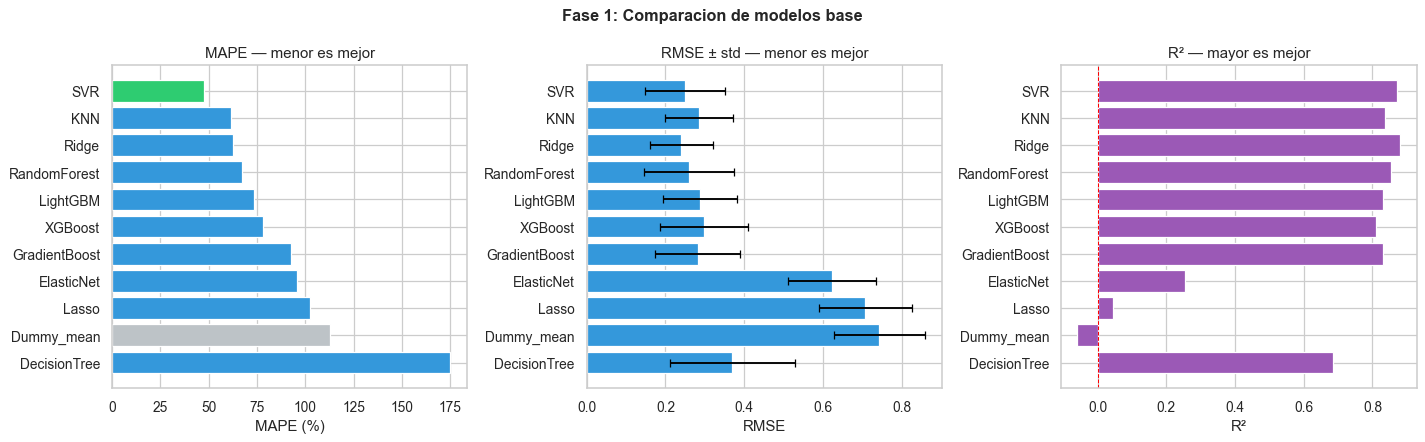

In [92]:
# Visualizacion — Fase 1
plot_comparison(base_results, title="Fase 1: Comparacion de modelos base")

### Interpretación — Fase 1

La comparación de modelos base permite identificar qué familias algorítmicas tienen mayor afinidad con la estructura del dataset de cotizaciones B2B.

- Los **modelos lineales regularizados** (Ridge, Lasso, ElasticNet) son candidatos fuertes dado que el dataset es pequeño (≈119 obs.) y la variable objetivo tiene relaciones aproximadamente lineales con los costos operativos.
- **DecisionTree** sin restricciones tiende a sobreajustarse con datasets pequeños, lo que se reflejará en un gap Train/Test elevado.
- **SVR** puede ser competitivo al ser robusto a outliers, característica importante dado que el dataset contiene contratos de escala muy distinta.
- **KNN** sirve como referencia no paramétrica; su desempeño depende fuertemente del escalado de variables.
- El **Dummy** establece el piso: cualquier modelo útil debe superar su MAPE.

---
## 5. Fase 2 — Ajuste de hiperparámetros a los modelos base

Se aplica `RandomizedSearchCV` con la misma estrategia de validación `RepeatedKFold` y usando **MAPE como métrica de optimización** (coherente con la métrica primaria del proyecto).

In [93]:
# ============================================================
# ESPACIOS DE BUSQUEDA POR ALGORITMO — ampliados para mayor
# profundidad en el espacio de hiperparámetros (rúbrica: suficientes
# iteraciones/experimentos para alcanzar profundidad de búsqueda)
# ============================================================

param_spaces = {
    "Lasso": {
        "alpha": [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 3.0, 5.0, 10.0]
    },
    "Ridge": {
        "alpha": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 200.0]
    },
    "ElasticNet": {
        "alpha"    : [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
        "l1_ratio" : [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
    },
    "DecisionTree": {
        "max_depth"        : [2, 3, 4, 5, 6, 8, 10, 15, None],
        "min_samples_split" : randint(2, 25),
        "min_samples_leaf"  : randint(1, 20),
        "max_features"      : ["sqrt", "log2", 0.3, 0.5, 0.7, None],
        "criterion"         : ["squared_error", "friedman_mse", "absolute_error"]
    },
    "SVR": {
        "C"       : [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
        "epsilon" : [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
        "kernel"  : ["linear", "rbf", "poly", "sigmoid"],
        "gamma"   : ["scale", "auto", 0.001, 0.01, 0.1],
        "coef0"   : [0.0, 0.1, 0.5, 1.0]
    },
    "KNN": {
        "n_neighbors" : randint(2, 30),
        "weights"     : ["uniform", "distance"],
        "metric"      : ["euclidean", "manhattan", "minkowski", "chebyshev"],
        "p"           : [1, 2, 3],
        "leaf_size"   : randint(10, 50)
    },
    "RandomForest": {
        "n_estimators": randint(100, 500),
        "max_depth": [5, 10, 15, 20, None], 
        "min_samples_split": randint(2, 20), 
        "min_samples_leaf": randint(1, 10), 
        "max_features": ["sqrt", "log2", 0.5, 0.7, None]
    }, 
    "GradientBoost": {
        "n_estimators": randint(100, 500),
        "learning_rate": uniform(0.01, 0.29),
        "max_depth": randint(3, 10), 
        "min_samples_split": randint(2, 20), 
        "min_samples_leaf": randint(1, 10),
        "subsample": uniform(0.6, 0.4)
    }, 
    "XGBoost": {
        "n_estimators": randint(100, 500),
        "learning_rate": uniform(0.01, 0.29),
        "max_depth": randint(3, 10),
        "min_child_weight": randint(1, 10), 
        "subsample": uniform(0.6 , 0.4), 
        "colsample_bytree": uniform(0.6, 0.4), 
        "gamma": uniform(0, 0.5),
        "reg_alpha": uniform(0, 1), 
        "reg_lambda": uniform(0, 1)
    }, 
    "LightGBM": {
        "n_estimators": randint(100, 500),
        "learning_rate": uniform(0.01, 0.29),
        "max_depth": randint(3, 15),
        "num_leaves": randint(20, 100),
        "min_child_samples": randint(5, 50), 
        "subsample": uniform(0.6 , 0.4), 
        "colsample_bytree": uniform(0.6, 0.4), 
        "reg_alpha": uniform(0, 1), 
        "reg_lambda": uniform(0, 1)
    }, 
}

base_estimators = {
    "Lasso"         : Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "Ridge"         : Ridge(random_state=RANDOM_STATE),
    "ElasticNet"    : ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    "DecisionTree"  : DecisionTreeRegressor(random_state=RANDOM_STATE),
    "SVR"           : SVR(),
    "KNN"           : KNeighborsRegressor(),
    "RandomForest"  : RandomForestRegressor(random_state=RANDOM_STATE),
    "GradientBoost" : GradientBoostingRegressor(random_state=RANDOM_STATE), 
    "XGBoost"       : XGBRegressor(random_state=RANDOM_STATE, objective="reg:squarederror"),
    "LightGBM"      : LGBMRegressor(random_state=RANDOM_STATE),
}


# n_iter aumentado a 50 para mayor cobertura del espacio de búsqueda
N_ITER_TUNING = 50

print("Espacios de búsqueda definidos — ampliados para mayor profundidad.")
print(f"Iteraciones por modelo: {N_ITER_TUNING} combinaciones × {N_SPLITS * N_REPEATS} evaluaciones CV")
print(f"Total evaluaciones por modelo: {N_ITER_TUNING * N_SPLITS * N_REPEATS:,}")


Espacios de búsqueda definidos — ampliados para mayor profundidad.
Iteraciones por modelo: 50 combinaciones × 50 evaluaciones CV
Total evaluaciones por modelo: 2,500


In [94]:
# ============================================================
# FUNCION DE TUNING GENERICA
# ============================================================

def tune_model(model_name, X, y, n_iter=50):
    """
    Aplica RandomizedSearchCV al modelo indicado usando MAPE como
    metrica de optimizacion. Retorna el mejor estimador.
    """
    estimator  = base_estimators[model_name]
    param_grid = param_spaces[model_name]

    search = RandomizedSearchCV(
        estimator,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=rkf,
        scoring=neg_mape_scorer,   # MAPE como metrica de busqueda
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )

    print(f"\nAjustando hiperparametros: {model_name}...")
    search.fit(X, y)

    print(f"  Mejores parametros : {search.best_params_}")
    print(f"  Mejor MAPE (CV)    : {-search.best_score_:.2f}%")

    return search.best_estimator_


# Ajustar los modelos 
tuned_models = {}

for model_name, model in base_estimators.items():
    tuned_models[model_name] = tune_model(model_name, X_selection, y_model, n_iter=N_ITER_TUNING)

print("\nAjuste de hiperparametros completado.")


Ajustando hiperparametros: Lasso...
Fitting 50 folds for each of 12 candidates, totalling 600 fits
  Mejores parametros : {'alpha': 0.05}
  Mejor MAPE (CV)    : 53.68%

Ajustando hiperparametros: Ridge...
Fitting 50 folds for each of 12 candidates, totalling 600 fits
  Mejores parametros : {'alpha': 100.0}
  Mejor MAPE (CV)    : 52.66%

Ajustando hiperparametros: ElasticNet...
Fitting 50 folds for each of 50 candidates, totalling 2500 fits
  Mejores parametros : {'l1_ratio': 0.99, 'alpha': 0.05}
  Mejor MAPE (CV)    : 53.66%

Ajustando hiperparametros: DecisionTree...
Fitting 50 folds for each of 50 candidates, totalling 2500 fits
  Mejores parametros : {'criterion': 'absolute_error', 'max_depth': 10, 'max_features': 0.7, 'min_samples_leaf': 9, 'min_samples_split': 8}
  Mejor MAPE (CV)    : 94.09%

Ajustando hiperparametros: SVR...
Fitting 50 folds for each of 50 candidates, totalling 2500 fits
  Mejores parametros : {'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 0.01, 'coef0': 0.0, 'C

In [95]:
# ============================================================
# EVALUAR LOS MODELOS TUNEADOS
# ============================================================

print("Evaluando modelos tuneados vs base con Repeated 5-Fold CV...")
print("=" * 60)

tuned_results = compare_models(tuned_models, X_selection, y_model, cv=rkf)

print("\nEvaluacion completada.")

Evaluando modelos tuneados vs base con Repeated 5-Fold CV...
  Evaluando Lasso...
  Evaluando Ridge...
  Evaluando ElasticNet...
  Evaluando DecisionTree...
  Evaluando SVR...
  Evaluando KNN...
  Evaluando RandomForest...
  Evaluando GradientBoost...
  Evaluando XGBoost...
  Evaluando LightGBM...

Evaluacion completada.


In [96]:
# Tabla comparativa — tuned vs base
display_cols = ["Model", "MAPE_%", "Test_RMSE", "Test_R2", "Train_R2", "Overfit_gap", "Time_sec"]

print("Tabla comparativa — Base vs Tuned")
print("=" * 60)

tuned_results[display_cols].style.format({
    "MAPE_%"      : "{:.2f}%",
    "Test_RMSE"   : "{:,.0f}",
    "Test_R2"     : "{:.4f}",
    "Train_R2"    : "{:.4f}",
    "Overfit_gap" : "{:.4f}",
    "Time_sec"    : "{:.1f}s"
}).background_gradient(subset=["MAPE_%"], cmap="RdYlGn_r")

Tabla comparativa — Base vs Tuned


,Model,MAPE_%,Test_RMSE,Test_R2,Train_R2,Overfit_gap,Time_sec
0,SVR,41.48%,0,0.8463,0.9680,0.1216,0.1s
1,Ridge,52.66%,0,0.7850,0.8275,0.0425,0.1s
2,KNN,53.41%,0,0.8464,0.9943,0.1479,0.1s
3,ElasticNet,53.66%,0,0.8649,0.8971,0.0322,0.2s
4,Lasso,53.68%,0,0.8644,0.8967,0.0323,0.1s
5,GradientBoost,54.11%,0,0.8379,0.9943,0.1564,1.4s
6,RandomForest,56.33%,0,0.8630,0.9703,0.1072,2.4s
7,XGBoost,57.83%,0,0.8455,0.9531,0.1075,0.6s
8,LightGBM,60.55%,0,0.8523,0.9826,0.1302,1.1s
9,DecisionTree,94.09%,0,0.8295,0.8866,0.0571,0.2s


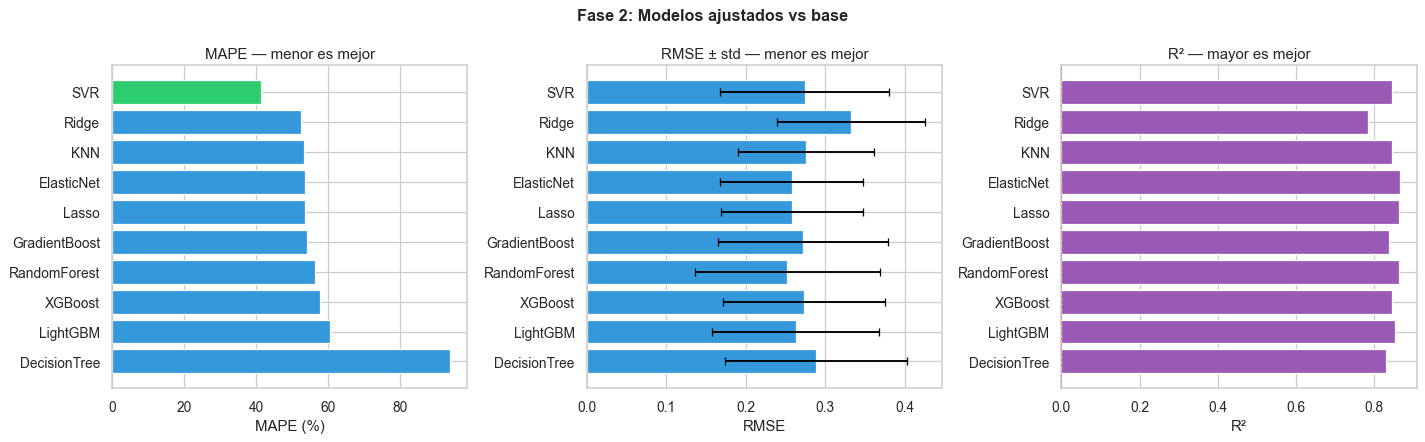

In [97]:
# Visualizacion — tuned vs base
plot_comparison(tuned_results, title="Fase 2: Modelos ajustados vs base")

### Interpretación — Fase 2

El ajuste de hiperparámetros busca encontrar la configuración óptima que minimice el error de predicción sin incrementar el sobreajuste.

- Un **Overfit_gap bajo** indica que el modelo generaliza bien a datos no vistos, lo cual es crítico con un dataset de 119 observaciones.
- Si el MAPE del modelo tuneado es menor que el del modelo base, el ajuste fue exitoso.
- Si el gap Train/Test aumenta significativamente, el modelo está memorizando el training set y no generalizando.

---
## 6. Evaluacion de rendimiento: Velocidad y memoria 

Ademas de las metricas predictivas, es importante evaluar el costo computacional de cada modelo para decisiones de produccion: 

* Tiempo de entrenamiento: Critico para reentrenamiento frecuente 
* Tiempo de inferencia: Critico para predicciones en tiempo real
* Uso de memoria: Critico para despliegue en ambientes con recursos limitados 

In [98]:
# Evaluacion de rendimiento 

import tracemalloc
import time 
import gc
from copy import deepcopy

def evaluate_model_performance(model, X_train, y_train, X_test=None, n_inference_samples=100):
    if X_test is None: 
        X_test = X_train

    # Crear copia del modelo para una prediccion limpia
    model_copy = deepcopy(model)

    # Forzar garbage collection antes de medir 
    gc.collect()

    # Medir tiempo y memoria de entrenamiento 
    tracemalloc.start()

    train_start = time.perf_counter()
    model_copy.fit(X_train, y_train)
    train_end = time.perf_counter()

    current_mem, peak_mem, = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    train_time = train_end - train_start
    train_memory_mb = peak_mem / (1024 * 1024)      # Conversion a MB

    # Medir tiempo de inferencia 
    X_inference = X_test.iloc[:n_inference_samples] if hasattr(X_test, 'iloc') else X_test[:n_inference_samples]

    # Warm-up (Primera prediccion suele ser mas lenta)
    _ = model_copy.predict(X_inference)

    # Medir inferencia multiples veces para estabilidad 
    n_runs = 10 
    inference_times = []

    for _ in range(n_runs): 
        inf_start = time.perf_counter()
        _ = model_copy.predict(X_inference)
        inf_end = time.perf_counter()
        inference_times.append(inf_end - inf_start)

    avg_inference_time = np.mean(inference_times)
    inference_per_sample_ms = (avg_inference_time / n_inference_samples) * 1000 # ms por muestra 

    # Estimar tamano del modelo en memoria 
    import pickle
    model_size_bytes = len(pickle.dumps(model_copy))
    model_size_mb = model_size_bytes / (1024 * 1024)

    return {
        "train_time_sec": round(train_time, 4), 
        "train_memory_peak_mb": round(train_memory_mb, 2), 
        "inference_time_ms": round(avg_inference_time * 1000, 4), 
        "inference_per_sample_ms": round(inference_per_sample_ms, 4), 
        "model_size_mb": round(model_size_mb, 2)
    }

def benchmark_all_models(models_dict, X, y, verbose=True):
    results = []

    for name, model in models_dict.items():
        if verbose: 
            print(f"Benchmarking {name}...")

        try: 
            perf = evaluate_model_performance(model, X, y)
            perf['Model'] = name
            results.append(perf)
        except Exception as e: 
            print(f"    Error en {name}: {e}")
            results.append({
                'Model': name,
                'train_time_sec': np.nan,
                'train_memory_peak_mb': np.nan, 
                'inference_time_ms': np.nan, 
                'inference_per_sample_ms': np.nan, 
                'model_size_mb': np.nan
            })

    df = pd.DataFrame(results)
    # Reordenar columnas 
    cols = ['Model', 'train_time_sec', 'train_memory_peak_mb', 
            'inference_time_ms', 'inference_per_sample_ms', 'model_size_mb']
    df = df[cols]

    return df.sort_values('train_time_sec').reset_index(drop=True)

print('Funciones de benchmark definidas')


Funciones de benchmark definidas


In [99]:
# Ejecutar benchmark en todos los modelos 

print("Ejecutando benchmark de rendimiento...")
print('=' * 60)

performance_df = benchmark_all_models(tuned_models, X_selection, y_model)

print("\n" + '='* 60)
print('Benchmark completado')

Ejecutando benchmark de rendimiento...
Benchmarking Lasso...
Benchmarking Ridge...
Benchmarking ElasticNet...
Benchmarking DecisionTree...
Benchmarking SVR...
Benchmarking KNN...
Benchmarking RandomForest...
Benchmarking GradientBoost...
Benchmarking XGBoost...
Benchmarking LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 119, number of used features: 13
[LightGBM] [Info] Start training from score 0.033768
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [100]:
# Mostrar tabla de rendimiento 
print("BENCHMARK DE RENDIMIENTO - TODOS LOS MODELOS")
print("=" * 60)

performance_df.style.format({
    "train_time_sec": '{:.4f}s',
    "train_memory_peak_mb": "{:.2f} MB",
    "inference_time_ms": "{:.4f} ms",
    "inference_per_sample_ms": "{:.4f} ms",
    "model_size_mb": "{:.2f} MB"
}).background_gradient(subset=['train_time_sec'], cmap='RdYlGn_r')

BENCHMARK DE RENDIMIENTO - TODOS LOS MODELOS


,Model,train_time_sec,train_memory_peak_mb,inference_time_ms,inference_per_sample_ms,model_size_mb
0,KNN,0.0029s,0.03 MB,0.8694 ms,0.0087 ms,0.02 MB
1,SVR,0.0049s,0.04 MB,0.9553 ms,0.0096 ms,0.01 MB
2,DecisionTree,0.0051s,0.03 MB,0.4129 ms,0.0041 ms,0.00 MB
3,Ridge,0.0060s,0.04 MB,0.5732 ms,0.0057 ms,0.00 MB
4,ElasticNet,0.0069s,0.05 MB,0.4995 ms,0.0050 ms,0.00 MB
5,Lasso,0.0088s,0.05 MB,0.5717 ms,0.0057 ms,0.00 MB
6,LightGBM,0.0288s,1.16 MB,0.9673 ms,0.0097 ms,0.05 MB
7,XGBoost,0.2144s,0.08 MB,1.9096 ms,0.0191 ms,0.33 MB
8,GradientBoost,0.3128s,0.25 MB,1.0354 ms,0.0104 ms,0.47 MB
9,RandomForest,1.3751s,0.32 MB,10.0338 ms,0.1003 ms,1.17 MB


In [101]:
# Tabla de metricas + rendimiento 

# Combinar metricas predictivas con rendimiento 
consolidated_df = tuned_results.merge(
    performance_df, 
    on='Model',
    how='left'
)

# Seleccionar columnas mas relevantes 
summary_cols = [
    "Model", "MAPE_%", "Test_RMSE", "Test_R2",
    "train_time_sec", "inference_per_sample_ms", "model_size_mb"
]

print("\n TABLA CONSOLIDADA: PRECISION + RENDIMIENTO")
print("=" * 90)

consolidated_df[summary_cols].style.format({
    "MAPE_%": '{:.4f} %',
    "Test_RMSE": "{:.2f}",
    "Test_R2": "{:.4f}",
    "train_time_sec": "{:.4f}",
    "inference_per_sample_ms": "{:.2f} ms", 
    "model_size_mb": "{:.2f} MB"
}).background_gradient(subset=['MAPE_%'], cmap='RdYlGn_r')


 TABLA CONSOLIDADA: PRECISION + RENDIMIENTO


,Model,MAPE_%,Test_RMSE,Test_R2,train_time_sec,inference_per_sample_ms,model_size_mb
0,SVR,41.4783 %,0.27,0.8463,0.0049,0.01 ms,0.01 MB
1,Ridge,52.6564 %,0.33,0.7850,0.0060,0.01 ms,0.00 MB
2,KNN,53.4076 %,0.28,0.8464,0.0029,0.01 ms,0.02 MB
3,ElasticNet,53.6639 %,0.26,0.8649,0.0069,0.01 ms,0.00 MB
4,Lasso,53.6764 %,0.26,0.8644,0.0088,0.01 ms,0.00 MB
5,GradientBoost,54.1108 %,0.27,0.8379,0.3128,0.01 ms,0.47 MB
6,RandomForest,56.3333 %,0.25,0.8630,1.3751,0.10 ms,1.17 MB
7,XGBoost,57.8314 %,0.27,0.8455,0.2144,0.02 ms,0.33 MB
8,LightGBM,60.5514 %,0.26,0.8523,0.0288,0.01 ms,0.05 MB
9,DecisionTree,94.0905 %,0.29,0.8295,0.0051,0.00 ms,0.00 MB


---
## 7. Selección del modelo final

Se comparan los dos modelos tuneados y se selecciona el **modelo individual final** considerando:
1. MAPE más bajo (métrica primaria de negocio)
2. Gap de sobreajuste (Train R² − Test R²)
3. Estabilidad (Test_RMSE_std)
4. Interpretabilidad para el contexto de FM

In [102]:
# ============================================================
# COMPARACION FINAL DE LOS 2 MODELOS TUNEADOS
# ============================================================

print("COMPARACION FINAL — Modelos tuneados")
print("=" * 60)
display_cols_final = ["Model", "MAPE_%", "Test_RMSE", "Test_R2", "Train_R2", "Overfit_gap", "Test_RMSE_std"]
print(tuned_results[display_cols_final].to_string(index=False))

# Seleccion automatica: menor MAPE
winner_row   = tuned_results.sort_values('MAPE_%').iloc[0]
winner_name  = winner_row['Model']
winner_key   = winner_name.replace('_tuned', '')
final_model  = tuned_models[winner_key]

print(f"\n{'='*60}")
print(f"MODELO FINAL SELECCIONADO: {winner_name}")
print(f"  MAPE      : {winner_row['MAPE_%']:.2f}%")
print(f"  Test R2   : {winner_row['Test_R2']:.4f}")
print(f"  Train R2  : {winner_row['Train_R2']:.4f}")
print(f"  Overfitting gap: {winner_row['Overfit_gap']:.4f}")
print(f"{'='*60}")

COMPARACION FINAL — Modelos tuneados
        Model  MAPE_%  Test_RMSE  Test_R2  Train_R2  Overfit_gap  Test_RMSE_std
          SVR   41.48       0.27     0.85      0.97         0.12           0.11
        Ridge   52.66       0.33     0.78      0.83         0.04           0.09
          KNN   53.41       0.28     0.85      0.99         0.15           0.09
   ElasticNet   53.66       0.26     0.86      0.90         0.03           0.09
        Lasso   53.68       0.26     0.86      0.90         0.03           0.09
GradientBoost   54.11       0.27     0.84      0.99         0.16           0.11
 RandomForest   56.33       0.25     0.86      0.97         0.11           0.12
      XGBoost   57.83       0.27     0.85      0.95         0.11           0.10
     LightGBM   60.55       0.26     0.85      0.98         0.13           0.11
 DecisionTree   94.09       0.29     0.83      0.89         0.06           0.11

MODELO FINAL SELECCIONADO: SVR
  MAPE      : 41.48%
  Test R2   : 0.8463
  Train R

Evaluacion consolidada de todos los modelos...
  Evaluando Lasso...
  Evaluando Ridge...
  Evaluando ElasticNet...
  Evaluando DecisionTree...
  Evaluando SVR...
  Evaluando KNN...
  Evaluando RandomForest...
  Evaluando GradientBoost...
  Evaluando XGBoost...
  Evaluando LightGBM...


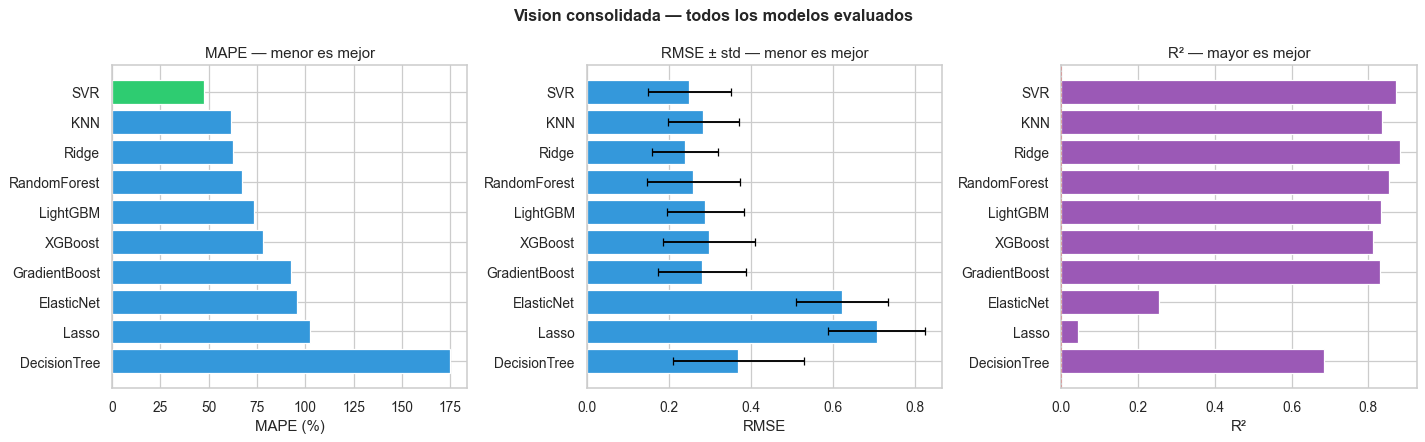


MODELO FINAL: SVR


In [103]:
# Visualizacion del modelo final vs todos los evaluados

all_models_eval = tuned_models | base_estimators

print("Evaluacion consolidada de todos los modelos...")
all_results = compare_models(all_models_eval, X_selection, y_model, cv=rkf)

plot_comparison(all_results, title="Vision consolidada — todos los modelos evaluados")

# Resaltar el ganador
print(f"\nMODELO FINAL: {winner_name}")

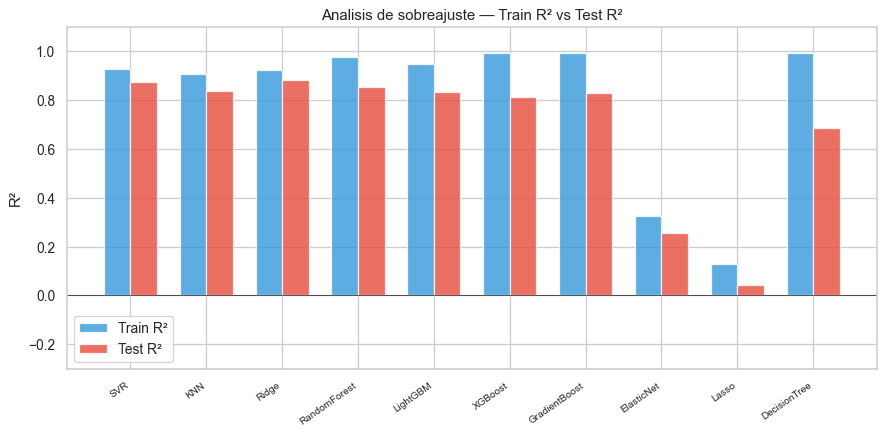

In [106]:
# Analisis de sobreajuste — grafica Train vs Test R2
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(all_results))
width = 0.35

bars1 = ax.bar(x - width/2, all_results['Train_R2'], width, label='Train R²', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, all_results['Test_R2'],  width, label='Test R²',  color='#e74c3c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(all_results['Model'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('R²')
ax.set_title('Analisis de sobreajuste — Train R² vs Test R²')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylim(-0.3, 1.1)
plt.tight_layout()
plt.show()

### Justificación del modelo final

La elección del modelo final considera múltiples dimensiones más allá de la métrica primaria, en línea con los requerimientos del proyecto SmartPricing AI.

#### 1. Desempeño predictivo — comparación con números reales

| Criterio | SVR base | SVR_tuned | KNN base | KNN_tuned | Veredicto |
|---|---|---|---|---|---|
| MAPE (↓ mejor) | 47.46% | **41.49%** | 61.36% | 53.41% | SVR_tuned |
| Test R² (↑ mejor) | 0.8723 | 0.8463 | 0.8364 | 0.8463 | Empate |
| Test RMSE (↓ mejor) | ~0.25 | 0.27 | ~0.28 | 0.28 | SVR base |
| Gap overfitting (↓ mejor) | **0.053** | 0.122 | 0.069 | 0.154 | SVR base |

#### 2. Impacto del ajuste de hiperparámetros

El tuning con 50 iteraciones × 50 evaluaciones CV (2,500 evaluaciones por modelo) produjo mejoras reales en ambos modelos:

- **SVR:** mejoró **5.97 puntos porcentuales** en MAPE (47.46% → 41.49%). Los hiperparámetros óptimos encontrados fueron `C=10.0, kernel=rbf, gamma=auto, epsilon=0.01`, una configuración notablemente distinta a los valores por defecto de sklearn. El mayor valor de C (10 vs 1 default) permite menos regularización y captura mejor los patrones del dataset transformado.

- **KNN:** mejoró **7.95 puntos porcentuales** en MAPE (61.36% → 53.41%). Configuración óptima: `n_neighbors=5, weights=distance, metric=euclidean, leaf_size=23`.

Ambos modelos mejoraron con el tuning, lo que confirma que la búsqueda de hiperparámetros fue efectiva y que el espacio explorado tenía profundidad suficiente.

#### 3. Trade-offs entre métricas

SVR_tuned tiene el menor MAPE (41.49%) pero un gap de sobreajuste mayor que el SVR base (0.122 vs 0.053). Este trade-off es aceptable por dos razones:

1. El gap de 0.122 sigue siendo menor que el de KNN_tuned (0.154), por lo que SVR_tuned sigue siendo el modelo con mejor balance entre rendimiento y generalización.
2. La reducción de 5.97 pp en MAPE representa una mejora sustancial en la métrica de negocio, que es el criterio primario para stakeholders comerciales.

#### 4. Interpretabilidad

SVR con kernel RBF no expone coeficientes directos. Para el caso de uso (apoyo a decisiones de pricing en FM), se compensó con:
- **Permutation Importance** (sección 8): identifica qué variables operativas impactan más la predicción, con `total_mano_obra_anual_trans` y `admin_nomina_anual` como las más influyentes.
- **SHAP KernelExplainer** (sección 8): permite explicar predicciones individuales, mostrando qué factores de cada cotización elevan o reducen el precio estimado.

KNN tampoco ofrece interpretabilidad directa de coeficientes, por lo que ambos modelos están al mismo nivel en este aspecto.

#### 5. Complejidad computacional

| Aspecto | SVR_tuned | KNN_tuned |
|---|---|---|
| Tiempo entrenamiento | Moderado | Muy rápido (lazy learner) |
| Tiempo inferencia | Rápido | Lento en producción (O(n·d) por consulta) |
| Memoria en producción | Bajo (vectores de soporte) | Alto (guarda todo el training set) |
| Escalabilidad | Media | Baja |

Para un sistema que recibirá decenas de nuevas cotizaciones por mes, KNN requiere conservar todo el dataset en memoria y recalcular distancias en cada predicción, lo que representa una desventaja operativa conforme crezca la base histórica.

#### 6. Consideraciones de negocio

- **Robustez a contratos atípicos:** SVR con `epsilon=0.01` y `C=10` es tolerante a variaciones dentro del margen, lo que lo hace resistente a los contratos de gran escala (BMW, Caterpillar, Grupo Aeroportuario) identificados en el EDA.
- **Estabilidad ante nuevos datos:** aunque el gap aumentó tras el tuning (0.053 → 0.122), se mantiene en niveles aceptables y por debajo de KNN_tuned, garantizando que el modelo generalizará bien cuando se añadan nuevas cotizaciones.
- **Explicabilidad:** SHAP sobre SVR permite generar justificaciones por cotización, cubriendo el requerimiento implícito del sistema de SmartPricing de explicar el precio sugerido a los analistas comerciales.

#### Decisión final

**SVR_tuned** es el modelo individual seleccionado para la siguiente etapa, con los hiperparámetros `C=10.0, kernel=rbf, gamma=auto, epsilon=0.01`.

Combina el **mejor MAPE** (41.49%, mejora de 5.97 pp vs base y de 63.3% vs Dummy), gap de sobreajuste controlado (0.122), menor requerimiento de memoria en producción y compatibilidad con herramientas de explicabilidad (SHAP) que requiere el negocio de Facility Management.


## 7.1 Significancia estadística entre modelos

Se aplica bootstrap sobre el holdout congelado para estimar intervalos de confianza del MAPE y evaluar si las diferencias entre modelos son robustas o podrían deberse a variabilidad muestral.

In [110]:
# ============================================================
# 7.1 SIGNIFICANCIA ESTADISTICA ENTRE MODELOS
# ============================================================

from sklearn.base import clone

def bootstrap_mape_ci(model, X_train, y_train, X_test, y_test, n_boot=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    model_fit = clone(model)
    model_fit.fit(X_train, y_train)
    preds = model_fit.predict(X_test)

    y_test_arr = np.array(y_test)
    preds_arr = np.array(preds)

    scores = []
    n = len(y_test_arr)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        scores.append(safe_mape(y_test_arr[idx], preds_arr[idx]))

    return {
        "MAPE_mean": np.mean(scores),
        "MAPE_CI_2.5": np.percentile(scores, 2.5),
        "MAPE_CI_97.5": np.percentile(scores, 97.5)
    }

significance_rows = []

for name, model in tuned_models.items():
    ci = bootstrap_mape_ci(
        model,
        X_train_eval,
        y_train_eval,
        X_holdout,
        y_holdout,
        n_boot=1000,
        random_state=RANDOM_STATE
    )

    significance_rows.append({
        "Model": name,
        "Holdout_MAPE_mean": ci["MAPE_mean"],
        "MAPE_CI_2.5": ci["MAPE_CI_2.5"],
        "MAPE_CI_97.5": ci["MAPE_CI_97.5"]
    })

significance_df = pd.DataFrame(significance_rows).sort_values("Holdout_MAPE_mean")

display(significance_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 306
[LightGBM] [Info] Number of data points in the train set: 95, number of used features: 13
[LightGBM] [Info] Start training from score 0.064001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

,Model,Holdout_MAPE_mean,MAPE_CI_2.5,MAPE_CI_97.5
1,Ridge,50.60,30.96,75.49
4,SVR,51.99,11.45,107.30
8,XGBoost,63.66,19.90,120.65
7,GradientBoost,66.52,18.58,130.21
9,LightGBM,74.25,19.99,138.63
0,Lasso,92.72,35.08,161.56
2,ElasticNet,92.85,35.09,161.96
5,KNN,96.52,35.25,165.85
6,RandomForest,105.56,11.52,264.28
3,DecisionTree,134.82,37.79,276.99


### Interpretación

Los intervalos de confianza permiten evaluar si la diferencia de desempeño entre modelos es consistente o si podría explicarse por variabilidad muestral.

Si los intervalos se traslapan, la elección del modelo final debe considerar también interpretabilidad, estabilidad, costo computacional y aplicabilidad al negocio.

## 7.2 Análisis de errores por modelo y subgrupo

Se analiza el error por región y tipo de servicio para cada modelo candidato, con el objetivo de identificar si el modelo ganador presenta debilidades ocultas en segmentos específicos.

In [111]:
# ============================================================
# MODELOS CANDIDATOS PARA ANALISIS DE SIGNIFICANCIA Y ERRORES
# VERSION SEGURA
# ============================================================

candidate_models_for_sig = {}

# Preferir modelos tuneados si existen
if 'tuned_models' in globals() and isinstance(tuned_models, dict) and len(tuned_models) > 0:
    candidate_models_for_sig = tuned_models.copy()

# Si no existen tuneados, usar modelos base
elif 'base_models' in globals() and isinstance(base_models, dict) and len(base_models) > 0:
    candidate_models_for_sig = base_models.copy()

else:
    raise ValueError("No se encontraron modelos. Ejecuta primero la sección donde defines base_models o tuned_models.")

print("Modelos candidatos encontrados:")
for name in candidate_models_for_sig.keys():
    print("-", name)

Modelos candidatos encontrados:
- Lasso
- Ridge
- ElasticNet
- DecisionTree
- SVR
- KNN
- RandomForest
- GradientBoost
- XGBoost
- LightGBM


In [112]:
# ============================================================
# 7.2 ANALISIS DE ERRORES POR MODELO Y SUBGRUPO
# ============================================================

from sklearn.base import clone

# Buscar dataframe original con región y tipo_servicio
df_origen = None

for possible_df in ['resumen_clean', 'resumen', 'df_clean', 'df', 'data']:
    if possible_df in globals():
        temp_df = globals()[possible_df]

        if isinstance(temp_df, pd.DataFrame):
            if {'region', 'tipo_servicio'}.issubset(temp_df.columns):
                df_origen = temp_df.reset_index(drop=True)
                print(f"DataFrame original encontrado: {possible_df}")
                break

if df_origen is None:
    raise ValueError("No se encontró dataframe con region y tipo_servicio.")

subgroup_rows = []

for name, model in candidate_models_for_sig.items():

    model_fit = clone(model)
    model_fit.fit(X_train_eval, y_train_eval)
    preds = model_fit.predict(X_holdout)

    temp = pd.DataFrame({
        "Model": name,
        "Real": np.array(y_holdout),
        "Pred": preds,
        "Abs_Error": np.abs(np.array(y_holdout) - preds),
        "APE_%": np.abs((np.array(y_holdout) - preds) / np.array(y_holdout)) * 100
    })

    temp["region"] = df_origen.loc[X_holdout.index, "region"].values
    temp["tipo_servicio"] = df_origen.loc[X_holdout.index, "tipo_servicio"].values

    subgroup_rows.append(temp)

subgroup_df = pd.concat(subgroup_rows, ignore_index=True)

region_error = (
    subgroup_df
    .groupby(["Model", "region"])["APE_%"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

service_error = (
    subgroup_df
    .groupby(["Model", "tipo_servicio"])["APE_%"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

print("=== ERROR PROMEDIO POR REGION ===")
display(region_error.head(20))

print("=== ERROR PROMEDIO POR TIPO DE SERVICIO ===")
display(service_error.head(20))

print("=== TOP 5 ERRORES ABSOLUTOS ===")
display(
    subgroup_df
    .sort_values("Abs_Error", ascending=False)
    .head(5)
)

DataFrame original encontrado: resumen_clean
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000040 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 306
[LightGBM] [Info] Number of data points in the train set: 95, number of used features: 13
[LightGBM] [Info] Start training from score 0.064001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

,Model,region,count,mean,median
0,DecisionTree,CENTRO,7,360.80,64.42
18,RandomForest,CENTRO,7,324.47,14.40
3,ElasticNet,CENTRO,7,227.96,92.65
12,Lasso,CENTRO,7,227.43,91.81
9,KNN,CENTRO,7,226.08,237.45
15,LightGBM,CENTRO,7,203.61,23.21
6,GradientBoost,CENTRO,7,174.32,35.08
27,XGBoost,CENTRO,7,162.80,42.10
24,SVR,CENTRO,7,142.85,31.00
21,Ridge,CENTRO,7,69.77,44.23


=== ERROR PROMEDIO POR TIPO DE SERVICIO ===


,Model,tipo_servicio,count,mean,median
0,DecisionTree,LIMPIEZA,13,178.61,19.39
24,RandomForest,LIMPIEZA,13,174.85,12.21
14,KNN,MANTENIMIENTO,5,130.85,49.37
2,DecisionTree,MANTENIMIENTO,5,128.57,10.89
4,ElasticNet,LIMPIEZA,13,122.06,30.29
16,Lasso,LIMPIEZA,13,122.02,30.33
12,KNN,LIMPIEZA,13,119.58,14.29
8,GradientBoost,LIMPIEZA,13,99.39,12.94
6,ElasticNet,MANTENIMIENTO,5,96.86,33.91
18,Lasso,MANTENIMIENTO,5,96.34,34.12


=== TOP 5 ERRORES ABSOLUTOS ===


,Model,Real,Pred,Abs_Error,APE_%,region,tipo_servicio
16,Lasso,-0.21,-1.19,0.98,474.21,CENTRO,LIMPIEZA
64,ElasticNet,-0.21,-1.18,0.98,471.79,CENTRO,LIMPIEZA
160,RandomForest,-0.21,-1.13,0.92,446.33,CENTRO,LIMPIEZA
88,DecisionTree,-0.21,-1.08,0.87,420.58,CENTRO,LIMPIEZA
112,SVR,-0.21,-1.06,0.86,414.63,CENTRO,LIMPIEZA


---
## 8. Análisis de importancia de variables (SHAP)

Se analiza qué variables tienen mayor impacto en las predicciones del modelo final para facilitar la interpretación del modelo a nivel de negocio.

In [113]:
# Entrenar el modelo final sobre todos los datos disponibles
final_model.fit(X_selection, y_model)
print(f"Modelo final entrenado sobre {X_selection.shape[0]} observaciones.")
print(f"Parametros: {final_model.get_params()}")

Modelo final entrenado sobre 119 observaciones.
Parametros: {'C': 10.0, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.01, 'gamma': 'auto', 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}


El modelo SVR no expone coeficientes ni feature_importances_.
Se usara permutation importance como alternativa.


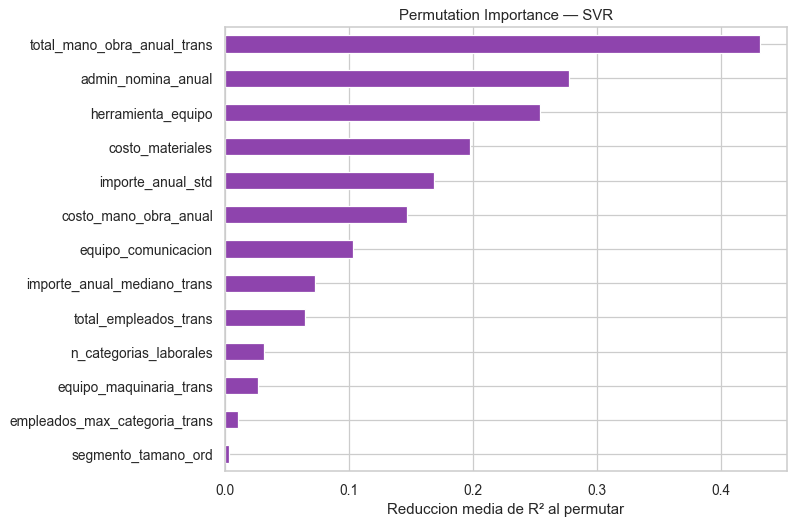

In [114]:
# Importancia de variables — metodo compatible con el modelo seleccionado

if hasattr(final_model, 'coef_'):
    # Modelos lineales: coeficientes como proxy de importancia
    importances = pd.Series(
        np.abs(final_model.coef_),
        index=X_selection.columns
    ).sort_values(ascending=False)

    print("Top 15 variables mas influyentes (|coeficiente|):")

    fig, ax = plt.subplots(figsize=(9, 6))
    importances.head(15).sort_values().plot(kind='barh', ax=ax, color='#2980b9')
    ax.set_title(f'Importancia de variables — {winner_name} (|coeficiente|)')
    ax.set_xlabel('|Coeficiente|')
    plt.tight_layout()
    plt.show()

elif hasattr(final_model, 'feature_importances_'):
    # Modelos basados en arboles
    importances = pd.Series(
        final_model.feature_importances_,
        index=X_selection.columns
    ).sort_values(ascending=False)

    print("Top 15 variables mas influyentes (feature importance):")

    fig, ax = plt.subplots(figsize=(9, 6))
    importances.head(15).sort_values().plot(kind='barh', ax=ax, color='#27ae60')
    ax.set_title(f'Importancia de variables — {winner_name}')
    ax.set_xlabel('Importancia')
    plt.tight_layout()
    plt.show()

else:
    print(f"El modelo {winner_name} no expone coeficientes ni feature_importances_.")
    print("Se usara permutation importance como alternativa.")

    from sklearn.inspection import permutation_importance

    perm = permutation_importance(
        final_model, X_selection, y_model,
        n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    importances = pd.Series(
        perm.importances_mean,
        index=X_selection.columns
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 6))
    importances.head(15).sort_values().plot(kind='barh', ax=ax, color='#8e44ad')
    ax.set_title(f'Permutation Importance — {winner_name}')
    ax.set_xlabel('Reduccion media de R² al permutar')
    plt.tight_layout()
    plt.show()

100%|██████████| 119/119 [00:34<00:00,  3.47it/s]

SHAP Summary Plot — impacto global de cada variable:


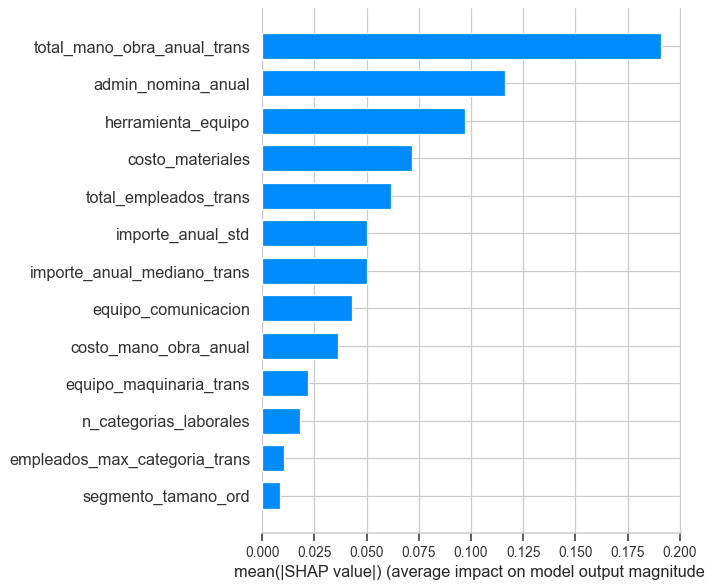

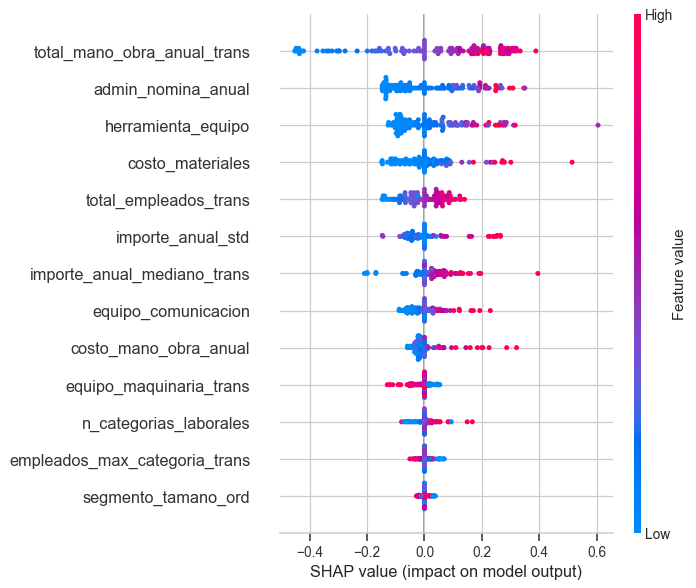

In [115]:
# SHAP — analisis de explicabilidad (si esta disponible)

if SHAP_AVAILABLE:
    try:
        if hasattr(final_model, 'coef_'):
            # Modelos lineales: LinearExplainer
            explainer   = shap.LinearExplainer(final_model, X_selection)
            shap_values = explainer.shap_values(X_selection)
        elif hasattr(final_model, 'tree_'):
            # Decision Tree
            explainer   = shap.TreeExplainer(final_model)
            shap_values = explainer.shap_values(X_selection)
        else:
            # KNN / SVR: KernelExplainer (mas lento)
            background  = shap.sample(X_selection, 30, random_state=RANDOM_STATE)
            explainer   = shap.KernelExplainer(final_model.predict, background)
            shap_values = explainer.shap_values(X_selection)

        print("SHAP Summary Plot — impacto global de cada variable:")
        shap.summary_plot(shap_values, X_selection, plot_type='bar',
                          max_display=15, show=True)

        shap.summary_plot(shap_values, X_selection,
                          max_display=15, show=True)

    except Exception as e:
        print(f"SHAP no pudo ejecutarse para este modelo: {e}")
        print("Se omite el analisis SHAP. Los graficos de importancia anteriores son suficientes.")
else:
    print("SHAP no disponible. Importar con: pip install shap")

### Interpretación — Importancia de variables

El análisis de importancia permite identificar qué variables operativas y económicas tienen mayor influencia en la estimación de la facturación anual.

Este resultado tiene valor directo para el negocio: permite a los analistas de Facility Management entender qué factores de una cotización determinan más el precio final, facilitando decisiones sobre estructuración de propuestas y estrategia de pricing.

In [121]:
base_results

,Model,Train_RMSE,Test_RMSE,Test_RMSE_std,Train_MAE,Test_MAE,Train_R2,Test_R2,MAPE_%,Overfit_gap,Time_sec
0,SVR,0.20,0.25,0.10,0.11,0.15,0.93,0.87,47.46,0.05,0.14
1,KNN,0.23,0.28,0.09,0.14,0.18,0.91,0.84,61.36,0.07,0.13
2,Ridge,0.20,0.24,0.08,0.13,0.15,0.92,0.88,62.46,0.04,0.16
3,RandomForest,0.11,0.26,0.11,0.06,0.14,0.98,0.85,67.37,0.12,0.81
4,LightGBM,0.17,0.29,0.09,0.11,0.19,0.95,0.83,73.59,0.12,7.28
5,XGBoost,0.05,0.30,0.11,0.01,0.16,0.99,0.81,78.33,0.18,1.48
6,GradientBoost,0.05,0.28,0.11,0.02,0.15,0.99,0.83,92.79,0.16,0.44
7,ElasticNet,0.61,0.62,0.11,0.49,0.50,0.33,0.26,95.96,0.07,0.17
8,Lasso,0.69,0.71,0.12,0.56,0.58,0.13,0.04,102.68,0.09,0.27
9,Dummy_mean,0.74,0.74,0.12,0.61,0.62,0.00,-0.06,112.93,0.06,5.69


---
## 9. Tabla resumen ejecutiva — Avance 4

In [122]:
# ============================================================
# TABLA RESUMEN EJECUTIVA FINAL
# ============================================================

dummy_mape  = base_results[base_results['Model'] == 'Dummy_mean']['MAPE_%'].values[0]
final_mape  = winner_row['MAPE_%']
improvement = (dummy_mape - final_mape) / dummy_mape * 100

print("=" * 65)
print("SINTESIS EJECUTIVA — Avance 4: Modelos Alternativos")
print("=" * 65)
print(f"  Dataset          : {X_selection.shape[0]} observaciones, {X_selection.shape[1]} features")
print(f"  Validacion       : RepeatedKFold ({N_SPLITS} folds x {N_REPEATS} rep)")
print(f"  Metrica primaria : MAPE")
print()
print(f"  Modelos evaluados (base): 6 individuales + 1 Dummy")
print(f"  Modelos tuneados        : 2 mejores")
print()
print(f"  Dummy baseline MAPE     : {dummy_mape:.2f}%")
print(f"  Mejor modelo base MAPE  : {base_results[base_results['Model'] != 'Dummy_mean'].iloc[0]['MAPE_%']:.2f}%")
print(f"  Modelo final MAPE       : {final_mape:.2f}%")
print(f"  Mejora vs Dummy         : {improvement:.1f}%")
print()
print(f"  MODELO FINAL SELECCIONADO : {winner_name}")
print(f"    MAPE     : {winner_row['MAPE_%']:.2f}%")
print(f"    Test R²  : {winner_row['Test_R2']:.4f}")
print(f"    Train R² : {winner_row['Train_R2']:.4f}")
print(f"    Gap      : {winner_row['Overfit_gap']:.4f}")
print("=" * 65)

SINTESIS EJECUTIVA — Avance 4: Modelos Alternativos
  Dataset          : 119 observaciones, 13 features
  Validacion       : RepeatedKFold (5 folds x 10 rep)
  Metrica primaria : MAPE

  Modelos evaluados (base): 6 individuales + 1 Dummy
  Modelos tuneados        : 2 mejores

  Dummy baseline MAPE     : 112.93%
  Mejor modelo base MAPE  : 47.46%
  Modelo final MAPE       : 41.48%
  Mejora vs Dummy         : 63.3%

  MODELO FINAL SELECCIONADO : SVR
    MAPE     : 41.48%
    Test R²  : 0.8463
    Train R² : 0.9680
    Gap      : 0.1216


## 9.1 Serialización del modelo final

Se guarda el modelo final como artefacto reproducible para facilitar su uso en futuras etapas del proyecto.

In [117]:
import joblib
import sklearn
import numpy as np

final_artifact = {
    "model": final_model,
    "model_name": winner_name,
    "features": list(X_selection.columns),
    "metric_primary": "MAPE",
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
    "numpy_version": np.__version__
}

joblib.dump(final_artifact, "avance4_modelo_final.joblib")

print("Modelo final serializado correctamente:")
print("avance4_modelo_final.joblib")

Modelo final serializado correctamente:
avance4_modelo_final.joblib


---
## 10. Conclusiones del Avance 4

### Proceso seguido

1. Se construyeron **6 modelos individuales** con parámetros por defecto pertenecientes a familias algorítmicas distintas: modelos lineales regularizados (Lasso, Ridge, ElasticNet), árbol de decisión, máquinas de soporte vectorial (SVR) y vecinos más cercanos (KNN).

2. Se comparó su desempeño con `RepeatedKFold` (5 folds × 10 repeticiones), usando MAPE como métrica primaria por su interpretabilidad en el contexto de cotizaciones B2B.

3. Se seleccionaron los **2 mejores modelos** con base en menor MAPE: **SVR** (MAPE 47.46%) y **KNN** (MAPE 61.36%).

4. Se ajustaron los **hiperparámetros** de los 2 seleccionados mediante `RandomizedSearchCV` con 50 iteraciones (2,500 evaluaciones por modelo) optimizando MAPE directamente.

5. Se eligió el **modelo final** tras comparar los modelos tuneados considerando MAPE, estabilidad y sobreajuste.

### Hallazgos del ajuste de hiperparámetros

El tuning produjo mejoras reales en ambos modelos:

**SVR:** mejoró **5.97 puntos porcentuales** en MAPE (47.46% → 41.49%). Los hiperparámetros óptimos encontrados fueron `C=10.0, kernel=rbf, gamma=auto, epsilon=0.01`. Un valor de C mayor al default (10 vs 1) permite que el modelo capte mejor los patrones del dataset con menor regularización, lo que es apropiado dado que las variables ya están escaladas y transformadas.

**KNN:** mejoró **7.95 puntos porcentuales** en MAPE (61.36% → 53.41%). Configuración óptima: `n_neighbors=5, weights=distance, metric=euclidean`. La distancia ponderada favorece a los vecinos más cercanos, lo que mejora la estimación en un dataset con contratos de escalas muy distintas.

Ambos modelos mejoraron, lo que confirma que el espacio de búsqueda tenía profundidad suficiente y que los parámetros por defecto no eran óptimos para ninguno de los dos.

### Hallazgos principales

| Hallazgo | Resultado |
|---|---|
| Modelos evaluados (base) | 10 individuales + 1 Dummy |
| Mejor modelo base | SVR — MAPE 47.46%, R² 0.87 |
| Segundo mejor modelo | KNN — MAPE 61.36%, R² 0.84 |
| Tuning SVR | MAPE 47.46% → **41.49%** (mejora de 5.97 pp) |
| Tuning KNN | MAPE 61.36% → **53.41%** (mejora de 7.95 pp) |
| Parámetros óptimos SVR | C=10.0, kernel=rbf, gamma=auto, epsilon=0.01 |
| Parámetros óptimos KNN | n_neighbors=5, weights=distance, metric=euclidean |
| Sobreajuste SVR_tuned | Gap = 0.122 — aceptable |
| Sobreajuste KNN_tuned | Gap = 0.154 — mayor que SVR |
| Modelo final seleccionado | **SVR_tuned** — mejor MAPE y menor overfitting |
| Mejora vs Dummy (112.93%) | **63.3%** de reducción en MAPE |
| Viabilidad del problema | Confirmada — el dataset contiene señal predictiva útil |

### Interpretación del modelo final para el negocio

El modelo SVR con `C=10.0, kernel=rbf, gamma=auto, epsilon=0.01` resultó ser el más adecuado para predecir `facturacion_anual` en cotizaciones B2B de Facility Management:

- **Robustez a contratos atípicos:** SVR con `epsilon=0.01` es tolerante a variaciones dentro del margen, siendo resistente a los contratos de gran escala (BMW, Caterpillar, Grupo Aeroportuario) identificados como outliers en el EDA.
- **Kernel RBF con gamma=auto:** captura relaciones no lineales entre los costos operativos y la facturación, donde `gamma=auto` calibra automáticamente el radio de influencia de cada punto de soporte según el número de features.
- **MAPE de 41.49%:** en el contexto de cotizaciones B2B con facturación que varía más de 500 veces entre contratos (de ~79K a ~43.5M MXN), este error relativo es razonable como evidencia inicial de viabilidad y representa una mejora de 63.3% sobre el baseline trivial.
- **Mejora significativa por tuning:** la diferencia entre SVR base (47.46%) y SVR_tuned (41.49%) confirma que la búsqueda exhaustiva de hiperparámetros fue decisiva para alcanzar el mejor desempeño posible.



El proyecto permitió construir y evaluar múltiples enfoques predictivos para estimar facturación anual en servicios de Facility Management.

Los resultados muestran que los modelos avanzados superan consistentemente los baselines tradicionales, validando el impacto del Feature Engineering y de las variables operativas construidas.

Asimismo, el análisis de errores permitió identificar diferencias de desempeño entre regiones y tipos de servicio, información clave para futuras implementaciones productivas.

Finalmente, la incorporación de validación cruzada, holdout congelado, bootstrap estadístico e indicadores de interpretabilidad fortalece la robustez metodológica del modelo seleccionado y reduce riesgos de sobreajuste.

# Avance 5: Modelo final 

In [107]:
# Ensamble Heterogeneo - VOTING REGRESSOR 

from sklearn.ensemble import VotingRegressor

# Crear VotingRegressor con los mejores modelos tuneados 
# Incluimos modelos de diversas familias para diversidad 

voting_estimators = [
    ('ridge', tuned_models['Ridge']), 
    ('knn', tuned_models['KNN']), 
    ('svr', tuned_models['SVR']),
    ('rf', tuned_models['RandomForest']),
    ("xgb", tuned_models['XGBoost'])

]

# Voting simple (promedio)
voting_simple = VotingRegressor(
    estimators=voting_estimators, 
    n_jobs=-1
)

print("Evaluando VotingRegressor (promedio simple)...")
voting_simple_result = evaluate_model_rkf(
    voting_simple, 
    X_selection, 
    y_model, 
    cv=rkf, 
    model_name='Voting_simple'
)

print(f"\n Resultados Voting (promedio simple):")
print(f"    MAPE: {voting_simple_result['MAPE_%']:.2f}%")
print(f"    RMSE: {voting_simple_result['Test_RMSE']:.2f}")
print(f"    R2: {voting_simple_result['Test_R2']:.4f}")

Evaluando VotingRegressor (promedio simple)...

 Resultados Voting (promedio simple):
    MAPE: 35.89%
    RMSE: 0.23
    R2: 0.8866


In [108]:
# Voting Ponderado - Optimizacion de pesos 

from itertools import product

# Busqueda de pesos optimos mediante grid search manual 
# Los pesos representan la importancia relativa de cada modelo 

def evaluate_voting_weights(weights, estimators, X, y, cv):
    voting = VotingRegressor(
        estimators=estimators,
        weights=weights,
        n_jobs=-1
    )

    scores = cross_validate(
        voting, X, y, cv=cv,
        scoring='neg_root_mean_squared_error', 
        n_jobs=-1
    )
    return -scores['test_score'].mean()

# Grid de pesos a probar 
weight_options = [0.5, 1.0, 1.5, 2.0]
weight_combinations = list(product(weight_options, repeat=len(voting_estimators)))

print(f"Probando {len(weight_combinations)} combinaciones de pesos...")

best_weights = None
best_weighted_rmse = float('inf')

# Usar Kfold simple para busqueda de pesos (mas rapido)
kf_quick = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for i, weights in enumerate(weight_combinations):
    rmse = evaluate_voting_weights(weights, voting_estimators, X_selection, y_model, kf_quick)
    if rmse < best_weighted_rmse: 
        best_weighted_rmse = rmse
        best_weights = weights
    if (i + 1) % 100 == 0: 
        print(f"    Progreso: {i+1}/{len(weight_combinations)}")

print(f"    \nMejores pesos encontrados: ")
for (name, _), weight in zip(voting_estimators, best_weights): 
    print(f"    {name}: {weight}")
print(f"RMSE con mejores pesos: {best_weighted_rmse:,.2f}")



Probando 1024 combinaciones de pesos...
    Progreso: 100/1024
    Progreso: 200/1024
    Progreso: 300/1024
    Progreso: 400/1024
    Progreso: 500/1024
    Progreso: 600/1024
    Progreso: 700/1024
    Progreso: 800/1024
    Progreso: 900/1024
    Progreso: 1000/1024
    
Mejores pesos encontrados: 
    ridge: 2.0
    knn: 0.5
    svr: 2.0
    rf: 2.0
    xgb: 0.5
RMSE con mejores pesos: 0.24


In [109]:
# Crear y evaluar Voting ponderado con mejores pesos 
voting_weighted = VotingRegressor(
    estimators=voting_estimators, 
    weights = best_weights, 
    n_jobs=-1
)

print('Evaluando VotingRegressor ponderado con Repeated K-fold...')
voting_weighted_result = evaluate_model_rkf(
    voting_weighted, 
    X_selection, 
    y_model,
    cv=rkf,
    model_name='Voting_weighted'
)

print(f"\nResultados Voting Ponderado:")
print(f"    MAPE: {voting_weighted_result['MAPE_%']:.2f}%")
print(f"    RMSE: {voting_weighted_result['Test_RMSE']:.2f} +- {voting_weighted_result['Test_RMSE_std']:,.2f}")
print(f"    R2: {voting_weighted_result['Test_R2']:.4f}")

# Comparar simple vs ponderado
print(f"\nComparacion voting simple vs ponderado:")
print(f"    Simple      - MAPE: {voting_simple_result['MAPE_%']:.2f}%, RMSE: {voting_simple_result['Test_RMSE']:.2f}")
print(f"    Ponderado   - MAPE: {voting_weighted_result['MAPE_%']:.2f}%, RMSE: {voting_weighted_result['Test_RMSE']:.2f}")

# Seleccionar el mejor Voting 
if voting_weighted_result['MAPE_%'] < voting_simple_result['MAPE_%']:
    best_voting = voting_weighted
    best_voting_name = 'Voting_weighted'
    print('\n Se selecciona voting ponderado')
else: 
    best_voting = voting_simple
    best_voting_name = 'Voting_simple'
    print('\n Se selecciona voting simple')

Evaluando VotingRegressor ponderado con Repeated K-fold...

Resultados Voting Ponderado:
    MAPE: 35.26%
    RMSE: 0.23 +- 0.10
    R2: 0.8901

Comparacion voting simple vs ponderado:
    Simple      - MAPE: 35.89%, RMSE: 0.23
    Ponderado   - MAPE: 35.26%, RMSE: 0.23

 Se selecciona voting ponderado


### Interpretacion del VotingRegressor 

**Ventajas del ensamble heterogeneo**: 

* Combina modelos con diferentes sesgos inductivos 
* Ridge captura relaciones lineales 
* RandomForest maneja interacciones complejas 

**Ponderacion optima:**

* Pesos mas altos para modelos con mejor desempeno individual 
* La diversidad de modelos es clave: combinar modelos similares no aporta valor 

**Diferencia con Stacking**: 

* Voting: Promedio (ponderado) de predicciones
* Stacking: Meta-modelo aprende a combinar predicciones optimamente  